# Combinazione: D_O_Binding + D_D_Binding · threshold 80 %

**Differenza rispetto al baseline (DOB_80):**
Si allarga la definizione biologica includendo le regioni **disorder-to-disorder** (fuzzy binding):
IDR regions che si legano al partner rimanendo disordinate (fuzzy complexes, es. nucleoporine).
Il filtro qualitÃ  rimane `rem_prots80` (â‰¥ 80 % positivi â†’ proteina esclusa).

| Parametro | Valore |
|---|---|
| Definizione reference | `D_O_D_D_Binding = binding | disorder_to_order | disorder_to_disorder` |
| Filtro qualitÃ  | `rem_prots80` rimuove proteins with 80 % IDR residues positivi |
| Output atteso | proteine rispetto al baseline per la definizione biologica ampia |

**Oggetti chiave prodotti:** `REF_DDB_80`, `merged_lip_af`, `DF_REF_cider_af`, `DF_LIP_pred_cider_af`, `perc_REF`


## 0 · Imports

In [2]:
# Cell 1
import sys
sys.path.insert(0, r"../src/functions")

import reference as ref  # costruzione reference CAID
import disprot           # caricamento dati DisProt
import cider             # LocalCIDER features and regions
import plots             # ROC, PR, confusion matrix
import loader            # caricamento LipNet e AlphaFold
import functions_for_1107 as p1107
from matplotlib.colors import LinearSegmentedColormap


In [3]:
# Cell 2
import copy, json
from pathlib import Path
from collections import defaultdict

import os
import ijson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from scipy.stats import mannwhitneyu, kruskal
import ipywidgets as widgets

## 1 · GO / IDPO TERMS

### obonet

In [4]:
import sys
sys.path.append(r"..\src\functions")

import GO_terms_Obonet

binding_children_ids = GO_terms_Obonet.binding_children
print(len(binding_children_ids))

1799


In [ ]:
# Cell 3
import ontology 

# Tutti i termini e i set derivati sono definiti in src/functions/ontology.py.
# Per modificare quali ID rientrano in quale categoria, editare quel file.
# binding_children_ids = ontology.binding_children_ids
disorder_to_order    = ontology.disorder_to_order
order_to_disorder    = ontology.order_to_disorder
disorder_to_disorder = ontology.disorder_to_disorder
display_site         = ontology.display_site
partial_folding        = ontology.partial_folding
DISORDER             = ontology.DISORDER
#SELECTED_IDPO        = ontology.SELECTED_IDPO
SELECTED_IDPO        = ontology.positives
binding          = ontology.binding
#allowed_terms    = ontology.allowed_terms

allowed_terms = binding_children_ids | SELECTED_IDPO
D_O_Binding      = ontology.D_O_Binding      # baseline: binding + disorder_to_order
D_O_D_D_Binding  = ontology.D_O_D_D_Binding  # allargata: aggiunge disorder_to_disorder
ZEROS            = ontology.ZEROS             # IDR regions without binding annotation (labelled 0)


## 2 · Proteine DisProt  `filtered_proteins_lipnet`

In [6]:
# Cell 4
Path_json = "../data/raw/DisProt_release_2025_06.json"

json_dic = {}
with open(Path_json, "r", encoding="utf-8") as f:
    for idx, p in enumerate(ijson.items(f, "data.item")):
        regions = p.get("regions", [])
        json_dic[idx] = {
            "acc":       p.get("acc"),
            "disprot_id": p.get("disprot_id"),
            "name":      p.get("name"),
            "organism":  p.get("organism"),
            "sequence":  p.get("sequence"),
            "length":    p.get("length"),
            "regions":   {i: {"start": r["start"], "end": r["end"],
                              "term_id": r.get("term_id")}
                          for i, r in enumerate(regions) if "start" in r},
        }

filtered_proteins_lipnet = disprot.filter_by_terms(json_dic, allowed_terms)

# remove proteins >3000 aa
for k in [k for k, v in filtered_proteins_lipnet.items()
          if v.get("disprot_id") in {"DP00072","DP02925","DP03623"}]:
    filtered_proteins_lipnet.pop(k)

print(f"Proteins with binding/IDR regions: {len(filtered_proteins_lipnet)}")


Proteins with binding/IDR regions: 1107


In [12]:
json_dic
IDPO_terms=[]
for k in json_dic.values():
    for i in k.get("regions", {}).values():
        term = i.get("term_id")
        if term and term.startswith("IDPO:"):
            IDPO_terms.append(term)

print(set(IDPO_terms))
print(f"Termini IDPO distinti in json_dic: {len(set(IDPO_terms))}")

{'IDPO:0000013', 'IDPO:0000041', 'IDPO:0000019', 'IDPO:0000014', 'IDPO:0000043', 'IDPO:0000004', 'IDPO:0000038', 'IDPO:0000033', 'IDPO:0000006', 'IDPO:0000059', 'IDPO:0000044', 'IDPO:0000030', 'IDPO:0000039', 'IDPO:0000003', 'IDPO:0000016', 'IDPO:0000037', 'IDPO:0000011', 'IDPO:0000031', 'IDPO:0000012', 'IDPO:0000046', 'IDPO:0000057', 'IDPO:0000058', 'IDPO:0000002', 'IDPO:0000022', 'IDPO:0000042', 'IDPO:0000060', 'IDPO:0000040', 'IDPO:0000045', 'IDPO:0000048', 'IDPO:0000032', 'IDPO:0000018', 'IDPO:0000023'}
Termini IDPO distinti in json_dic: 32


In [8]:
# Tutti i termini IDPO presenti in json_dic
from collections import Counter

idpo_counter = Counter()
for prot in json_dic.values():
    for reg in prot.get("regions", {}).values():
        term = reg.get("term_id")
        if term and term.startswith("IDPO:"):
            idpo_counter[term] += 1

idpo_terms = set(idpo_counter)                # set dei termini IDPO distinti
print(list(idpo_terms))
print(f"Termini IDPO distinti in json_dic: {len(idpo_terms)}")
print(f"Occorrenze totali: {sum(idpo_counter.values())}")
for term, n in idpo_counter.most_common():
    print(f"{term}: {n}")

['IDPO:0000013', 'IDPO:0000041', 'IDPO:0000019', 'IDPO:0000014', 'IDPO:0000043', 'IDPO:0000004', 'IDPO:0000038', 'IDPO:0000033', 'IDPO:0000006', 'IDPO:0000059', 'IDPO:0000044', 'IDPO:0000030', 'IDPO:0000039', 'IDPO:0000003', 'IDPO:0000016', 'IDPO:0000037', 'IDPO:0000011', 'IDPO:0000031', 'IDPO:0000012', 'IDPO:0000046', 'IDPO:0000057', 'IDPO:0000058', 'IDPO:0000002', 'IDPO:0000022', 'IDPO:0000042', 'IDPO:0000060', 'IDPO:0000040', 'IDPO:0000045', 'IDPO:0000048', 'IDPO:0000032', 'IDPO:0000018', 'IDPO:0000023']
Termini IDPO distinti in json_dic: 32
Occorrenze totali: 9362
IDPO:0000002: 7128
IDPO:0000011: 832
IDPO:0000033: 426
IDPO:0000045: 239
IDPO:0000006: 101
IDPO:0000004: 91
IDPO:0000014: 78
IDPO:0000032: 72
IDPO:0000031: 58
IDPO:0000003: 58
IDPO:0000030: 40
IDPO:0000059: 35
IDPO:0000060: 34
IDPO:0000048: 28
IDPO:0000041: 19
IDPO:0000037: 17
IDPO:0000042: 17
IDPO:0000018: 16
IDPO:0000039: 15
IDPO:0000012: 11
IDPO:0000013: 10
IDPO:0000019: 9
IDPO:0000046: 5
IDPO:0000057: 5
IDPO:0000023: 

In [ ]:
from pathlib import Path

json_dic_disprot_ids = Path(r"..\outputs\json_dic_disprot_ids.txt").read_text(encoding="utf-8").splitlines()
print(f"COUNT = {len(json_dic_disprot_ids)}")
json_dic_disprot_ids

COUNT = 3201


['DP00003',
 'DP00004',
 'DP00005',
 'DP00006',
 'DP00007',
 'DP00008',
 'DP00009',
 'DP00011',
 'DP00012',
 'DP00013',
 'DP00015',
 'DP00016',
 'DP00017',
 'DP00018',
 'DP00020',
 'DP00021',
 'DP00023',
 'DP00024',
 'DP00025',
 'DP00026',
 'DP00027',
 'DP00028',
 'DP00029',
 'DP00030',
 'DP00031',
 'DP00032',
 'DP00033',
 'DP00034',
 'DP00036',
 'DP00040',
 'DP00042',
 'DP00043',
 'DP00044',
 'DP00047',
 'DP00048',
 'DP00049',
 'DP00051',
 'DP00053',
 'DP00054',
 'DP00055',
 'DP00057',
 'DP00060',
 'DP00061',
 'DP00062',
 'DP00063',
 'DP00064',
 'DP00065',
 'DP00067',
 'DP00068',
 'DP00069',
 'DP00070',
 'DP00071',
 'DP00072',
 'DP00073',
 'DP00074',
 'DP00075',
 'DP00076',
 'DP00077',
 'DP00078',
 'DP00079',
 'DP00081',
 'DP00082',
 'DP00083',
 'DP00084',
 'DP00085',
 'DP00086',
 'DP00087',
 'DP00088',
 'DP00089',
 'DP00090',
 'DP00091',
 'DP00092',
 'DP00094',
 'DP00096',
 'DP00097',
 'DP00098',
 'DP00099',
 'DP00100',
 'DP00101',
 'DP00102',
 'DP00103',
 'DP00104',
 'DP00107',
 'DP

## 3 · LipNet predictions  `lipnet_pred_df`

In [ ]:
# Cell 5
path_lipnet = os.path.join("..", "data", "raw", "LIPNet.caid")

lipnet_pred_df = loader.load_lipnet(path_lipnet)
lipnet_pred_df.head(2)


LipNet: 1107 proteins, 619846 residues


,disprot_id,position,aa,lipnet_score
0,DP00004,1,M,0.286
1,DP00004,2,K,0.381


## 4 · AlphaFold predictions `AF_all`

In [ ]:
# Cell 6
DISPROT_TSV = os.path.join("..", "data", "raw", "DisProt release_2025_06.tsv")
AF_CAID_DIR = os.path.join("..", "data", "raw", "AF_CAID_output")

AF_all, Uniprot_Names_filtered = loader.build_af_all(
    af_caid_dir=AF_CAID_DIR,
    disprot_tsv=DISPROT_TSV,
    filtered_proteins=filtered_proteins_lipnet,
)
missing_proteins = loader.missing_proteins
print(f"Missing in AF: {len(missing_proteins)} proteins")


AlphaFold: 996 proteins, 512554 residues
Missing in AF: 111 proteins


## 5 · DataFrame principale `merged_lip_af`
lipnet ∩ AF   
Remove training proteins

*(LipNet  AlphaFold per residue)*

In [ ]:
# Cell 7
LIPNET_THRESHOLD = 0.494 # to change threshold for LipNet predictions

Training_proteins_path = '../data/raw/training_ids.txt'
training_accs = set(
    prot.replace('_0', '')
    for prot in pd.read_csv(Training_proteins_path, header=None)[0]
)

filtered_proteins_REF = {
    k: v for k, v in filtered_proteins_lipnet.items()
    if v['acc'] not in training_accs and v['acc'] not in missing_proteins
}
print(f"Reference proteins (no training, no missing-AF): {len(filtered_proteins_REF)}")

# 5b. merge LipNet + AF 
valid_disprot_ids = {v['disprot_id'] for v in filtered_proteins_REF.values()}

disprot_to_organism = {v['disprot_id']: v['organism']
                       for v in filtered_proteins_lipnet.values()}

merged_lip_af = (
    lipnet_pred_df
    .merge(AF_all, left_on=['disprot_id','position'],
           right_on=['disprot_id','residue_num'])
    .drop(columns=['aa_y', 'residue_num'])
    .rename(columns={'aa_x': 'aa', 'position': 'pos'})
    .pipe(lambda df: df.assign(acc=df.pop('acc')))
    [lambda df: df['disprot_id'].isin(valid_disprot_ids)]
    .copy()
)
merged_lip_af.insert(0, 'acc', merged_lip_af.pop('acc'))

#  5c. colonne derivate 
merged_lip_af['organism']   = merged_lip_af['disprot_id'].map(disprot_to_organism)
merged_lip_af['lipnet_pred'] = (merged_lip_af['lipnet_score'] >= LIPNET_THRESHOLD).astype(int)    #LIPNET THRESHOLD
merged_lip_af['lipnet_pred_0.94'] = (merged_lip_af['lipnet_score'] >= 0.94).astype(int)    
merged_lip_af['af_pred']    = (merged_lip_af['binding'] >= 0.773).astype(int)
merged_lip_af['ss_norm']    = merged_lip_af['ss'].replace({
    '-':'coil','T':'coil','S':'coil',
    'H':'helix','G':'helix','I':'helix',
    'E':'sheet','B':'sheet',
})

print(f"merged_lip_af proteins: {merged_lip_af['acc'].nunique()}  "
      f"rows: {len(merged_lip_af)}")
merged_lip_af.head(2)


# salva base before filtering per reference
merged_lip_af_base = merged_lip_af.copy()

Reference proteins (no training, no missing-AF): 870
merged_lip_af proteins: 870  rows: 481169


In [ ]:
merged_lip_af

## 6 · Reference CAID  *(parametrica)*

Seleziona la configurazione attiva modificando `ACTIVE` nella cella seguente.

| config | annotation_set | threshold |
|---|---|---|
| `DOB_80` | `D_O_Binding` | 80 % |
| `DOB_100` | `D_O_Binding` | nessuno |
| `DDB_80` | `D_O_D_D_Binding` | 80 % |
| `DDB_100` | `D_O_D_D_Binding` | nessuno |


In [ ]:
# Cell 8
# =====================================================================
# ONLY CELL TO MODIFY to change reference and threshold
ACTIVE = "DDB_80"   # scegli: "DOB_80" | "DOB_100" | "DDB_80" | "DDB_100"
# =====================================================================

import os
BASE_FASTA = os.path.join("..", "data", "processed", "reference")
BASE_CAID  = os.path.join("..", "data", "processed")

# label     = CSV prefix in caid_output_dir (must match the FASTA name passed to CAID)
# fasta_out = where cell 25 writes the FASTA input for CAID
CONFIGS = {
    "DOB_80": {
        "annotation_set":  D_O_Binding,
        "label":           "D_O_Binding80",
        "fasta_out":       os.path.join(BASE_FASTA, "D_O_Binding80.fasta"),
        "threshold":       80,
        "caid_output_dir": os.path.join(BASE_CAID, "Output_CAID_DOB80"),
        "lip_score_thr":   0.494,
    },
    "DOB_100": {
        "annotation_set":  D_O_Binding,
        "label":           "D_O_Binding100",
        "fasta_out":       os.path.join(BASE_FASTA, "D_O_Binding100.fasta"),
        "threshold":       100,
        "caid_output_dir": os.path.join(BASE_CAID, "Output_CAID_DOB100"),
        "lip_score_thr":   0.494,
    },
    "DDB_80": {
        "annotation_set":  D_O_D_D_Binding,
        "label":           "DDB_80",
        "fasta_out":       os.path.join(BASE_FASTA, "DDB_80.fasta"),
        "threshold":       80,
        "caid_output_dir": os.path.join(BASE_CAID, "Output_CAID_DDB80"),
        "lip_score_thr":   0.494,
    },
    "DDB_100": {
        "annotation_set":  D_O_D_D_Binding,
        "label":           "DDB_100",
        "fasta_out":       os.path.join(BASE_FASTA, "DDB_100.fasta"),
        "threshold":       100,
        "caid_output_dir": os.path.join(BASE_CAID, "Output_CAID_DDB100"),  
        "lip_score_thr":   0.494,
    },
}

cfg = CONFIGS[ACTIVE]

# Costruzione reference -------------------------------------------------
REF_raw    = ref.filter_by_term(filtered_proteins_REF, cfg["annotation_set"])
REF_raw    = ref.build_reference(REF_raw, cfg["annotation_set"])
print(f"{cfg['label']} (no filter): {len(REF_raw)} proteins")

# Filtro qualita: 80 -> rimuove >=80% binding, 100 -> rimuove solo 100% binding
ACTIVE_REF = ref.filter_by_binding_content(REF_raw, cfg["threshold"])
print(f"{cfg['label']} (after filter): {len(ACTIVE_REF)} proteins")


DDB_80 (no filter): 771 proteins
Removed 503 proteins with binding% >= 80%
DDB_80 (after filter): 268 proteins


D_O_Binding80 (no filter): 767 proteine
Rimosse 499 proteins with binding% >= 80%
D_O_Binding80 (after filter): 268 proteine

Conta solo '1' (binding) e '0' (IDR non-binding), e il denominatore è la loro somma. I - rappresentano residui ordinati (non IDR) e non entrano né nel conteggio né nelle percentuali.

Quindi:

Istogramma: % binding = n1 / (n0 + n1) per ogni proteina — quanti IDR residues sono binding, ignorando i -  
Asse Y — Number of proteins: quante proteine cadono in quel bin di percentuale.



`La torta` mostra la proporzione globale tra binding residues (1) e IDR residues non-binding (0) su tutte le proteine del reference insieme
- mostra quanto è sbilanciato il dataset, così da poter interpretare correttamente i risultati del modello.



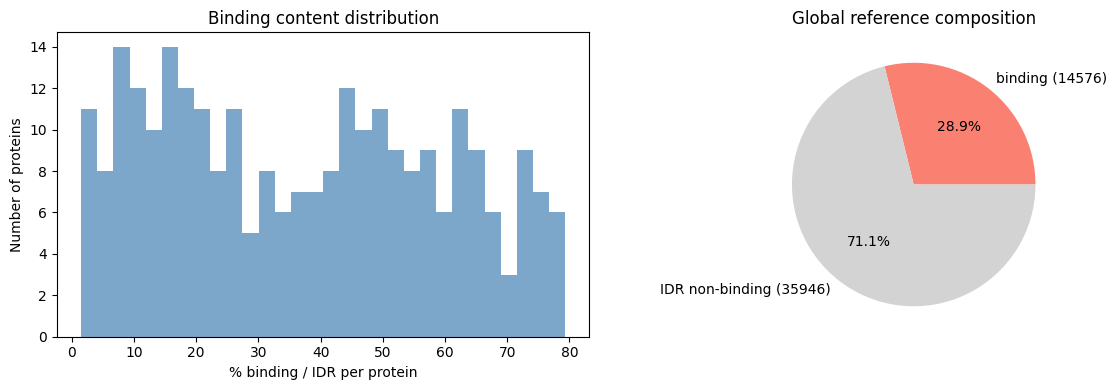

,disprot_id,n_binding,n_idr,pct_binding,pct_idr
0,DP00023,9,43,17.307692,82.692308
1,DP00027,57,40,58.762887,41.237113
2,DP00033,88,263,25.071225,74.928775
3,DP00042,26,44,37.142857,62.857143
4,DP00049,120,83,59.113300,40.886700
...,...,...,...,...,...
263,DP04298,18,266,6.338028,93.661972
264,DP04328,25,341,6.830601,93.169399
265,DP04378,98,146,40.163934,59.836066
266,DP04379,110,90,55.000000,45.000000


In [ ]:
# Cell 12
ref.plot_stats(ACTIVE_REF)

# Write fasta

In [ ]:
# Cell 11
# scrivi FASTA per CAID
ref.write_fasta(ACTIVE_REF, cfg["fasta_out"])
print(f"Written: {cfg['fasta_out']}")


Written: ..\data\processed\reference\DDB_80.fasta


## CAID

## 7 · Add `ref_seq` and `confusion_matrix` to `merged_lip_af`

In [ ]:
# Cell 13
# ref_seq: binary reference sequence (0/1/-) per residue position
seq_df = (
    pd.DataFrame.from_dict(ACTIVE_REF, orient='index')
    .reset_index(drop=True)
    .assign(aa      = lambda df: df['sequence'].apply(list),
            ref_seq = lambda df: df['ref_sequence'].apply(list),
            pos     = lambda df: df['aa'].apply(lambda x: list(range(1, len(x)+1))))
    .explode(['aa','ref_seq','pos'])
    [['acc','disprot_id','pos','ref_seq']]
    .astype({'pos': int})
)

merged_lip_af = merged_lip_af.merge(
    seq_df, on=['acc','disprot_id','pos'], how='left')

# non da FARE: aggiorna _cmat_path con il path del tuo output CAID per questa combinazione
# _cmat_path = r"C:\...\NOME_COMBINAZIONE.analysis.all.dataset.f1s.cmat.csv"
# Confuson_Matrix = pd.read_csv(_cmat_path, index_col=0)

merged_lip_af['confusion_matrix'] = merged_lip_af.apply(plots.label_confusion, axis=1)

print(len(merged_lip_af['disprot_id'].unique()))
merged_lip_af.head(2)

870


,acc,disprot_id,pos,aa,lipnet_score,lddt,disorder,rsa,ss,binding,disorder_rsa,disorder_plddt,organism,lipnet_pred,lipnet_pred_0.94,af_pred,ss_norm,ref_seq,confusion_matrix
0,P49913,DP00004,1,M,0.286,0.383,0.617,1.000,-,0.742,0.796,0.617,Homo sapiens,0,0,0,coil,NaN,NaN
1,P49913,DP00004,2,K,0.381,0.512,0.488,0.888,-,0.796,0.786,0.488,Homo sapiens,0,0,1,coil,NaN,NaN


In [ ]:
# Cell save_merged_lip_af
import os
_out = os.path.join(BASE_CAID, "merged_lip_af.csv")
merged_lip_af.to_csv(_out, index=False)
print(f"Saved: {_out}  ({len(merged_lip_af):,} rows, {len(merged_lip_af.columns)} columns)")

Saved: ..\data\processed\merged_lip_af.csv  (481,169 rows, 19 columns)


## 8 · Dict LipNet per CIDER `lipnet_pred_dict` + `lipnet_pred_dict_cider`


Da markdown 8 a markdown 9.bis — flusso completo 
 
[31] — Costruisce all_1107_lipnet_cider: score LipNet → stringa binaria → regioni contigue di 1 → rimozione proteins with AA non standard. Nessun filtro di lunghezza ancora.

[32] — Diagnostica: mostra la distribuzione delle lunghezze delle regioni before filtering, con la linea rossa a 5. Serve per giustificare la scelta del cutoff.

[33] — Applica filter_short(min_length=5), calcola le feature CIDER con LocalCIDER su tutte le 1107 proteine → df_cider_lipnet_all. Salva CSV.

[34] — Stessa pipeline ma sul reference DisProt: estrae le regioni annotate, filter_short(5), calcola CIDER → df_cider_ref. Salva CSV.

[36] — Aggiunge 4 feature extra a entrambi i DataFrame (frac_positive, frac_negative, frac_polar, frac_proline) → df_cider_ref_full e df_cider_lip_full. Queste sono usate nelle celle di plot successive.

[38] — Filtra alle sole proteine di ACTIVE_REF (la configurazione attiva, ~268 proteine del benchmark): df_cider_lip_full → DF_LIP_pred_cider_af e ricalcola reference CIDER per ACTIVE_REF → DF_REF_cider_af. Crea gli alias ref_cider_DF e lip_pred_cider_DF usati dai plot.



  - Cella 32: Costruisce all_1107_lipnet_cider da tutte le 1107 proteins with score ≥ 0.494 → regioni contigue di 1
  - Cella 33: Diagnostica sulla distribuzione lunghezze before filtering (serve a giustificare min_length=5)
  - Cella 34: Applica filter_short(min_length=5), calcola CIDER → df_cider_lipnet_all, salva CSV
  - Cella 35: Stessa pipeline sul reference DisProt annotato → df_cider_ref, salva CSV
  - Cella 37: Aggiunge 4 feature extra (frac_positive, frac_negative, frac_polar, frac_proline) — le formule sono
  matematicamente corrette: frac_pos = (FCR+NCPR)/2 = pos/tot ✓
  - Cella 39 (9.bis): Filtra alle proteine di ACTIVE_REF, ricalcola reference CIDER — OK

  Nota bene: DF_REF_cider_af (ricalcolato da ACTIVE_REF) e df_cider_ref (tutte le proteine) sono oggetti diversi. I plot
   usano ref_cider_DF = DF_REF_cider_af (filtrato) e lip_pred_cider_DF = DF_LIP_pred_cider_af (filtrato). Coerente.

Funzioni:  
`extract_regions_from_ones(proteins)` — iterates over the binary string lipnet_pred of each protein (e.g. "0011110010...") and identifies consecutive stretches of '1', i.e. regions predicted as binding by LIPNet above the 0.494 threshold. For each stretch it extracts the corresponding amino acid subsequence with start/end coordinates (1-based). Returns a dictionary {idx: [list of regions]}.

`filter_invalid_proteins(data_loaded)` — attempts to create a SequenceParameters object (LocalCIDER) for every region. If even a single region of a protein contains invalid amino acids and raises a SequenceException, the entire protein is discarded. Returns the filtered dictionary and the list of discarded ids.

`compute_lc_features_dataframe(data_loaded)` — for each valid region computes the physicochemical features using LocalCIDER: FCR (fraction of charged residues), NCPR (net charge per residue), kappa (charge segregation +/-), mean hydropathy; then computes PPII propensity via LocalCIDER get_PPII_propensity(hilser) and WF complexity via get_linear_complexity('WF'), plus manual fraction of aromatics (F/Y/W/I) and bulky residues (F/I/L/V). Returns a pandas DataFrame with one row per region.



In [ ]:
# CIDER on all the 1107 proteins - predicted regions by LIONet
# costruito da lipnet_pred_df (tutte le 1107) before filtering a ACTIVE_REF
lipnet_pred_by_id_all = (
    lipnet_pred_df.sort_values(["disprot_id", "position"])
    .groupby("disprot_id")["lipnet_score"]
    .apply(lambda x: "".join((x >= 0.494).astype(int).astype(str)))
    .to_dict()
)
print(f"Proteins with LipNet predictions: {len(lipnet_pred_by_id_all)}")

lipnet_pred_dict_all = {
    idx: {"acc": data["acc"], "disprot_id": data["disprot_id"],
          "prot_sequence": data["sequence"], "lipnet_pred": lipnet_pred_by_id_all[data["disprot_id"]]}
    for idx, data in filtered_proteins_lipnet.items()
    if data["disprot_id"] in lipnet_pred_by_id_all
}
print(f"Proteins with LipNet predictions and in filtered set: {len(lipnet_pred_dict_all)}") 


all_1107_lipnet_cider = cider.extract_predicted_regions(lipnet_pred_dict_all)
all_1107_lipnet_cider, skipped = cider.filter_invalid(all_1107_lipnet_cider)
print(f"Proteins skipped (invalid AA): {skipped}")


Proteins with LipNet predictions: 1107
Proteins with LipNet predictions and in filtered set: 1107
Proteins skipped (invalid AA): [653, 962, 964, 965, 1925]


count    22974.0
mean        11.8
std         27.0
min          1.0
25%          1.0
50%          2.0
75%          7.0
max        639.0
Name: length, dtype: float64
Total regions: 22974
Regions with length < 5: 16011 (69.7%)


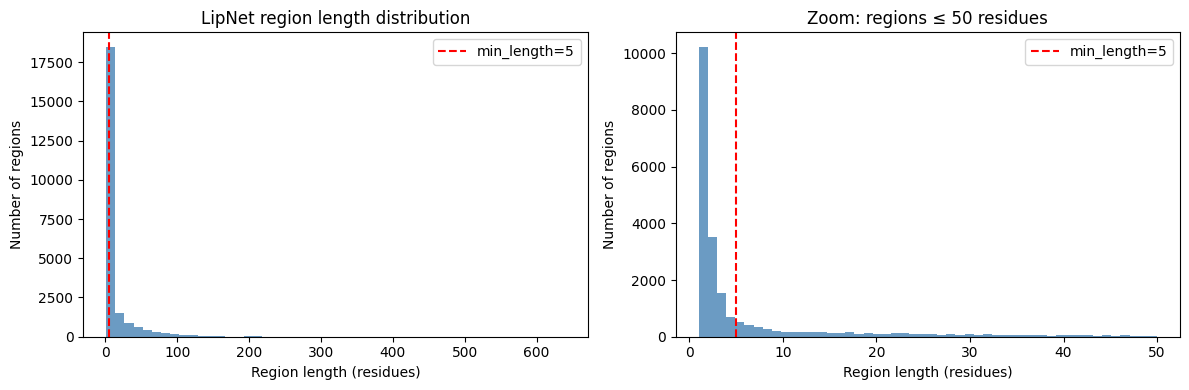

In [ ]:
# Cell 13.5 - LipNet predicted region length distribution (no short filter)
lengths = [
    r['length']
    for regions in all_1107_lipnet_cider.values()
    for r in regions
]
s = pd.Series(lengths, name='length')

print(s.describe().round(1))
print(f"Total regions: {len(s)}")
print(f"Regions with length < 5: {(s < 5).sum()} ({(s < 5).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(s, bins=50, color='steelblue', alpha=0.8)
axes[0].axvline(5, color='red', linestyle='--', label='min_length=5')
axes[0].set_xlabel('Region length (residues)')
axes[0].set_ylabel('Number of regions')
axes[0].set_title('LipNet region length distribution')
axes[0].legend()

axes[1].hist(s[s <= 50], bins=50, color='steelblue', alpha=0.8)
axes[1].axvline(5, color='red', linestyle='--', label='min_length=5')
axes[1].set_xlabel('Region length (residues)')
axes[1].set_ylabel('Number of regions')
axes[1].set_title('Zoom: regions ≤ 50 residues')
axes[1].legend()

plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "lipnet_predicted_region_lengths.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Cell 14
all_1107_lipnet_cider_filter_short = cider.filter_short(all_1107_lipnet_cider, min_length=5)
print(f"Proteins after filter_short (>= 5 aa): {len(all_1107_lipnet_cider_filter_short)}")

df_cider_lipnet_all = cider.compute_features(all_1107_lipnet_cider_filter_short)
df_cider_lipnet_all.to_csv(r"..\data\processed\df_cider_lipnet_all.csv", index=False)
print(f"Proteins: {df_cider_lipnet_all['disprot_id'].nunique()}, regions: {len(df_cider_lipnet_all)}")


Proteins after filter_short (>= 5 aa): 1102
Proteins: 1102, regions: 6963


In [ ]:
# Calcolo df_cider_ref direttamente dal reference annotato DisProt

_region_dict = cider.make_region_dict(filtered_proteins_lipnet, allowed_terms)
_regions     = cider.extract_regions(_region_dict)
_regions, _skipped_ref = cider.filter_invalid(_regions)
print(f"Proteins skipped (invalid AA, ref): {_skipped_ref}")
_regions = cider.filter_short(_regions, min_length=5)
print(f"Proteins after filter_short >= 5 aa (ref): {len(_regions)}")

df_cider_ref = cider.compute_features(_regions)
df_cider_ref.to_csv(r"..\data\processed\df_cider_all.csv", index=False)
print(f"Reference: {df_cider_ref['disprot_id'].nunique()} proteins, {len(df_cider_ref)} regions")


Proteins skipped (invalid AA, ref): [1925]
Proteins after filter_short >= 5 aa (ref): 1101
Reference: 1101 proteins, 1345 regions


## 9 · Carica CIDER e costruisci `DF_REF_cider_af` / `DF_LIP_pred_cider_af`

In [ ]:
# Cell 17 - feature extra su df_cider_ref e df_cider_lipnet_all

def add_extra_features(df):
    df = df.copy()
    df["frac_positive"] = (df["FCR"] + df["NCPR"]) / 2
    df["frac_negative"] = (df["FCR"] - df["NCPR"]) / 2
    df["frac_polar"]    = df["region_sequence"].str.upper().apply(
        lambda s: sum(1 for aa in s if aa in "STNQ") / len(s))
    df["frac_proline"]  = df["region_sequence"].str.upper().apply(
        lambda s: s.count("P") / len(s))
    return df

df_cider_ref_full      = add_extra_features(df_cider_ref)
df_cider_lip_full      = add_extra_features(df_cider_lipnet_all)
print("Features added: frac_positive, frac_negative, frac_polar, frac_proline")

Features added: frac_positive, frac_negative, frac_polar, frac_proline


## 9.bis · CIDER per la configurazione attiva

Esegui questa cella ogni volta che cambi `ACTIVE`.
- **LipNet**: filtra il CSV pre-calcolato alle proteine in `ACTIVE_REF` (istantaneo)
- **Reference**: ricalcola da `ACTIVE_REF` con LocalCIDER (veloce, ~200 proteine)


In [ ]:
# Cell 18
# Proteins in active reference
active_ids = {v['disprot_id'] for v in ACTIVE_REF.values()}

# ── LipNet CIDER ─────────────────────────────────────────────────────────────
# Filter pre-computed CSV (all 1107 proteins) to proteins
# present in ACTIVE_REF. No recomputation needed: instant pandas filter.
# Usa df_cider_lip_full (arricchito da CIDER_1107.ipynb) se disponibile,
# altrimenti df_cider_lipnet_all (base).
_lip_src = df_cider_lip_full if 'df_cider_lip_full' in dir() else df_cider_lipnet_all
DF_LIP_pred_cider_af = _lip_src[_lip_src['disprot_id'].isin(active_ids)].copy()

# ── Reference CIDER ───────────────────────────────────────────────────────────
# Recompute from ACTIVE_REF at each configuration change.
# Not loaded from CSV because the reference changes with ACTIVE
# (different annotation_set and different filtered proteins).
_region_dict = cider.make_region_dict(filtered_proteins_REF, cfg['annotation_set'])
# Keep only proteins that entered ACTIVE_REF after quality filtering
_region_dict = {k: v for k, v in _region_dict.items()
                if v['disprot_id'] in active_ids}
_regions        = cider.extract_regions(_region_dict)
_regions, _skip = cider.filter_invalid(_regions)
_regions        = cider.filter_short(_regions, min_length=5)
DF_REF_cider_af = cider.compute_features(_regions)

# Alias per le celle di plot (12e, 12f, 12g usano questi nomi)
ref_cider_DF      = DF_REF_cider_af
lip_pred_cider_DF = DF_LIP_pred_cider_af

print(f"[{cfg['label']}]")
print(f"Reference CIDER : {DF_REF_cider_af['disprot_id'].nunique()} proteins, {len(DF_REF_cider_af)} regions")
print(f"LipNet CIDER    : {DF_LIP_pred_cider_af['disprot_id'].nunique()} proteins, {len(DF_LIP_pred_cider_af)} regions")


[DDB_80]
Reference CIDER : 265 proteins, 324 regions
LipNet CIDER    : 268 proteins, 1809 regions


## 10 · Categorie per lunghezza IDR

# CREATE CONFUSION MATRIX

## 11 · Riepilogo percentuali `perc_REF`

Sostituisce i 4 dizionari separati (`id_to_Xperc_REF`, ecc.)

Parte 1 filtro IDR residues

ref_lip_af_DOB = merged_lip_af[merged_lip_af['ref_seq'].isin(['0','1'])]
Tiene solo i residui che hanno un'annotazione reference ('0' = IDR non-binding, '1' = IDR binding). Scarta i residui con '-' (fuori dalle IDR regions, non considerati dal reference).

Parte 2 loop sul reference dict
Per ogni proteina in REF_DDB_80 calcola 4 percentuali:

Variabile	Formula	Significato  
`perc_bind_IDR`	c1 / (c0+c1)	% binding residues tra gli IDR  
`perc_nob_IDR`	c0 / (c0+c1)	% residui non-binding tra gli IDR  
`perc_IDR_tot`	(c0+c1) / tot	% IDR residues sulla proteina intera  
`perc_bind_tot`	c1 / tot	% binding residues sulla proteina intera  
Il denominatore cambia: le prime due usano solo i IDR residues (c0+c1), le seconde due usano tutta la proteina (tot).

Parte 3 percentuali LipNet

`perc_pred_IDR`   # % predetti binding tra i soli IDR residues (da ref_lip_af_DOB)  
`perc_pred_tot`   # % predetti binding sulla proteina intera (da merged_lip_af)  
Usa gli stessi denominatori del reference: perc_pred_IDR divide su ref_lip_af_DOB (solo IDR), perc_pred_tot divide su merged_lip_af (tutto).  

Risultato finale
perc_REF ha una riga per proteina con 6 colonne numeriche che ti permettono di confrontare reference e predizione sia a livello di IDR che di intera proteina.

In [ ]:
# Cell 20
ref_lip_af_DOB = merged_lip_af[merged_lip_af['ref_seq'].isin(['0','1'])]

rows = []
for data in ACTIVE_REF.values():
    c0 = data['ref_sequence'].count('0')
    c1 = data['ref_sequence'].count('1')
    tot = len(data['ref_sequence'])
    denom = c0 + c1
    rows.append({
        'disprot_id': data['disprot_id'],
        'perc_bind_IDR':  c1 / denom * 100 if denom > 0 else 0,  # ex id_to_1perc_REF
        'perc_nob_IDR':   c0 / denom * 100 if denom > 0 else 0,  # ex id_to_0perc_REF
        'perc_IDR_tot':   denom / tot * 100 if tot > 0 else 0,   # ex id_to_disorder_tot_REF
        'perc_bind_tot':  c1 / tot * 100 if tot > 0 else 0,      # ex id_to_disorder_1_tot_REF
    })
perc_REF = pd.DataFrame(rows)

# % LipNet predictions on IDR residues (same denominator as reference)
perc_pred_IDR = (
    ref_lip_af_DOB.groupby('disprot_id')['lipnet_pred']
    .apply(lambda x: round((x == 1).sum() / len(x) * 100, 2))
    .rename('perc_pred_IDR')
)
# % predizioni LipNet sulla proteina intera
perc_pred_tot = (
    merged_lip_af.groupby('disprot_id')['lipnet_pred']
    .apply(lambda x: round(x.sum() / len(x) * 100, 2))
    .rename('perc_pred_tot')
)
perc_REF = (perc_REF
    .merge(perc_pred_IDR, on='disprot_id', how='left')
    .merge(perc_pred_tot, on='disprot_id', how='left'))

print(f"perc_REF shape: {perc_REF.shape}")
perc_REF.head(3)


perc_REF shape: (268, 7)


,disprot_id,perc_bind_IDR,perc_nob_IDR,perc_IDR_tot,perc_bind_tot,perc_pred_IDR,perc_pred_tot
0,DP00023,17.307692,82.692308,15.853659,2.743902,75.00,41.77
1,DP00027,58.762887,41.237113,100.000000,58.762887,98.97,98.97
2,DP00033,25.071225,74.928775,55.015674,13.793103,57.83,38.71


## 11.a



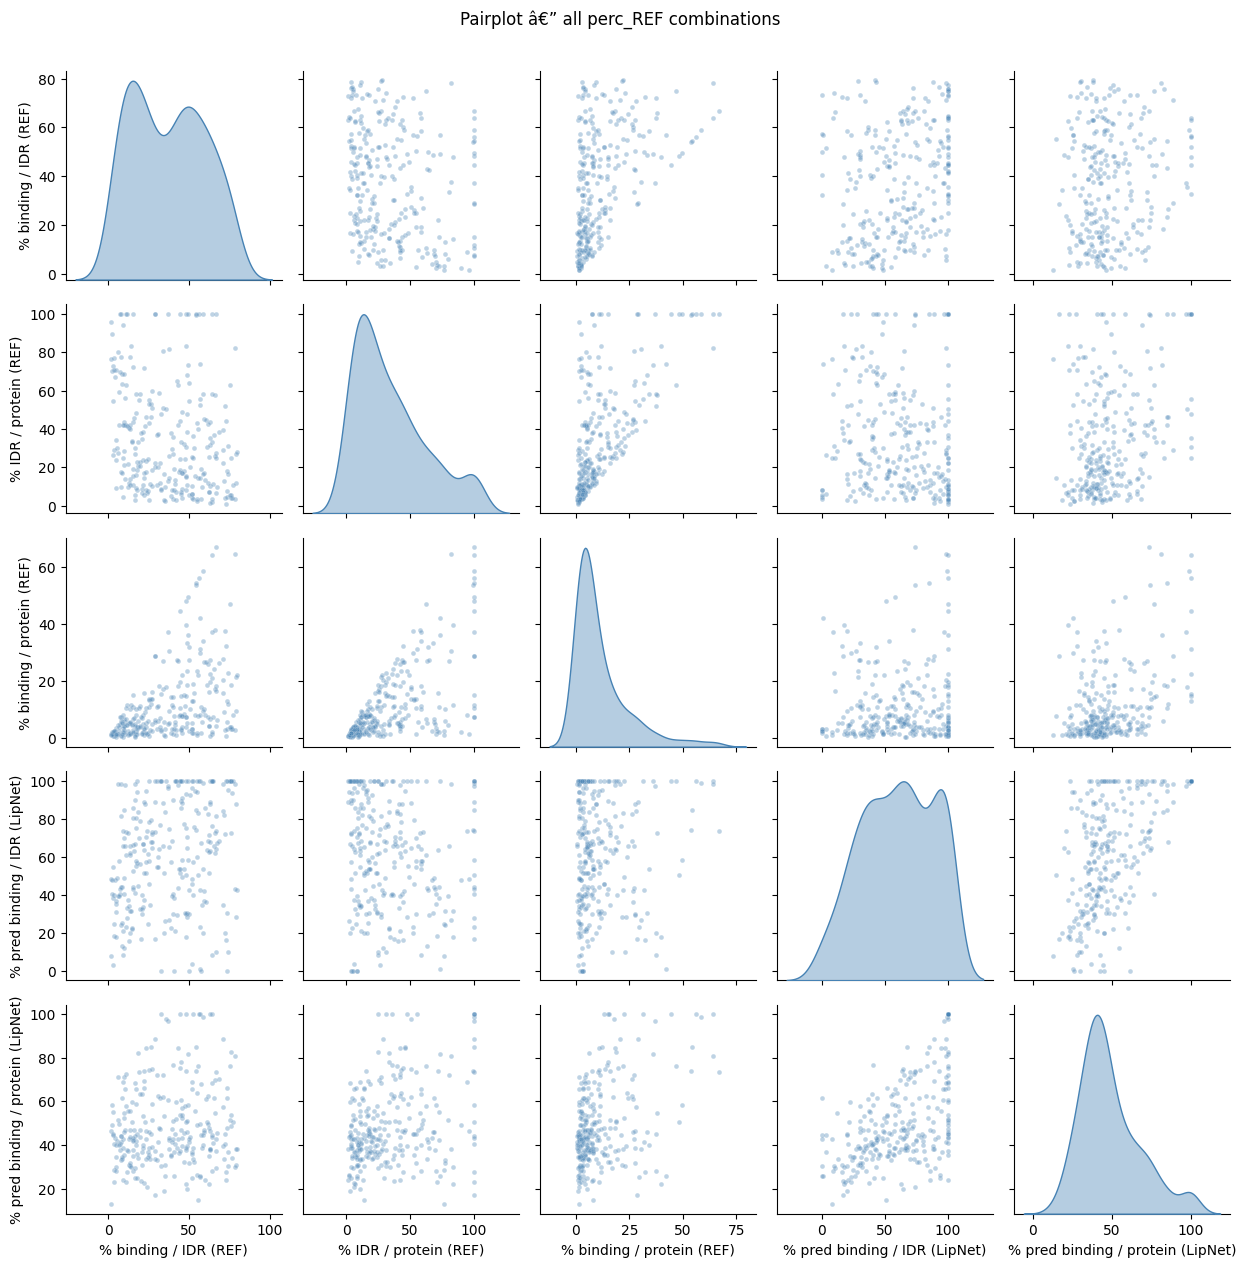

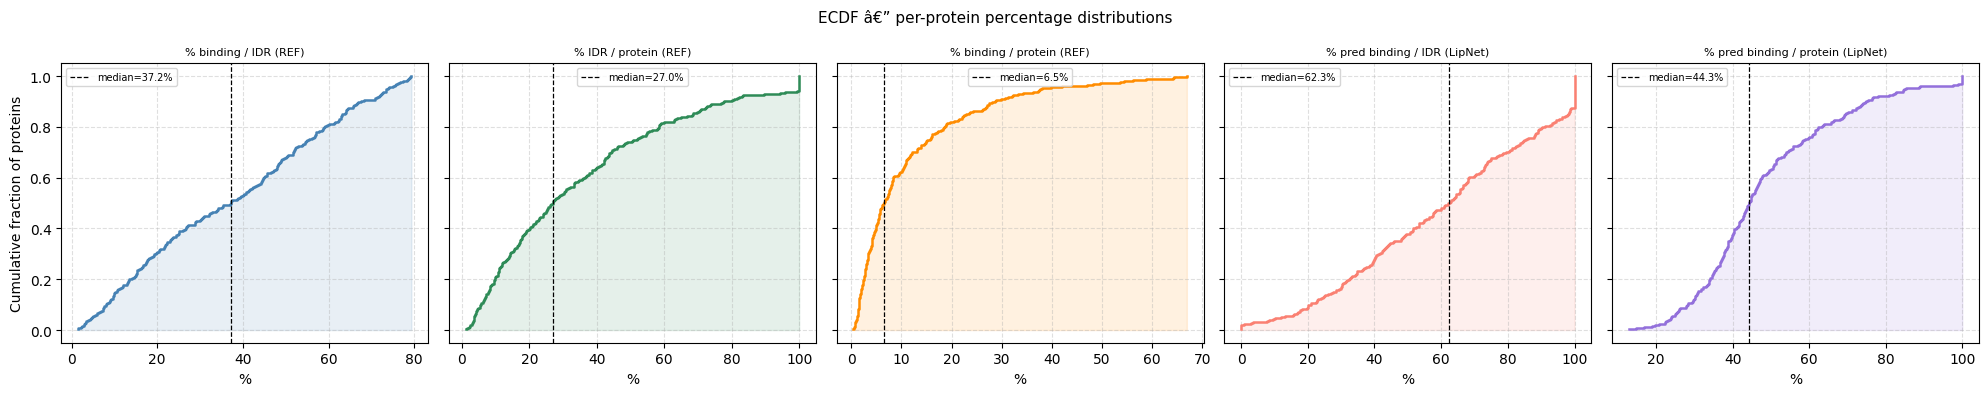

In [ ]:
# Cell 21
cols = ['perc_bind_IDR', 'perc_IDR_tot', 'perc_bind_tot',
        'perc_pred_IDR', 'perc_pred_tot']

labels = {
    'perc_bind_IDR':  '% binding / IDR (REF)',
    'perc_IDR_tot':   '% IDR / protein (REF)',
    'perc_bind_tot':  '% binding / protein (REF)',
    'perc_pred_IDR':  '% pred binding / IDR (LipNet)',
    'perc_pred_tot':  '% pred binding / protein (LipNet)',
}

# 1. Pairplot 
df_plot = perc_REF[cols].rename(columns=labels).dropna()

g = sns.pairplot(
    df_plot,
    diag_kind='kde',
    plot_kws=dict(alpha=0.35, s=12, color='steelblue'),
    diag_kws=dict(color='steelblue', fill=True, alpha=0.4),
)
g.figure.suptitle('Pairplot â€” all perc_REF combinations', y=1.01, fontsize=12)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
g.figure.savefig(os.path.join(_fig_dir, "perc_ref_pairplot.png"), dpi=150, bbox_inches="tight")
plt.show()

#  2. ECDF cumulativa 
fig, axes = plt.subplots(1, len(cols), figsize=(20, 4), sharey=True)
colors_ecdf = ['steelblue', 'seagreen', 'darkorange', 'salmon', 'mediumpurple']

for ax, col, color in zip(axes, cols, colors_ecdf):
    data = perc_REF[col].dropna().sort_values().values
    ecdf = np.arange(1, len(data) + 1) / len(data)
    ax.step(data, ecdf, where='post', color=color, lw=1.8)
    ax.fill_between(data, ecdf, step='post', alpha=0.12, color=color)
    ax.axvline(np.median(data), color='black', lw=0.9, linestyle='--',
               label=f'median={np.median(data):.1f}%')
    ax.set_title(labels[col], fontsize=8)
    ax.set_xlabel('%')
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel('Cumulative fraction of proteins')
fig.suptitle('ECDF â€” per-protein percentage distributions', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(_fig_dir, "perc_ref_ecdf.png"), dpi=150, bbox_inches="tight")
plt.show()

## PLOT 12-1

plot from ALL_IN_ALL_100

In [ ]:
AF_CAID = r"..\data\raw\AF_CAID_output"
file_path_disorder_pLDDT = rf"{AF_CAID}\alphafold_disorder_pred_caid_disorder.dat"
file_path_disorder_RSA   = rf"{AF_CAID}\alphafold_disorder_pred_caid_disorder-25.dat"
file_path_binding        = rf"{AF_CAID}\alphafold_disorder_pred_caid_binding-25-0.581.caid"

df_disorder_pLDDT   = p1107.load_disorder_file(file_path_disorder_pLDDT).rename(columns={'disorder_rsa': 'disorder_plddt'})
df_disorder_RSA     = p1107.load_disorder_file(file_path_disorder_RSA)
df_disorder_Binding = p1107.load_disorder_file(file_path_binding).rename(columns={'disorder_rsa': 'binding'})


---
# 12 · Plot

## 12a · Plot interattivo LipNet per proteina

In [ ]:
# Cell 23
REGION_CLASSES = {
    "D_O": disorder_to_order,
    "O_D": order_to_disorder,
    "D_D": disorder_to_disorder,
    "B": binding,
    "D_S": display_site,
    "Idpo:00002": DISORDER
}
REGION_COLORS = {
    "D_O": "lightblue",
    "O_D": "lightgreen",
    "D_D": "lightcoral",
    "B": "khaki",
    "D_S": "plum",
    "Idpo:00002": "blue"
}

disprot_to_protein = {prot["disprot_id"]: prot for prot in filtered_proteins_lipnet.values()}
acc_to_disprot     = {str(prot["acc"]): prot["disprot_id"] for prot in filtered_proteins_lipnet.values()}

for df_extra in [df_disorder_pLDDT, df_disorder_RSA, df_disorder_Binding]:
    if "disprot_id" not in df_extra.columns:
        df_extra["disprot_id"] = df_extra["protein_id"].astype(str).map(acc_to_disprot)
    else:
        df_extra["disprot_id"] = df_extra["disprot_id"].astype(str)

ref_ddb80_ids = {v["disprot_id"] for v in ACTIVE_REF.values()}
df_proteins   = set(lipnet_pred_df["disprot_id"].unique()) & ref_ddb80_ids

region_to_dfproteins = defaultdict(set)
for disprot_id in df_proteins:
    prot = disprot_to_protein.get(disprot_id)
    if not prot:
        continue
    for r in prot["regions"].values():
        for region_type, term_set in REGION_CLASSES.items():
            if r["term_id"] in term_set:
                region_to_dfproteins[region_type].add(disprot_id)


def merge_intervals(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [list(intervals[0])]
    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])
    return [tuple(m) for m in merged]


def plot_lipnet_no_overlap(protein_id, selected_region_type):
    import matplotlib.lines as mlines
    from matplotlib.patches import Patch
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(14, 4))

    datasets = [
        ("LipNet",  lipnet_pred_df,     "#333333", "lipnet_score",   "position"),
        ("pLDDT",   df_disorder_pLDDT,  "#457B9D", "disorder_plddt", "residue_num"),
        ("RSA",     df_disorder_RSA,    "#2A9D8F", "disorder_rsa",   "residue_num"),
        ("Binding", df_disorder_Binding,"#E76F51", "binding",        "residue_num"),
    ]
    line_handles = []
    for name, df_src, color, score_col, pos_col in datasets:
        df_sel = df_src[df_src["disprot_id"] == protein_id]
        if not df_sel.empty:
            ax.plot(df_sel[pos_col], df_sel[score_col], color=color, linewidth=1.5)
        line_handles.append(mlines.Line2D([], [], color=color, linewidth=2, label=name))

    prot = disprot_to_protein.get(protein_id)
    if prot:
        regions_by_class = defaultdict(list)
        for r in prot["regions"].values():
            for rc, term_set in REGION_CLASSES.items():
                if r["term_id"] in term_set:
                    regions_by_class[rc].append((r["start"], r["end"]))
                    break
        level_height = 0.05
        for i, (rc, intervals) in enumerate(regions_by_class.items()):
            for start, end in merge_intervals(intervals):
                ax.axvspan(start, end,
                           ymin=i * level_height, ymax=(i + 1) * level_height,
                           color=REGION_COLORS.get(rc, "grey"), alpha=0.7)

    leg_lines = ax.legend(handles=line_handles, title="Dataset",
                          loc="upper right", framealpha=0.8)
    ax.add_artist(leg_lines)
    region_handles = [Patch(facecolor=REGION_COLORS.get(rc, "grey"), edgecolor="black",
                            alpha=0.7, label=rc) for rc in REGION_CLASSES.keys()]
    ax.legend(handles=region_handles, title="Regions",
              loc="lower right", framealpha=0.8)

    ax.set_xlabel("Residue number")
    ax.set_ylabel("Score / Value")
    ax.set_title(f"{protein_id}")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


_PLACEHOLDER = "—"  # em-dash, usato come sentinella
region_dd  = widgets.Dropdown(options=list(REGION_CLASSES.keys()), description="Region type:")
protein_dd = widgets.Dropdown(options=[_PLACEHOLDER], value=_PLACEHOLDER, description="Protein:")
out23      = widgets.Output()


def redraw(*_):
    pid = protein_dd.value
    if not pid or pid == _PLACEHOLDER:
        return
    out23.clear_output(wait=True)
    with out23:
        plot_lipnet_no_overlap(pid, region_dd.value)


def update_proteins(*_):
    options = sorted(region_to_dfproteins.get(region_dd.value, []))
    try:
        protein_dd.unobserve(redraw, names="value")
    except Exception:
        pass
    protein_dd.options = [_PLACEHOLDER] + options
    if options:
        protein_dd.value = options[0]
    protein_dd.observe(redraw, names="value")
    redraw()


region_dd.observe(update_proteins, names="value")
update_proteins()
display(widgets.VBox([widgets.HBox([region_dd, protein_dd]), out23]))


## 12b · ROC e PR curves

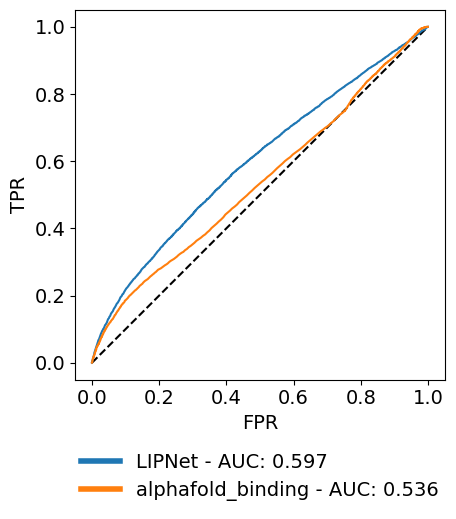

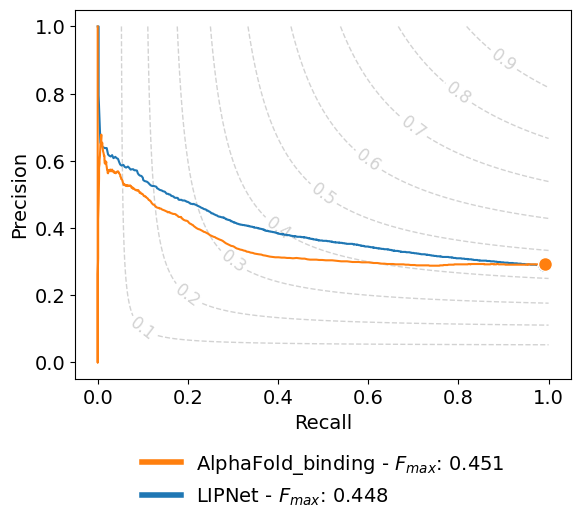

In [ ]:
# Cell 24
# roc curve
CAID_OUTPUT_DIR = cfg["caid_output_dir"]
label = cfg["label"]

DO_B_roc = pd.read_csv(
    os.path.join(CAID_OUTPUT_DIR, f"{label}.analysis.all.dataset._.roc.csv"),
    index_col=[0], header=[0, 1, 2])
ax = plt.subplot()
ax.set_facecolor((1.0, 1, 1))
for spine in ax.spines.values():
    spine.set_edgecolor('black')
ax.set_box_aspect(1)
plots.plot_roc(DO_B_roc, ax=ax)

DO_B_pr = pd.read_csv(
    os.path.join(CAID_OUTPUT_DIR, f"{label}.analysis.all.dataset._.pr.csv"),
    index_col=[0], header=[0, 1, 2, 3])
plots.plot_pr(DO_B_pr)


## 12c Â· Distribuzione SS / pLDDT

## 12c-bis · Distribuzione SS / pLDDT (normalizzata)

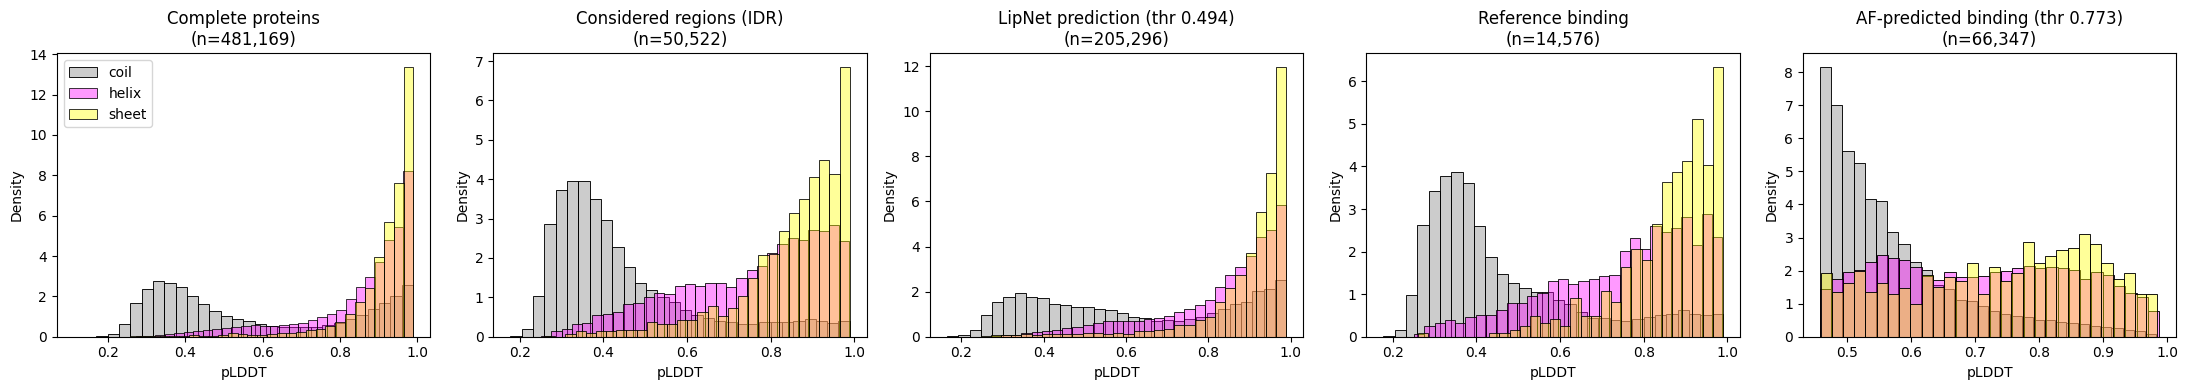

In [ ]:
# Cell 25
palette = {"coil": "gray", "helix": "magenta", "sheet": "yellow"}

prediz          = merged_lip_af[merged_lip_af["lipnet_pred"] == 1]
ref_binding     = merged_lip_af[merged_lip_af["ref_seq"] == "1"]
af_pred_binding = merged_lip_af[merged_lip_af["binding"] >= 0.773]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
datasets = [
    ("Complete proteins",              merged_lip_af),
    ("Considered regions (IDR)",       ref_lip_af_DOB),
    ("LipNet prediction (thr 0.494)",  prediz),
    ("Reference binding",              ref_binding),
    ("AF-predicted binding (thr 0.773)", af_pred_binding),
]
for ax, (title, df) in zip(axes, datasets):
    for ss in ["coil", "helix", "sheet"]:
        sns.histplot(df[df["ss_norm"] == ss]["lddt"], bins=30, kde=False,
                     color=palette[ss], label=ss, alpha=0.4, ax=ax, stat="density")
    ax.set_title(f"{title}\n(n={len(df):,})")
    ax.set_xlabel("pLDDT")
axes[0].set_ylabel("Density")
axes[0].legend()
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "ss_plddt_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu

# --- pLDDT ---
plddt_lipnet = merged_lip_af[merged_lip_af["lipnet_pred"] == 1]["disorder_plddt"].dropna()
plddt_ref    = merged_lip_af[merged_lip_af["ref_seq"] == "1"]["disorder_plddt"].dropna()

U_plddt, p_plddt = mannwhitneyu(plddt_lipnet, plddt_ref, alternative="two-sided")
r_plddt = abs(1 - 2 * U_plddt / (len(plddt_lipnet) * len(plddt_ref)))

print("=== pLDDT ===")
print(f"LIPNet prediction (n={len(plddt_lipnet):,}) vs Reference binding (n={len(plddt_ref):,})")
print(f"Mann-Whitney U = {U_plddt:.3e}")
print(f"p-value = {p_plddt:.3e}")
print(f"rank-biserial r = {r_plddt:.3f}")
print(f"Median LIPNet pLDDT: {plddt_lipnet.median():.3f}")
print(f"Median REF pLDDT:    {plddt_ref.median():.3f}")

print()

# --- RSA ---
rsa_lipnet = merged_lip_af[merged_lip_af["lipnet_pred"] == 1]["disorder_rsa"].dropna()
rsa_ref    = merged_lip_af[merged_lip_af["ref_seq"] == "1"]["disorder_rsa"].dropna()

U_rsa, p_rsa = mannwhitneyu(rsa_lipnet, rsa_ref, alternative="two-sided")
r_rsa = abs(1 - 2 * U_rsa / (len(rsa_lipnet) * len(rsa_ref)))

print("=== RSA ===")
print(f"LIPNet prediction (n={len(rsa_lipnet):,}) vs Reference binding (n={len(rsa_ref):,})")
print(f"Mann-Whitney U = {U_rsa:.3e}")
print(f"p-value = {p_rsa:.3e}")
print(f"rank-biserial r = {r_rsa:.3f}")
print(f"Median LIPNet RSA: {rsa_lipnet.median():.3f}")
print(f"Median REF RSA:    {rsa_ref.median():.3f}")


=== pLDDT ===
LIPNet prediction (n=205,296) vs Reference binding (n=14,576)
Mann-Whitney U = 8.503e+08
p-value = 0.000e+00
rank-biserial r = 0.432
Median LIPNet pLDDT: 0.182
Median REF pLDDT:    0.523

=== RSA ===
LIPNet prediction (n=205,296) vs Reference binding (n=14,576)
Mann-Whitney U = 7.842e+08
p-value = 0.000e+00
rank-biserial r = 0.476
Median LIPNet RSA: 0.485
Median REF RSA:    0.764


## 12d Â· Binding content per proteina

## 12d-bis Â· Binding content â€“ scatter + boxplot compatti

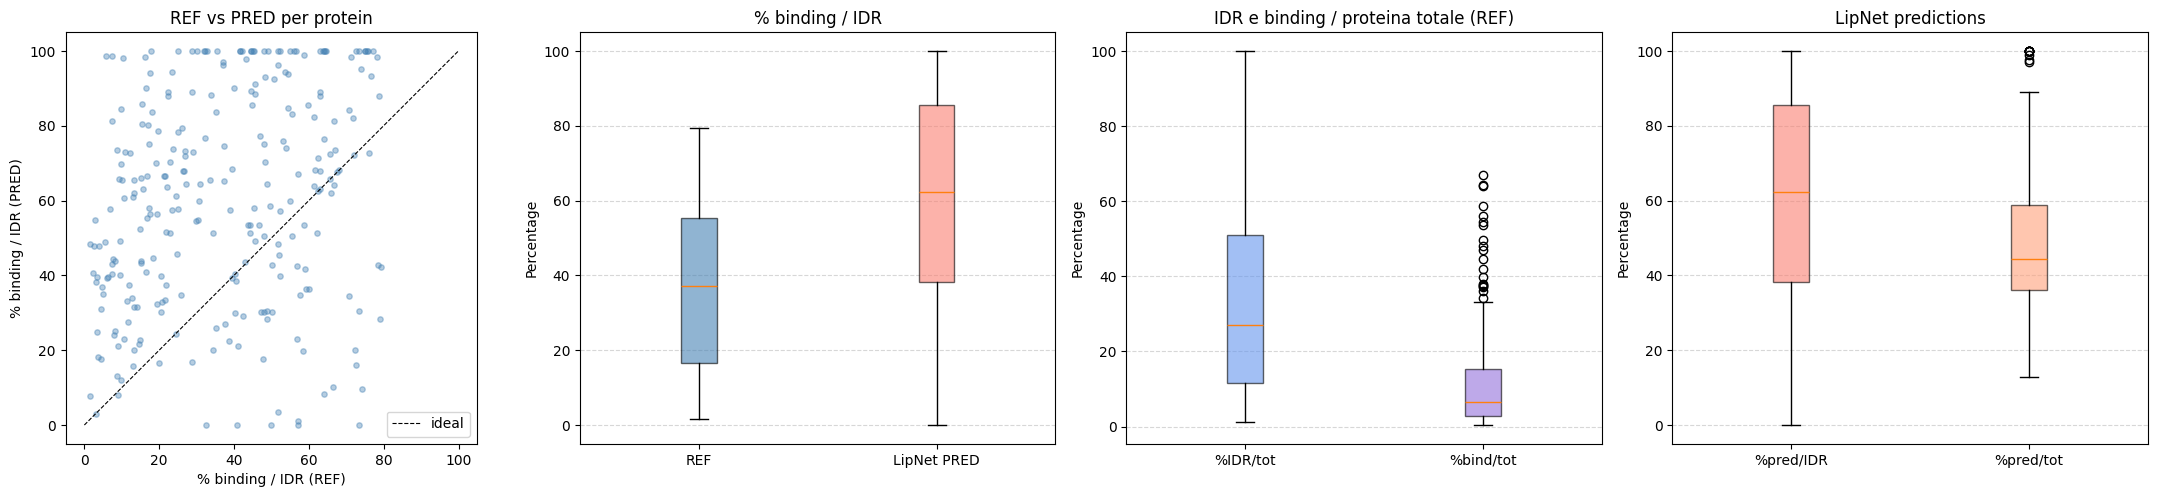

In [ ]:
# Cell 28
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# scatter REF vs PRED per proteina
merged_perc = perc_REF[["perc_bind_IDR","perc_pred_IDR"]].dropna()
axes[0].scatter(merged_perc["perc_bind_IDR"], merged_perc["perc_pred_IDR"],
                alpha=0.4, s=15, color="steelblue")
axes[0].plot([0,100],[0,100],"k--", lw=0.8, label="ideal")
axes[0].set_title("REF vs PRED per protein")
axes[0].set_xlabel("% binding / IDR (REF)")
axes[0].set_ylabel("% binding / IDR (PRED)")
axes[0].legend(); axes[0].set_box_aspect(1)

# boxplot % binding / IDR
bp1 = axes[1].boxplot(
    [perc_REF["perc_bind_IDR"].dropna().values, perc_REF["perc_pred_IDR"].dropna().values],
    tick_labels=["REF","LipNet PRED"], patch_artist=True)
for patch, color in zip(bp1["boxes"], ["steelblue","salmon"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_title("% binding / IDR")
axes[1].set_ylabel("Percentage"); axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# boxplot % IDR/tot e % binding/tot (REF)
bp2 = axes[2].boxplot(
    [perc_REF["perc_IDR_tot"].dropna().values, perc_REF["perc_bind_tot"].dropna().values],
    tick_labels=["%IDR/tot","%bind/tot"], patch_artist=True)
for patch, color in zip(bp2["boxes"], ["cornflowerblue","mediumpurple"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[2].set_title("IDR e binding / proteina totale (REF)")
axes[2].set_ylabel("Percentage"); axes[2].grid(axis="y", linestyle="--", alpha=0.5)

# boxplot LipNet pred
bp3 = axes[3].boxplot(
    [perc_REF["perc_pred_IDR"].dropna().values, perc_REF["perc_pred_tot"].dropna().values],
    tick_labels=["%pred/IDR","%pred/tot"], patch_artist=True)
for patch, color in zip(bp3["boxes"], ["salmon","lightsalmon"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[3].set_title("LipNet predictions")
axes[3].set_ylabel("Percentage"); axes[3].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout(); 
_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "binding_content_per_protein.png"), dpi=150, bbox_inches="tight")
plt.show()

# 12.d.2

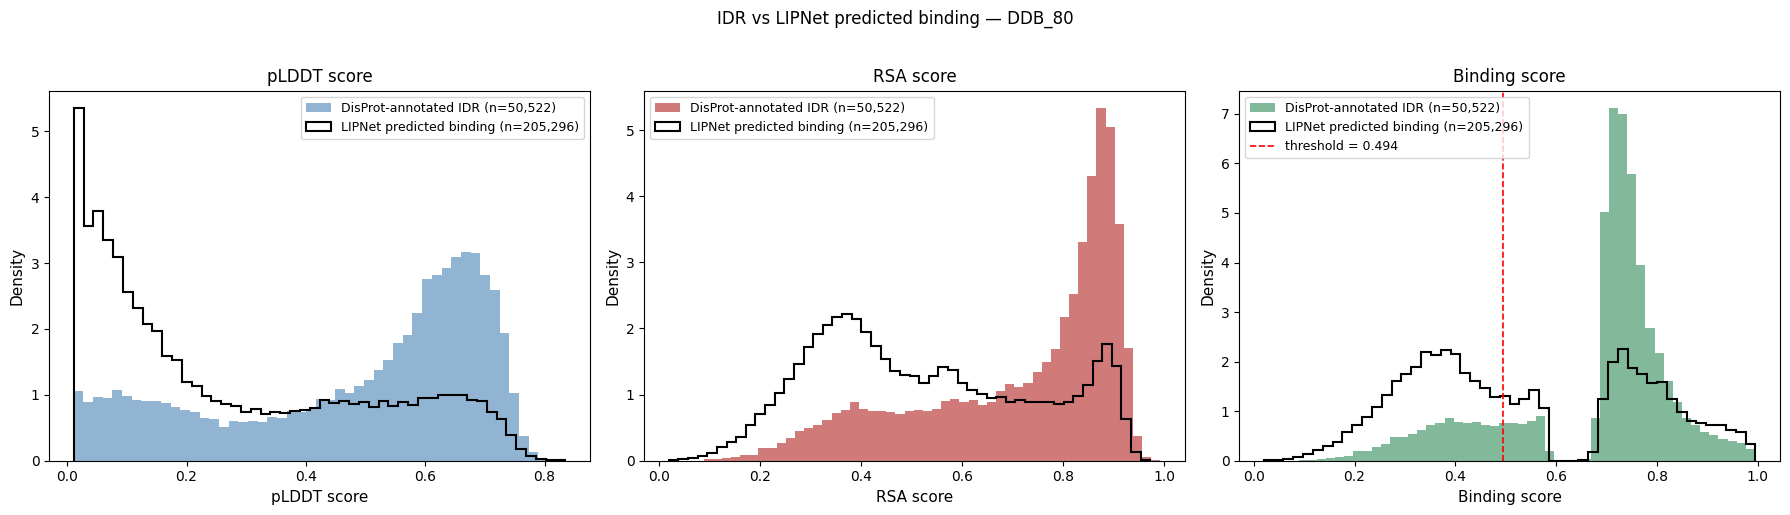


Metric             p-value    r_rb        Entità
----------------------------------------------------
pLDDT           0.0000e+00   0.492        medium
RSA             0.0000e+00   0.485        medium
Binding         0.0000e+00   0.323        medium


In [ ]:
# Cell 29
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

idr_pdb   = ref_lip_af_DOB
ones_pred = merged_lip_af[merged_lip_af['lipnet_pred'] == 1]

bins = 50
metrics = [
    ('disorder_plddt', 'pLDDT score',  'steelblue'),
    ('disorder_rsa',   'RSA score',    'firebrick'),
    ('binding',        'Binding score','seagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, xlabel, color) in zip(axes, metrics):
    ax.hist(idr_pdb[col].dropna(), bins=bins,
            color=color, alpha=0.6, density=True,
            label=f'DisProt-annotated IDR (n={idr_pdb[col].notna().sum():,})')
    ax.hist(ones_pred[col].dropna(), bins=bins,
            histtype='step', color='black', linewidth=1.5, density=True,
            label=f'LIPNet predicted binding (n={ones_pred[col].notna().sum():,})')
    if col == 'binding':
        ax.axvline(0.494, color='red', linestyle='--', linewidth=1.2, label='threshold = 0.494')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(xlabel, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle(f'IDR vs LIPNet predicted binding \u2014 {cfg["label"]}', fontsize=12, y=1.02)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, 'hist_rsa_binding_plddt_density.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Statistiche: Mann-Whitney U + rank-biserial correlation (effect size)
print(f"\n{'Metric':<12}  {'p-value':>12}  {'r_rb':>6}  {'Entit\u00e0':>12}")
print("-" * 52)
for col, xlabel in [('disorder_plddt', 'pLDDT'), ('disorder_rsa', 'RSA'), ('binding', 'Binding')]:
    a       = idr_pdb[col].dropna()
    b       = ones_pred[col].dropna()
    U, p    = mannwhitneyu(a, b, alternative='two-sided')
    n1, n2  = len(a), len(b)
    r_rb    = abs(1 - 2 * U / (n1 * n2))
    size_lbl = ('large'      if r_rb >= 0.5 else
                'medium'     if r_rb >= 0.3 else
                'small'      if r_rb >= 0.1 else
                'negligible')
    print(f"{xlabel:<12}  {p:>12.4e}  {r_rb:>6.3f}  {size_lbl:>12}")

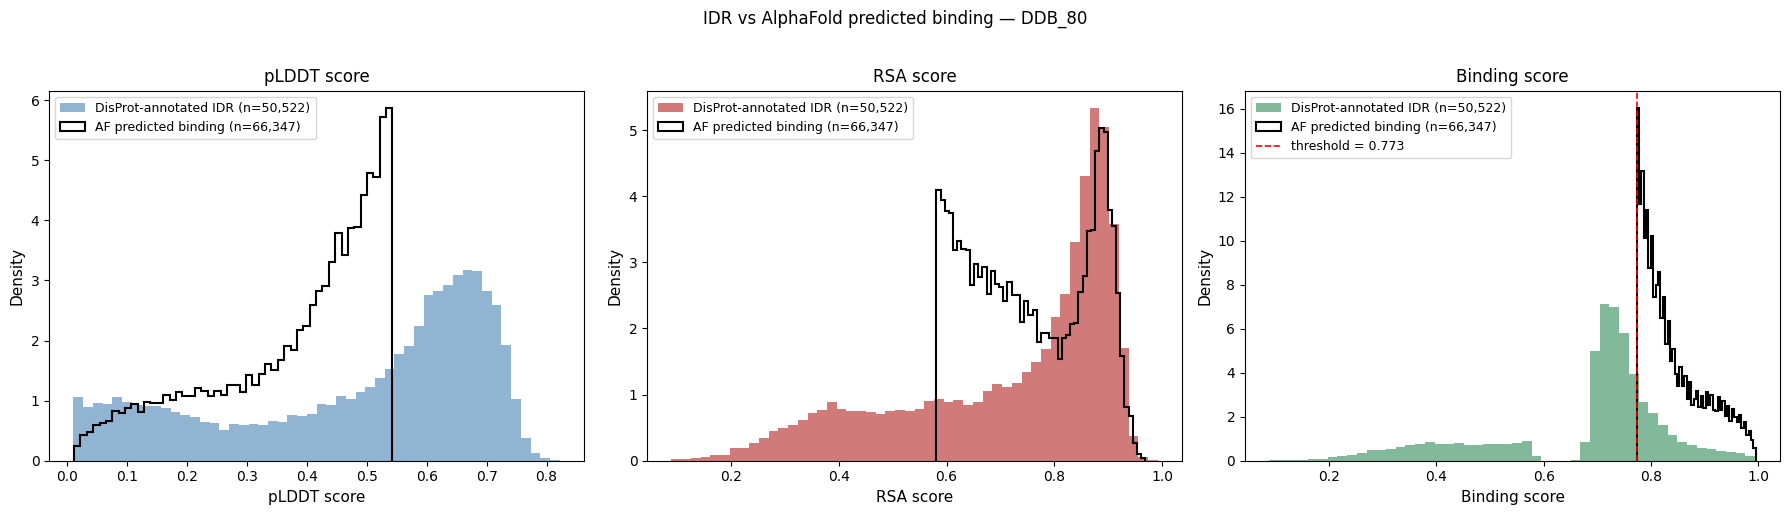


Metric             p-value    r_rb        Entità
----------------------------------------------------
pLDDT           0.0000e+00   0.389        medium
RSA             9.7353e-12   0.023    negligible
Binding         0.0000e+00   0.779         large


In [ ]:
# Cell 30 — AlphaFold Binding
AF_THR  = 0.773
idr_pdb = ref_lip_af_DOB
ones_af = merged_lip_af[merged_lip_af['af_pred'] == 1]

bins = 50
metrics = [
    ('disorder_plddt', 'pLDDT score',  'steelblue'),
    ('disorder_rsa',   'RSA score',    'firebrick'),
    ('binding',        'Binding score','seagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, xlabel, color) in zip(axes, metrics):
    ax.hist(idr_pdb[col].dropna(), bins=bins,
            color=color, alpha=0.6, density=True,
            label=f'DisProt-annotated IDR (n={idr_pdb[col].notna().sum():,})')
    ax.hist(ones_af[col].dropna(), bins=bins,
            histtype='step', color='black', linewidth=1.5, density=True,
            label=f'AF predicted binding (n={ones_af[col].notna().sum():,})')
    if col == 'binding':
        ax.axvline(AF_THR, color='red', linestyle='--', linewidth=1.2, label=f'threshold = {AF_THR}')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(xlabel, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle(f'IDR vs AlphaFold predicted binding — {cfg["label"]}', fontsize=12, y=1.02)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, 'hist_rsa_binding_plddt_density_AF.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Statistiche: Mann-Whitney U + rank-biserial correlation (effect size)
print(f"\n{'Metric':<12}  {'p-value':>12}  {'r_rb':>6}  {'Entit\u00e0':>12}")
print("-" * 52)
for col, xlabel in [('disorder_plddt', 'pLDDT'), ('disorder_rsa', 'RSA'), ('binding', 'Binding')]:
    a        = idr_pdb[col].dropna()
    b        = ones_af[col].dropna()
    U, p     = mannwhitneyu(a, b, alternative='two-sided')
    n1, n2   = len(a), len(b)
    r_rb     = abs(1 - 2 * U / (n1 * n2))
    size_lbl = ('large'      if r_rb >= 0.5 else
                'medium'     if r_rb >= 0.3 else
                'small'      if r_rb >= 0.1 else
                'negligible')
    print(f"{xlabel:<12}  {p:>12.4e}  {r_rb:>6.3f}  {size_lbl:>12}")

## 12e Distribuzione feature CIDER

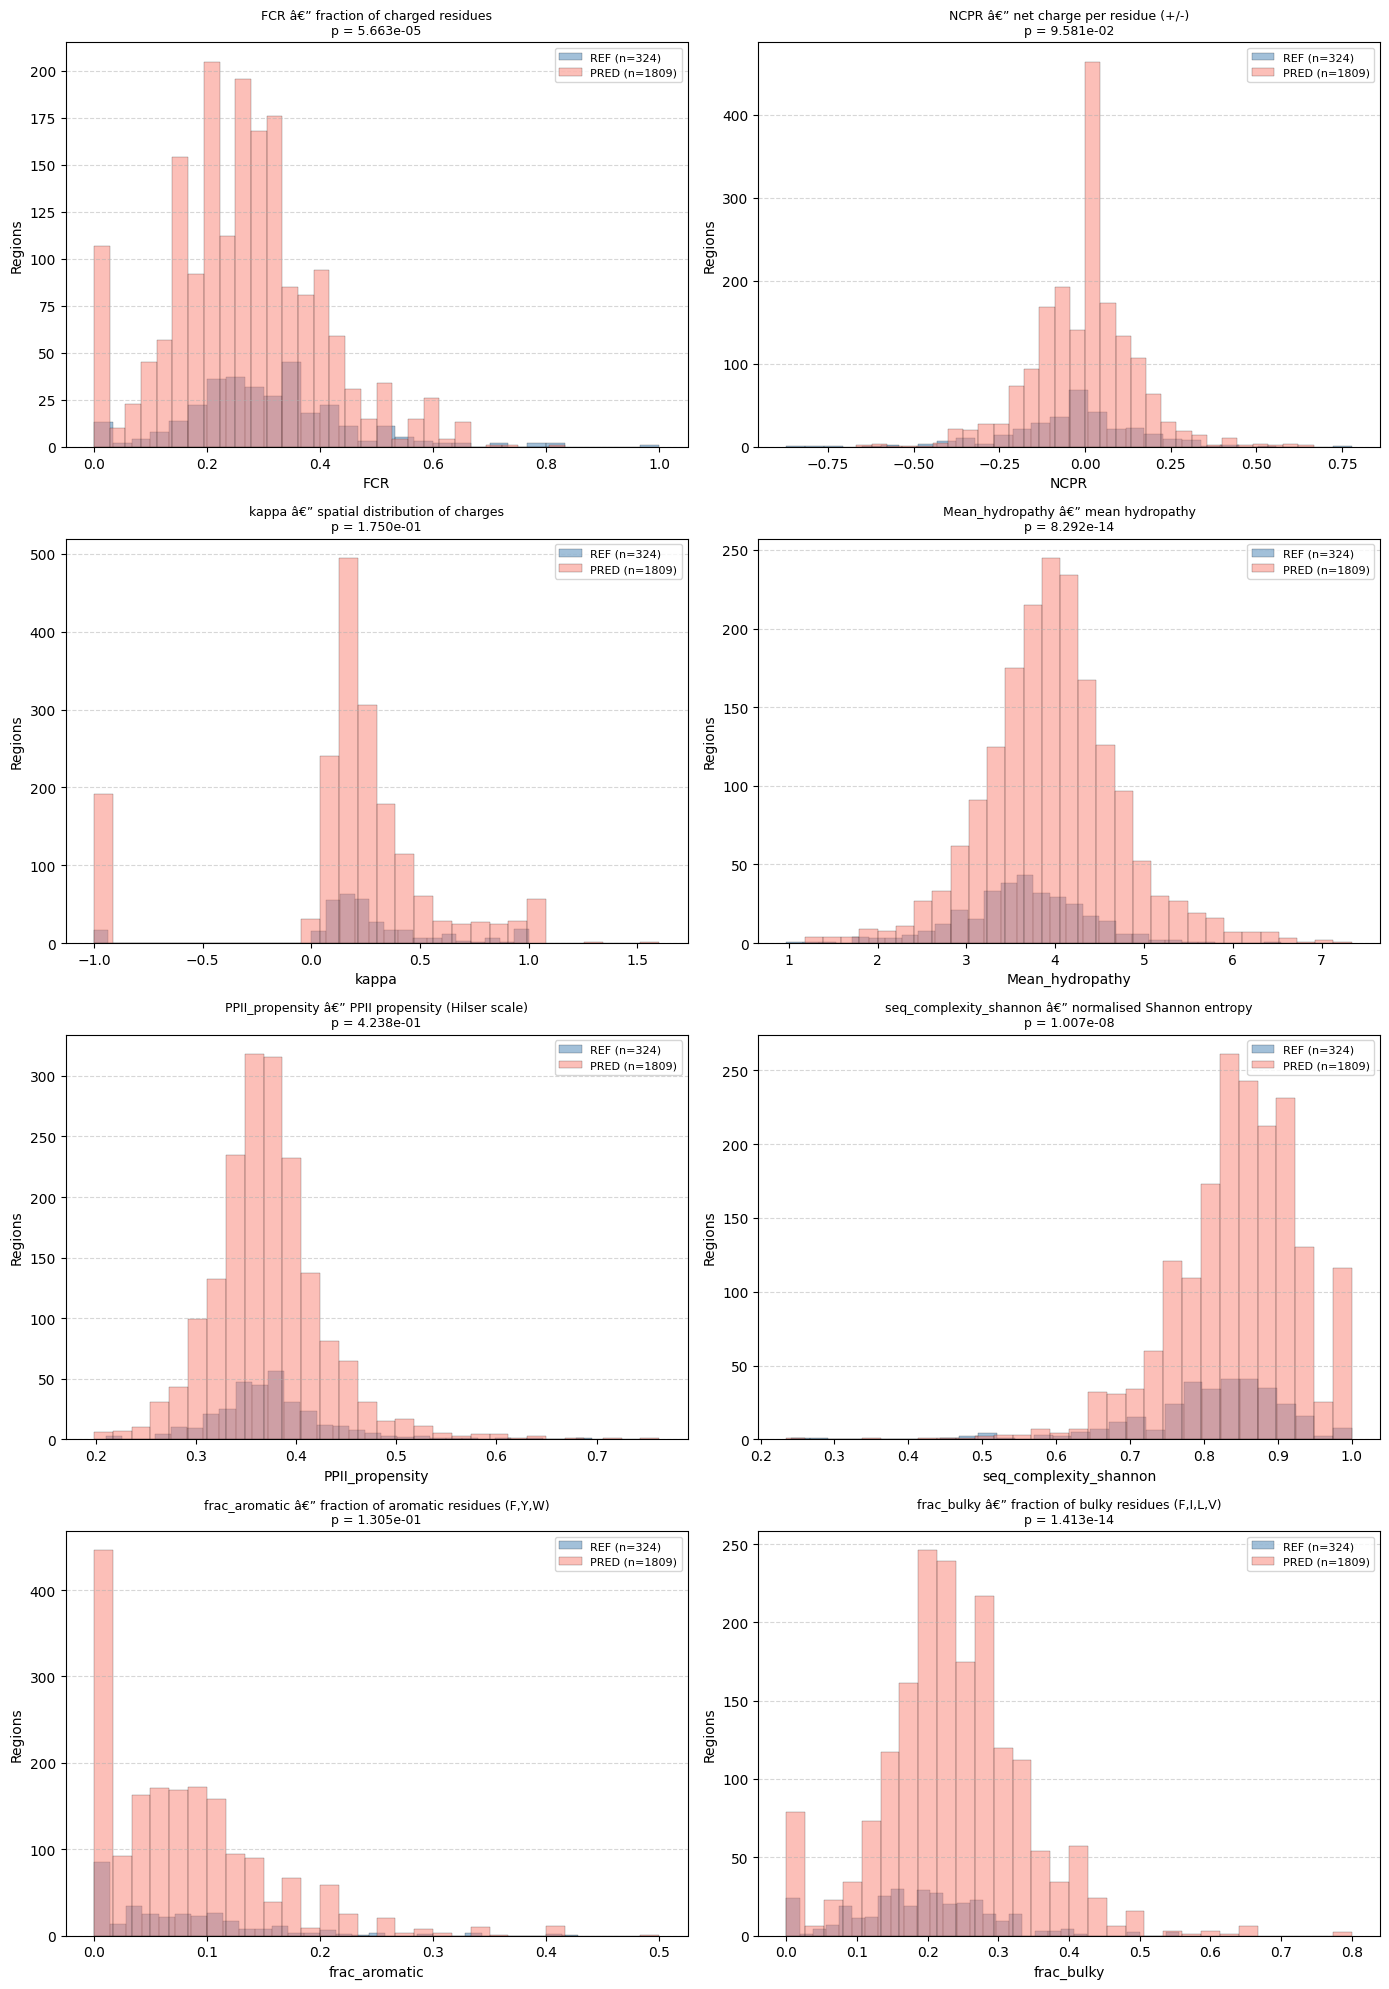

In [ ]:
features = ["FCR","NCPR","kappa","Mean_hydropathy",
            "PPII_propensity","seq_complexity_shannon","frac_aromatic","frac_bulky"]
meaning  = [
    "fraction of charged residues",
    "net charge per residue (+/-)",
    "spatial distribution of charges",
    "mean hydropathy",
    "PPII propensity (Hilser scale)",
    "normalised Shannon entropy",
    "fraction of aromatic residues (F,Y,W)",
    "fraction of bulky residues (F,I,L,V)",
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
for ax, feat, desc in zip(axes.flatten(), features, meaning):
    ax.hist(ref_cider_DF[feat].dropna(), bins=30, color="steelblue", alpha=0.5,
            edgecolor="black", lw=0.3, label=f"REF (n={len(ref_cider_DF)})")
    ax.hist(lip_pred_cider_DF[feat].dropna(), bins=30, color="salmon", alpha=0.5,
            edgecolor="black", lw=0.3, label=f"PRED (n={len(lip_pred_cider_DF)})")
    _, p = mannwhitneyu(ref_cider_DF[feat].dropna(),
                        lip_pred_cider_DF[feat].dropna(), alternative="two-sided")
    ax.set_title(f"{feat} â€” {desc}\np = {p:.3e}", fontsize=9)
    ax.set_xlabel(feat); ax.set_ylabel("Regions")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); 
_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "cider_features_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()


## 12e-bis Â· Feature CIDER (distribuzioni normalizzate)

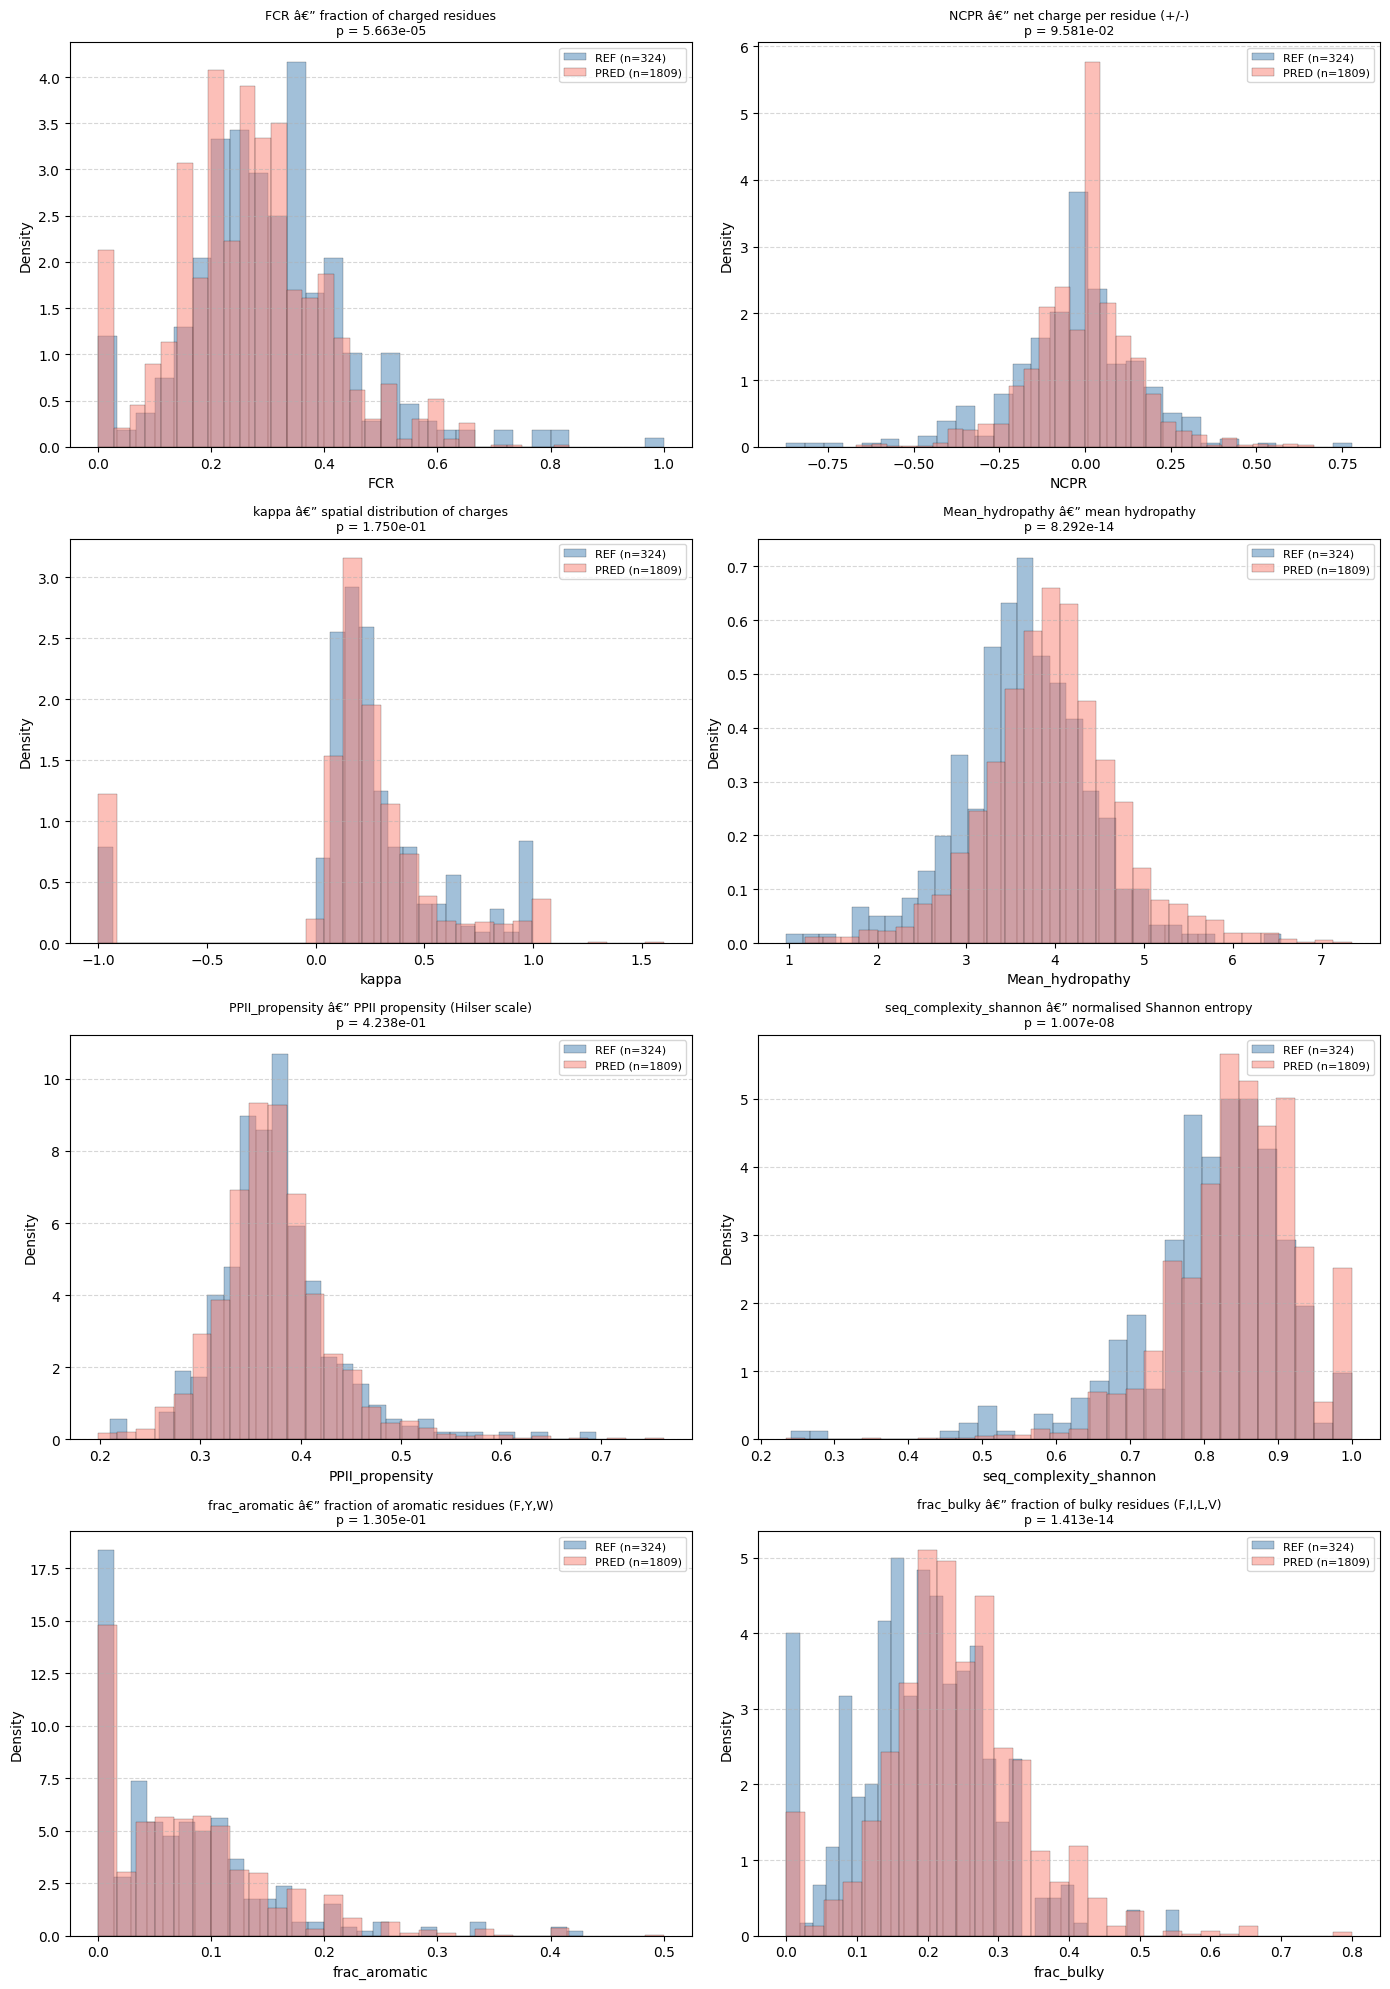

In [ ]:
# Cell 30
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
for ax, feat, desc in zip(axes.flatten(), features, meaning):
    ax.hist(ref_cider_DF[feat].dropna(), bins=30, color="steelblue", alpha=0.5,
            edgecolor="black", lw=0.3, label=f"REF (n={len(ref_cider_DF)})",
            density=True)
    ax.hist(lip_pred_cider_DF[feat].dropna(), bins=30, color="salmon", alpha=0.5,
            edgecolor="black", lw=0.3, label=f"PRED (n={len(lip_pred_cider_DF)})",
            density=True)
    _, p = mannwhitneyu(ref_cider_DF[feat].dropna(),
                        lip_pred_cider_DF[feat].dropna(), alternative="two-sided")
    ax.set_title(f"{feat} â€” {desc}\np = {p:.3e}", fontsize=9)
    ax.set_xlabel(feat); ax.set_ylabel("Density")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); 
_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "cider_features_distributions_normalized.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12f · Lunghezza regioni

## 12f-bis · Lunghezza regioni ECDF + boxplot

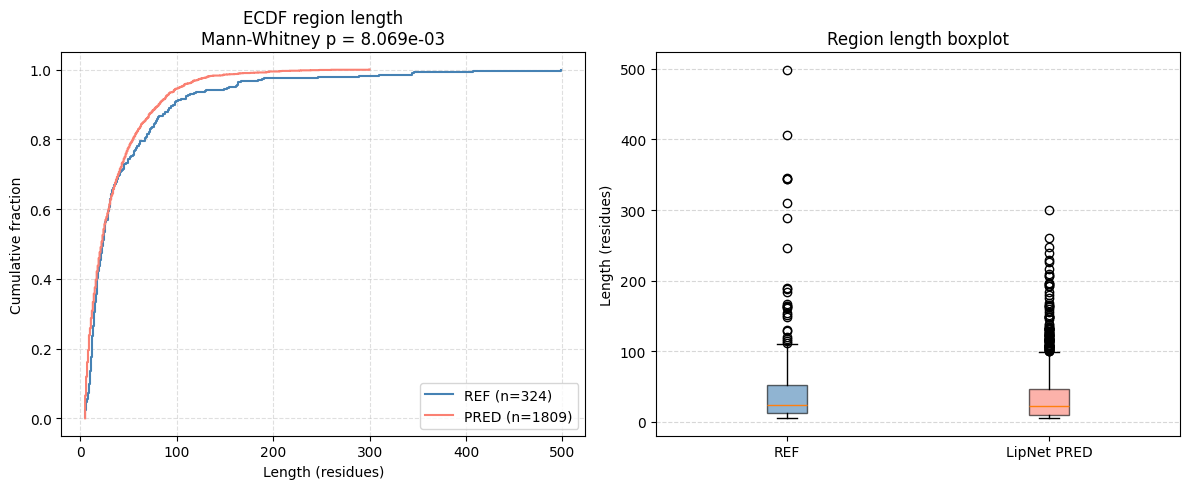

In [ ]:
# Cell 31
ref_l = ref_cider_DF["length"]
lip_l = lip_pred_cider_DF["length"]
_, p  = mannwhitneyu(ref_l, lip_l, alternative="two-sided")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ref_ecdf = np.arange(1, len(ref_l)+1) / len(ref_l)
lip_ecdf = np.arange(1, len(lip_l)+1) / len(lip_l)
axes[0].step(np.sort(ref_l), ref_ecdf, color="steelblue", where="post",
             label=f"REF (n={len(ref_l)})")
axes[0].step(np.sort(lip_l), lip_ecdf, color="salmon", where="post",
             label=f"PRED (n={len(lip_l)})")
axes[0].set_title(f"ECDF region length\nMann-Whitney p = {p:.3e}")
axes[0].set_xlabel("Length (residues)"); axes[0].set_ylabel("Cumulative fraction")
axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.4)

bp = axes[1].boxplot([ref_l.values, lip_l.values],
                     tick_labels=["REF","LipNet PRED"], patch_artist=True)
for patch, color in zip(bp["boxes"], ["steelblue","salmon"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_ylabel("Length (residues)")
axes[1].set_title("Region length boxplot")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout(); 
_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "region_length_ecdf_boxplot.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12g · Violin CIDER feature per regione

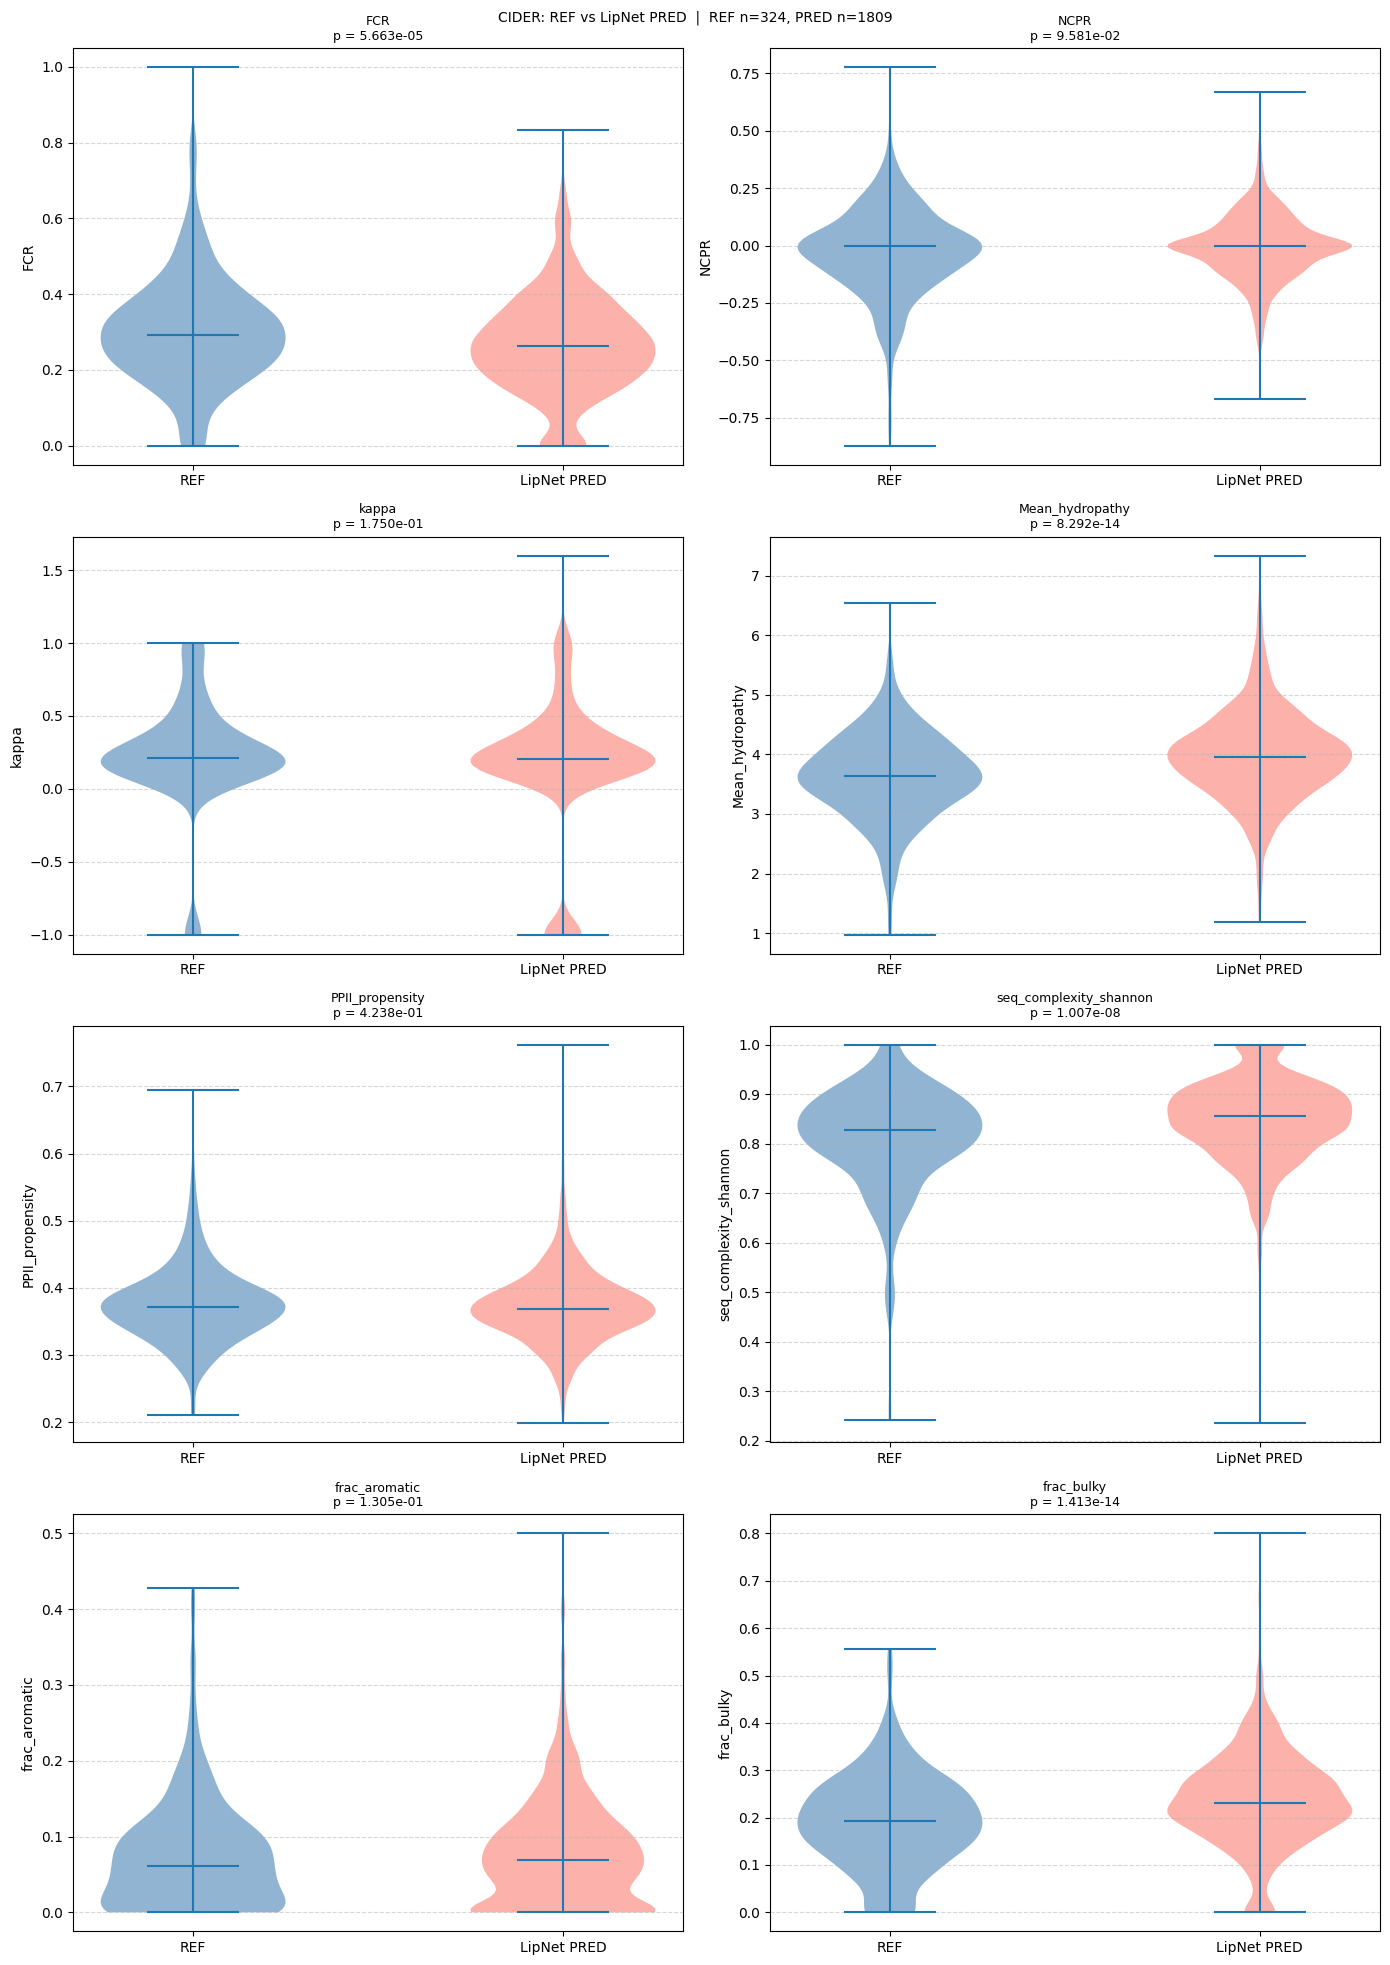

In [ ]:
# Cell 32
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
for ax, feat in zip(axes.flatten(), features):
    dr = ref_cider_DF[feat].dropna().values
    dp = lip_pred_cider_DF[feat].dropna().values
    parts = ax.violinplot([dr, dp], positions=[1, 2], showmedians=True, showextrema=True)
    parts["bodies"][0].set_facecolor("steelblue"); parts["bodies"][0].set_alpha(0.6)
    parts["bodies"][1].set_facecolor("salmon");    parts["bodies"][1].set_alpha(0.6)
    _, p = mannwhitneyu(dr, dp, alternative="two-sided")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["REF", "LipNet PRED"])
    ax.set_title(f"{feat}\np = {p:.3e}", fontsize=9)
    ax.set_ylabel(feat)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.suptitle(
    f"CIDER: REF vs LipNet PRED  |  REF n={len(ref_cider_DF)}, PRED n={len(lip_pred_cider_DF)}",
    fontsize=10
)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "cider_violin_ref_vs_pred.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12g.2 · Violin CIDER solo regioni LipNet TP (score threshold)

In [ ]:
# Cell 33
LIP_SCORE_THRESHOLD = cfg["lip_score_thr"]  # set in CONFIGS, cell 20

# For each LipNet predicted region, compute:
#   - mean lipnet_score across region residues
#   - se almeno un residuo ha ref_seq == "1" (True Positive)
merged_by_disprot = merged_lip_af.groupby("disprot_id")

mask_tp = []
for _, row in DF_LIP_pred_cider_af.iterrows():
    try:
        prot = merged_by_disprot.get_group(row["disprot_id"])
    except KeyError:
        mask_tp.append(False)
        continue
    in_region  = prot[(prot["pos"] >= row["start"]) & (prot["pos"] <= row["end"])]
    has_ref1   = (in_region["ref_seq"] == "1").any()
    high_score = in_region["lipnet_score"].mean() >= LIP_SCORE_THRESHOLD
    mask_tp.append(bool(has_ref1 and high_score))

DF_LIP_tp = DF_LIP_pred_cider_af[mask_tp].copy()
print(f"Total LIPNet regions:                   {len(DF_LIP_pred_cider_af)}")
print(f"TP regions (score>={LIP_SCORE_THRESHOLD}, at least 1 ref==1): {len(DF_LIP_tp)}")


Total LIPNet regions:                   1809
TP regions (score>=0.494, at least 1 ref==1): 347


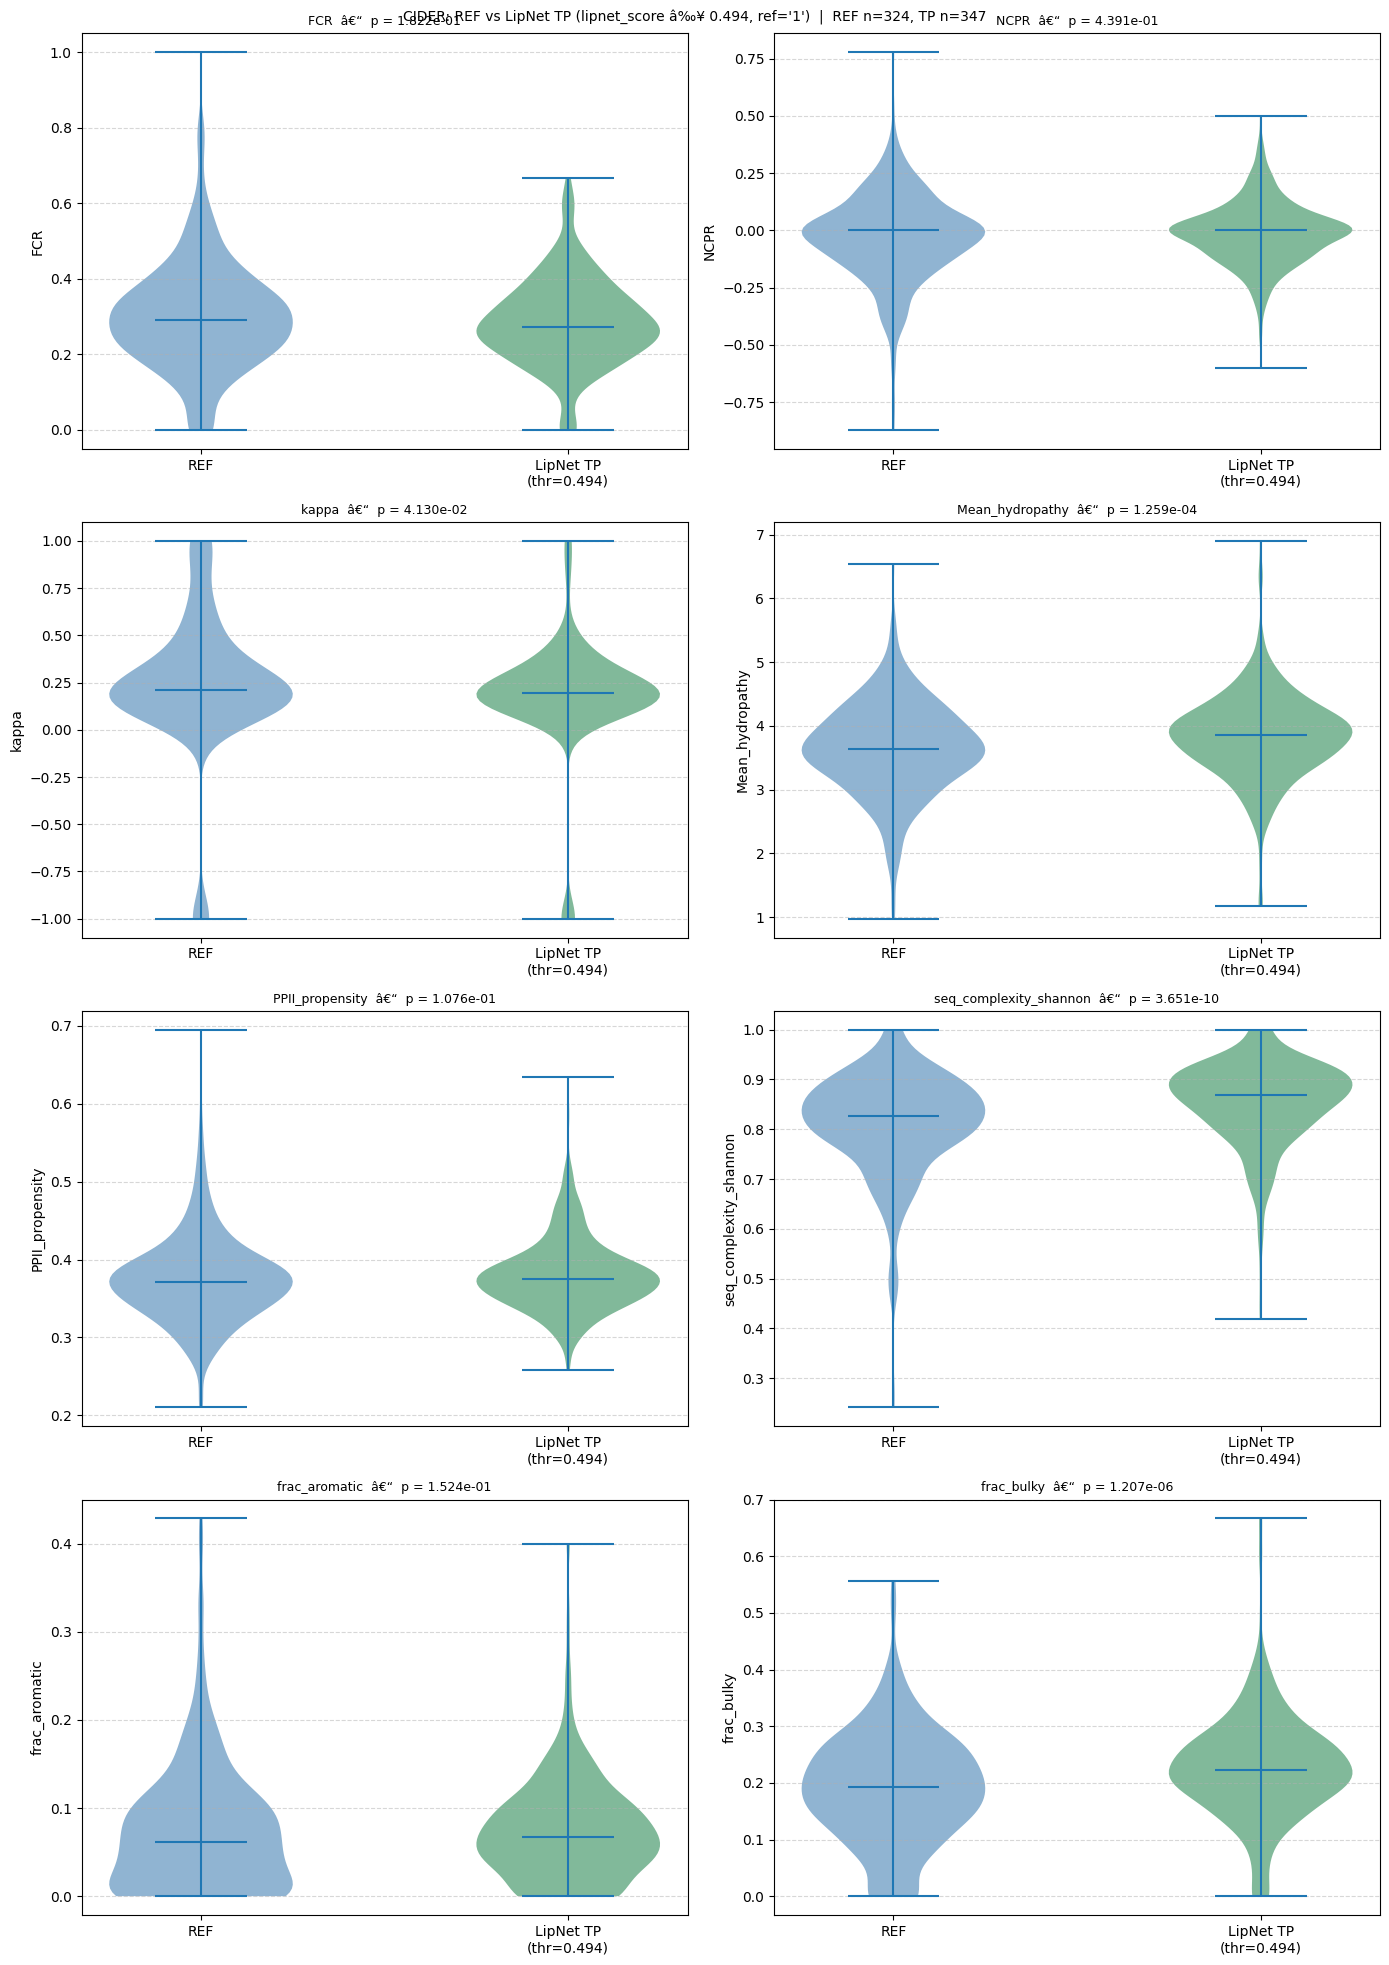

In [ ]:
# Cell 34
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
for ax, feat in zip(axes.flatten(), features):
    dr  = ref_cider_DF[feat].dropna().values
    dtp = DF_LIP_tp[feat].dropna().values
    if len(dtp) < 2:
        ax.set_title(f"{feat}\n(too few TP regions)")
        continue
    parts = ax.violinplot([dr, dtp], positions=[1, 2],
                          showmedians=True, showextrema=True)
    parts["bodies"][0].set_facecolor("steelblue"); parts["bodies"][0].set_alpha(0.6)
    parts["bodies"][1].set_facecolor("seagreen");  parts["bodies"][1].set_alpha(0.6)
    _, p = mannwhitneyu(dr, dtp, alternative="two-sided")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["REF", f"LipNet TP\n(thr={LIP_SCORE_THRESHOLD})"])
    ax.set_title(f"{feat}  â€“  p = {p:.3e}", fontsize=9)
    ax.set_ylabel(feat)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.suptitle(
    f"CIDER: REF vs LipNet TP (lipnet_score â‰¥ {LIP_SCORE_THRESHOLD}, ref='1')"
    f"  |  REF n={len(ref_cider_DF)}, TP n={len(DF_LIP_tp)}",
    fontsize=10
)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "cider_violin_ref_vs_tp.png"), dpi=150, bbox_inches="tight")
plt.show()

---
# 13 · Analisi Confusion Matrix

## 13a · Proprietà  strutturali per gruppo (TP/FP/FN/TN)

## 13.0 · Confusion matrix 2x2 globale

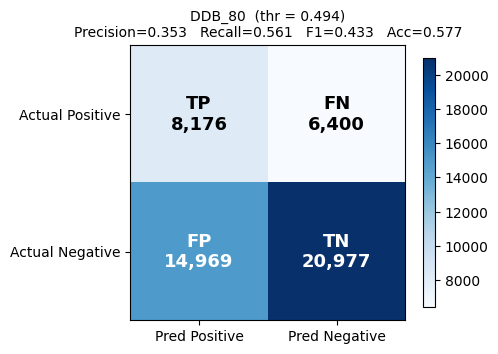

TP=8,176  FP=14,969  FN=6,400  TN=20,977
Precision : 0.3533
Recall    : 0.5609
F1        : 0.4335
Accuracy  : 0.5770


In [ ]:
# Cell CM_global
df_cm_all = merged_lip_af[merged_lip_af["confusion_matrix"].isin(["TP","FP","FN","TN"])].copy()

tp = (df_cm_all["confusion_matrix"] == "TP").sum()
fp = (df_cm_all["confusion_matrix"] == "FP").sum()
fn = (df_cm_all["confusion_matrix"] == "FN").sum()
tn = (df_cm_all["confusion_matrix"] == "TN").sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_global = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (tp + tn) / (tp + fp + fn + tn)

# matrice: righe = actual (pos/neg), colonne = pred (pos/neg)
cm_matrix = np.array([[tp, fn],
                      [fp, tn]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_matrix, cmap="Blues")
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pred Positive", "Pred Negative"], fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual Positive", "Actual Negative"], fontsize=10)

labels_pos = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        val = cm_matrix[i, j]
        color = "white" if val > cm_matrix.max() * 0.6 else "black"
        ax.text(j, i, f"{labels_pos[i][j]}\n{val:,}",
                ha="center", va="center", fontsize=13, color=color, fontweight="bold")

ax.set_title(
    f"{cfg['label']}  (thr = 0.494)\n"
    f"Precision={precision:.3f}   Recall={recall:.3f}   F1={f1_global:.3f}   Acc={accuracy:.3f}",
    fontsize=10
)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "confusion_matrix_global.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1_global:.4f}")
print(f"Accuracy  : {accuracy:.4f}")


In [ ]:
merged_lip_af

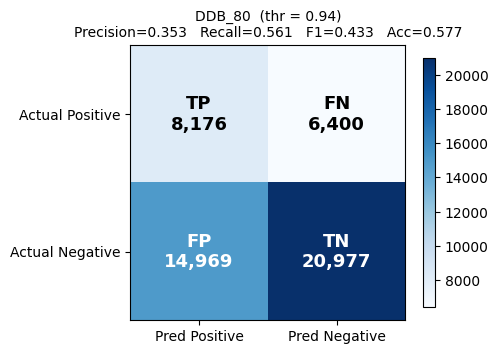

TP=8,176  FP=14,969  FN=6,400  TN=20,977
Precision : 0.3533
Recall    : 0.5609
F1        : 0.4335
Accuracy  : 0.5770


In [ ]:
# LIPNET THRESHOLD 0.94
# Cell CM_global
df_cm_all = merged_lip_af[merged_lip_af["confusion_matrix"].isin(["TP","FP","FN","TN"])].copy()

tp = (df_cm_all["confusion_matrix"] == "TP").sum()
fp = (df_cm_all["confusion_matrix"] == "FP").sum()
fn = (df_cm_all["confusion_matrix"] == "FN").sum()
tn = (df_cm_all["confusion_matrix"] == "TN").sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_global = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (tp + tn) / (tp + fp + fn + tn)

# matrice: righe = actual (pos/neg), colonne = pred (pos/neg)
cm_matrix = np.array([[tp, fn],
                      [fp, tn]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_matrix, cmap="Blues")
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pred Positive", "Pred Negative"], fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual Positive", "Actual Negative"], fontsize=10)

labels_pos = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        val = cm_matrix[i, j]
        color = "white" if val > cm_matrix.max() * 0.6 else "black"
        ax.text(j, i, f"{labels_pos[i][j]}\n{val:,}",
                ha="center", va="center", fontsize=13, color=color, fontweight="bold")

ax.set_title(
    f"{cfg['label']}  (thr = 0.94)\n"
    f"Precision={precision:.3f}   Recall={recall:.3f}   F1={f1_global:.3f}   Acc={accuracy:.3f}",
    fontsize=10
)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "confusion_matrix_global.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1_global:.4f}")
print(f"Accuracy  : {accuracy:.4f}")


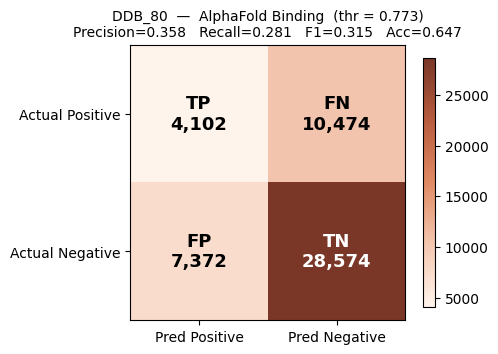

TP=4,102  FP=7,372  FN=10,474  TN=28,574
Precision : 0.3575
Recall    : 0.2814
F1        : 0.3149
Accuracy  : 0.6468


In [ ]:
# Cell CM_AF_global
AF_BINDING_THR = 0.773  # default CAID threshold

df_af = merged_lip_af[merged_lip_af["ref_seq"].isin(["0", "1"])].copy()
df_af["af_pred"] = (df_af["binding"] >= AF_BINDING_THR).astype(int)
df_af["ref_bin"] = df_af["ref_seq"].astype(int)

tp_af = int(((df_af["ref_bin"] == 1) & (df_af["af_pred"] == 1)).sum())
fp_af = int(((df_af["ref_bin"] == 0) & (df_af["af_pred"] == 1)).sum())
fn_af = int(((df_af["ref_bin"] == 1) & (df_af["af_pred"] == 0)).sum())
tn_af = int(((df_af["ref_bin"] == 0) & (df_af["af_pred"] == 0)).sum())

precision_af = tp_af / (tp_af + fp_af) if (tp_af + fp_af) > 0 else 0
recall_af    = tp_af / (tp_af + fn_af) if (tp_af + fn_af) > 0 else 0
f1_af        = 2 * precision_af * recall_af / (precision_af + recall_af) if (precision_af + recall_af) > 0 else 0
accuracy_af  = (tp_af + tn_af) / (tp_af + fp_af + fn_af + tn_af)

cm_matrix_af = np.array([[tp_af, fn_af],
                          [fp_af, tn_af]])

terracotta_cmap = LinearSegmentedColormap.from_list(
    "terracotta",
    ["#fff4ec", "#f4c7b0", "#e08a63", "#b85c3e", "#7a3728"]
)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_matrix_af, cmap=terracotta_cmap)
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pred Positive", "Pred Negative"], fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual Positive", "Actual Negative"], fontsize=10)

labels_pos = [["TP", "FN"], ["FP", "TN"]]
cm_vals    = [[tp_af, fn_af], [fp_af, tn_af]]
for i in range(2):
    for j in range(2):
        val   = cm_vals[i][j]
        color = "white" if cm_matrix_af[i, j] > cm_matrix_af.max() / 2 else "black"
        ax.text(j, i, f"{labels_pos[i][j]}\n{val:,}",
                ha="center", va="center", fontsize=13, color=color, fontweight="bold")

ax.set_title(
    f"{cfg['label']}  —  AlphaFold Binding  (thr = {AF_BINDING_THR})\n"
    f"Precision={precision_af:.3f}   Recall={recall_af:.3f}   F1={f1_af:.3f}   Acc={accuracy_af:.3f}",
    fontsize=10
)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "confusion_matrix_AF_binding.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"TP={tp_af:,}  FP={fp_af:,}  FN={fn_af:,}  TN={tn_af:,}")
print(f"Precision : {precision_af:.4f}")
print(f"Recall    : {recall_af:.4f}")
print(f"F1        : {f1_af:.4f}")
print(f"Accuracy  : {accuracy_af:.4f}")

## 13.1 · Calibration curve — LIPNet su DDB_80

Reliability diagram: verifica se lo score LIPNet è una probabilità calibrata.
Un modello perfettamente calibrato ha la curva sulla diagonale y=x
(score=0.8 → 80% dei residui sono davvero binding).

Evaluable IDR residues: 50,522  (binding=1: 14,576, non-binding=0: 35,946)


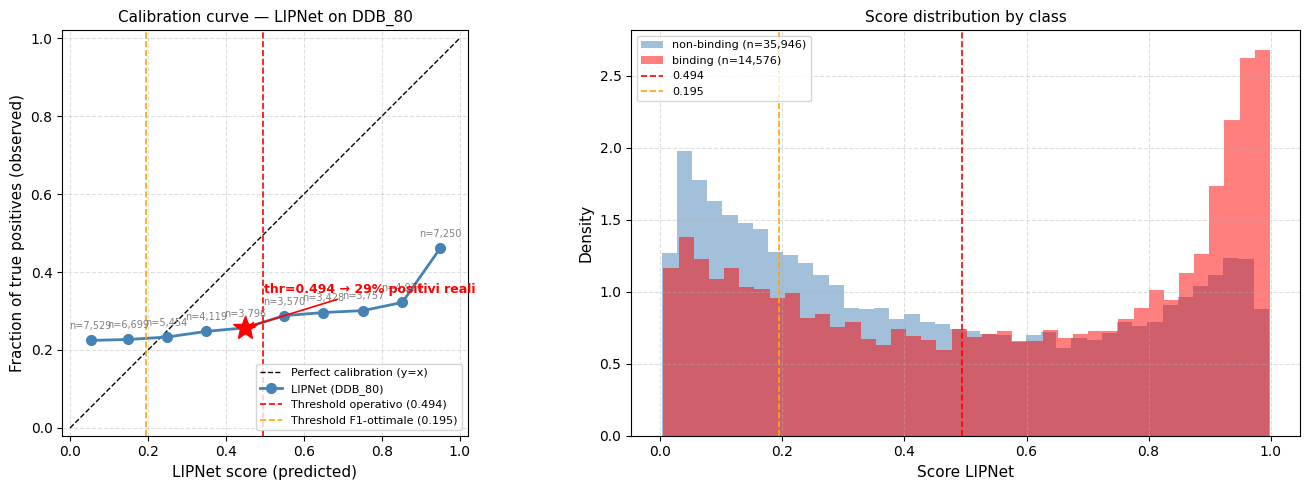


Calibrazione LIPNet on DDB_80:
    Mean score    % true pos      bias  n residues
  --------------------------------------------------
          0.05         22.4%    +0.172       7,529  (sottostima)
          0.15         22.7%    +0.079       6,699  (sottostima)
          0.25         23.3%    -0.015       5,454  (sovrastima)
          0.35         24.8%    -0.102       4,119  (sovrastima)
          0.45         25.7%    -0.192       3,796  (sovrastima)
          0.55         28.8%    -0.261       3,570  (sovrastima)
          0.65         29.6%    -0.354       3,428  (sovrastima)
          0.75         30.1%    -0.451       3,757  (sovrastima)
          0.85         32.2%    -0.530       4,920  (sovrastima)
          0.95         46.1%    -0.489       7,250  (sovrastima)

  Bias medio pesato: -0.1860
  → LIPNet sovrastima sistematicamente la probabilità di binding.


In [ ]:
# Cell calibration_curve — Graf. 18
# Reliability diagram: fraction_of_positives vs mean_predicted_value per bin.
# Implementazione manuale (non richiede sklearn).

import numpy as np
import matplotlib.pyplot as plt
import os

# ── Step 1: filter evaluable residues ────────────────────────────────────────
df_cal = merged_lip_af[merged_lip_af['ref_seq'].isin(['0', '1'])].copy()
df_cal['ref_binary'] = (df_cal['ref_seq'] == '1').astype(int)
print(f"Evaluable IDR residues: {len(df_cal):,}  "
      f"(binding=1: {df_cal['ref_binary'].sum():,}, "
      f"non-binding=0: {(df_cal['ref_binary']==0).sum():,})")

# ── Step 2: calibration curve (implementazione manuale) ──────────────────────
bins    = np.linspace(0, 1, 11)
bin_idx = np.clip(np.digitize(df_cal['lipnet_score'], bins) - 1, 0, 9)

frac_pos, mean_pred, bin_counts = [], [], []
for i in range(10):
    mask = bin_idx == i
    if mask.sum() > 0:
        frac_pos.append(df_cal.loc[mask, 'ref_binary'].mean())
        mean_pred.append(df_cal.loc[mask, 'lipnet_score'].mean())
        bin_counts.append(int(mask.sum()))

frac_pos  = np.array(frac_pos)
mean_pred = np.array(mean_pred)
bin_counts = np.array(bin_counts)

# ── Step 3: plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pannello sinistro — reliability diagram
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration (y=x)')
ax.plot(mean_pred, frac_pos, 'o-', color='steelblue', lw=2,
        markersize=7, label='LIPNet (DDB_80)')
# annotation: number of residues per bin
for x, y, n in zip(mean_pred, frac_pos, bin_counts):
    ax.annotate(f'n={n:,}', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7, color='gray')
ax.axvline(0.494, color='red',    linestyle='--', lw=1.2,
           label='Threshold operativo (0.494)')
# punto stella al threshold 0.494
_idx_thr = int(np.argmin(np.abs(mean_pred - 0.494)))
ax.plot(mean_pred[_idx_thr], frac_pos[_idx_thr],
        '*', color='red', markersize=18, zorder=5)
ax.annotate('thr=0.494 → 29% positivi reali',
            xy=(mean_pred[_idx_thr], frac_pos[_idx_thr]),
            xytext=(mean_pred[_idx_thr] + 0.05, frac_pos[_idx_thr] + 0.09),
            fontsize=9, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
ax.axvline(0.195, color='orange', linestyle='--', lw=1.2,
           label='Threshold F1-ottimale (0.195)')
ax.set_xlabel('LIPNet score (predicted)', fontsize=11)
ax.set_ylabel('Fraction of true positives (observed)', fontsize=11)
ax.set_title(f'Calibration curve — LIPNet on {cfg["label"]}', fontsize=11)
ax.legend(fontsize=8)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_box_aspect(1)
ax.grid(True, linestyle='--', alpha=0.4)

# right panel — score distribution by class
ax2 = axes[1]
scores_neg = df_cal.loc[df_cal['ref_binary'] == 0, 'lipnet_score']
scores_pos = df_cal.loc[df_cal['ref_binary'] == 1, 'lipnet_score']
ax2.hist(scores_neg, bins=40, density=True, alpha=0.5, color='steelblue',
         label=f"non-binding (n={len(scores_neg):,})")
ax2.hist(scores_pos, bins=40, density=True, alpha=0.5, color='red',
         label=f"binding (n={len(scores_pos):,})")
ax2.axvline(0.494, color='red',    linestyle='--', lw=1.2, label='0.494')
ax2.axvline(0.195, color='orange', linestyle='--', lw=1.2, label='0.195')
ax2.set_xlabel('Score LIPNet', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Score distribution by class', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

_fig_dir = os.path.join("..",
                        "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, f'{cfg["label"]}_calibration_curve.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── Step 4: interpretazione ───────────────────────────────────────────────────
print(f"\nCalibrazione LIPNet on {cfg['label']}:")
print(f"  {'Mean score':>12}  {'% true pos':>12}  {'bias':>8}  {'n residues':>10}")
print("  " + "-"*50)
for x, y, n in zip(mean_pred, frac_pos, bin_counts):
    bias = y - x
    direction = "sovrastima" if bias < 0 else "sottostima"
    print(f"  {x:>12.2f}  {y*100:>11.1f}%  {bias:>+8.3f}  {n:>10,}  ({direction})")

# bias complessivo
overall_bias = float(np.average(frac_pos - mean_pred, weights=bin_counts))
print(f"\n  Bias medio pesato: {overall_bias:+.4f}")
if overall_bias < -0.05:
    print("  → LIPNet sovrastima sistematicamente la probabilità di binding.")
elif overall_bias > 0.05:
    print("  → LIPNet sottostima sistematicamente la probabilità di binding.")
else:
    print("  → LIPNet è reasonably calibrated on this reference.")


## 13a-bis Â· ProprietÃ  strutturali per gruppo (label corrette)

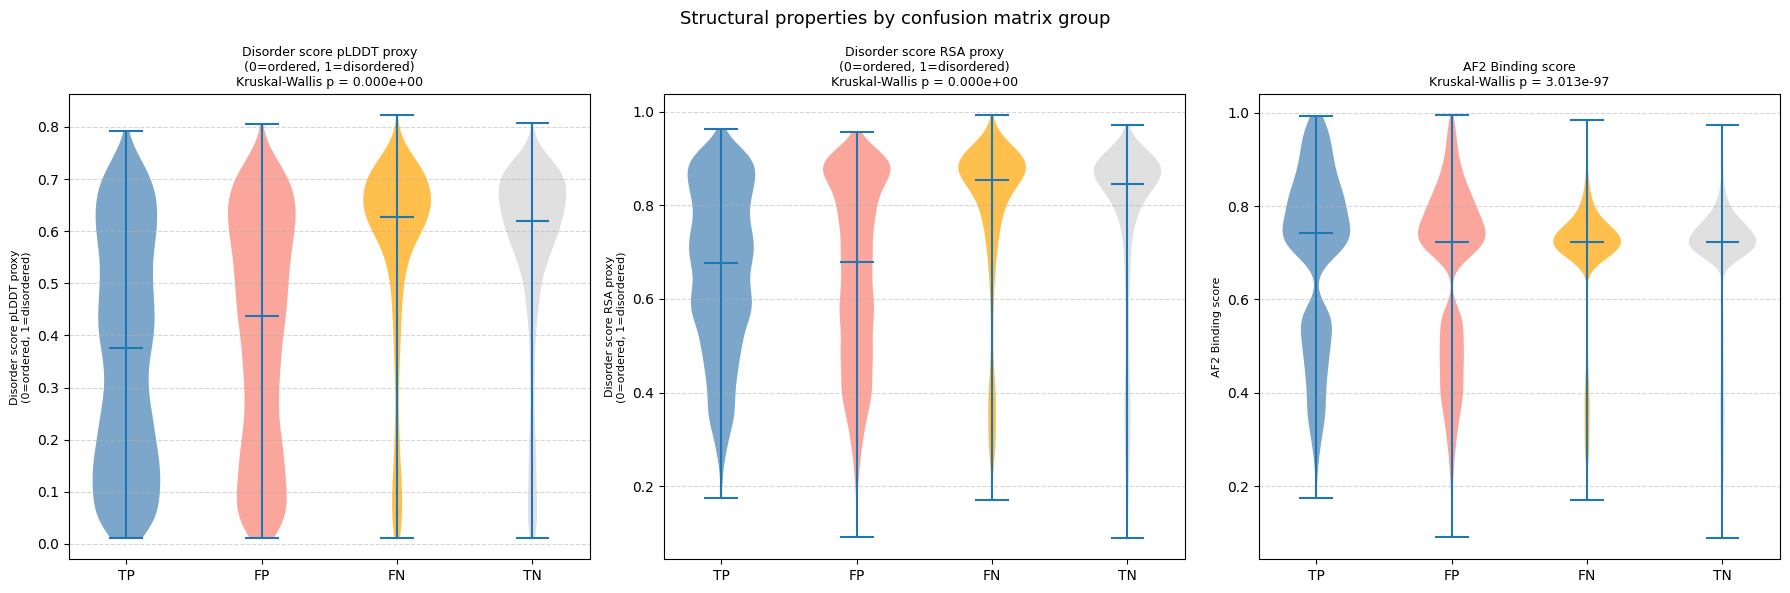

In [ ]:
# Cell 35
df_cm   = merged_lip_af[merged_lip_af["confusion_matrix"].isin(["TP","FP","FN","TN"])].copy()
groups  = ["TP","FP","FN","TN"]
colors  = {"TP":"steelblue","FP":"salmon","FN":"orange","TN":"lightgray"}
metrics_bis = [
    ("disorder_plddt", "Disorder score pLDDT proxy\n(0=ordered, 1=disordered)"),
    ("disorder_rsa",   "Disorder score RSA proxy\n(0=ordered, 1=disordered)"),
    ("binding",        "AF2 Binding score"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (col, label) in zip(axes, metrics_bis):
    data = [df_cm[df_cm["confusion_matrix"]==g][col].dropna().values for g in groups]
    parts = ax.violinplot(data, positions=range(1,5), showmedians=True, showextrema=True)
    for body, g in zip(parts["bodies"], groups):
        body.set_facecolor(colors[g]); body.set_alpha(0.7)
    _, p = kruskal(*data)
    ax.set_title(f"{label}\nKruskal-Wallis p = {p:.3e}", fontsize=9)
    ax.set_xticks(range(1,5)); ax.set_xticklabels(groups)
    ax.set_ylabel(label, fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.suptitle("Structural properties by confusion matrix group", fontsize=13)
plt.tight_layout(); 
_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "structural_properties_by_cm_group.png"), dpi=150, bbox_inches="tight")
plt.show()

## 13b · Precision e Recall per proteina

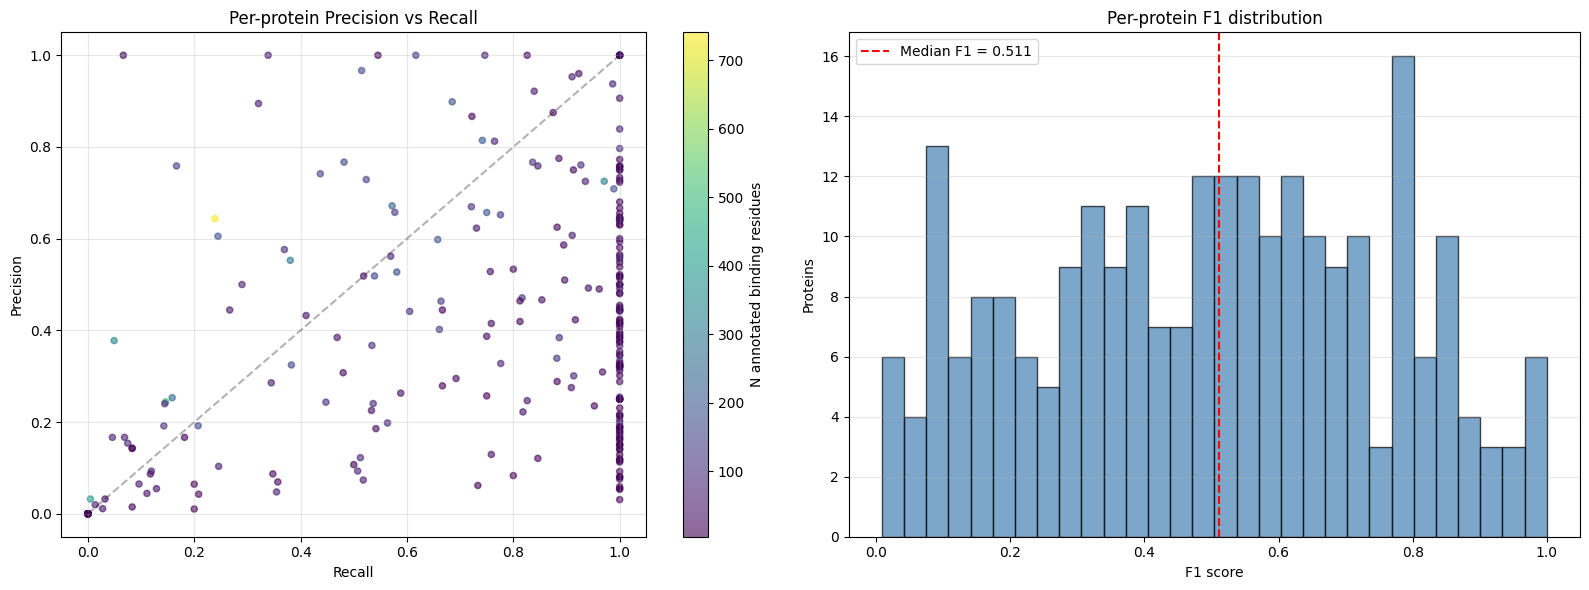

Proteins analysed: 268 | Median F1: 0.511 | Mean F1: 0.495


In [ ]:
# Cell 36
rows = []
for prot_id, grp in df_cm.groupby('disprot_id'):
    cm = grp['confusion_matrix']
    tp, fp, fn = [(cm == g).sum() for g in ['TP', 'FP', 'FN']]
    n_binding = tp + fn
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall    = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = (2 * precision * recall / (precision + recall)
          if not any(np.isnan([precision, recall])) and (precision + recall) > 0
          else np.nan)
    rows.append({'disprot_id': prot_id, 'TP': tp, 'FP': fp, 'FN': fn,
                 'n_binding': n_binding, 'precision': precision,
                 'recall': recall, 'f1': f1})

per_prot = pd.DataFrame(rows)
valid    = per_prot[per_prot['n_binding'] > 0].copy()
f1_vals  = valid['f1'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(valid['recall'], valid['precision'],
                     c=valid['n_binding'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(sc, ax=axes[0], label='N annotated binding residues')
axes[0].set(xlabel='Recall', ylabel='Precision',
            title='Per-protein Precision vs Recall',
            xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].grid(True, alpha=0.3)

axes[1].hist(f1_vals, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(f1_vals.median(), color='red', linestyle='--',
                label=f'Median F1 = {f1_vals.median():.3f}')
axes[1].set(xlabel='F1 score', ylabel='Proteins', title='Per-protein F1 distribution')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "precision_recall_per_protein.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f'Proteins analysed: {len(valid)}'
      f' | Median F1: {f1_vals.median():.3f}'
      f' | Mean F1: {f1_vals.mean():.3f}')


## 13c · Prossimità  FP al TP più vicino

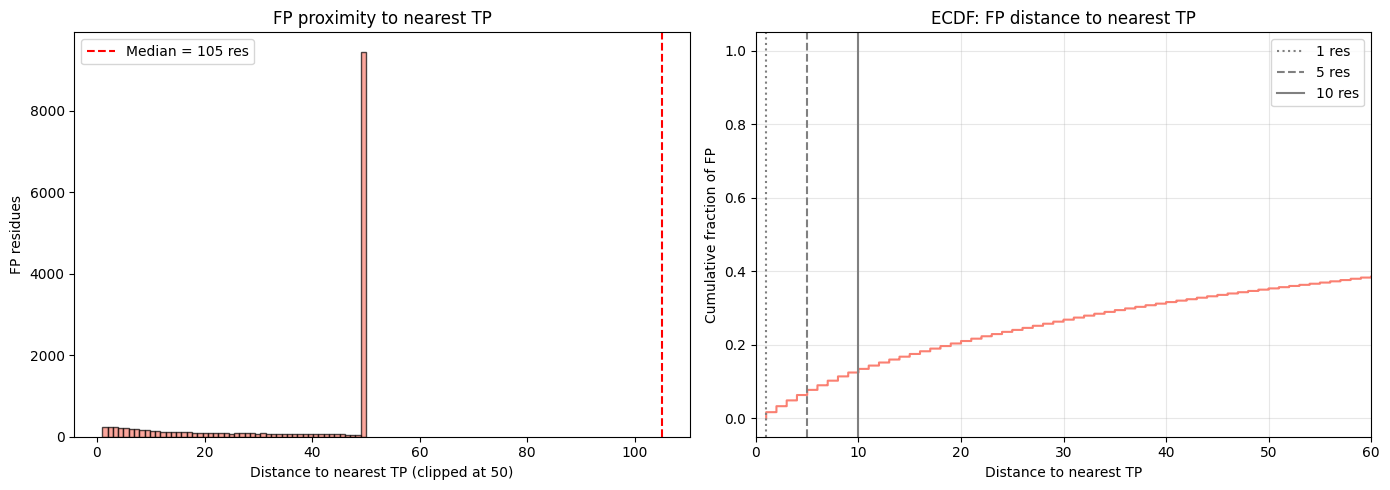

FP adjacent (â‰¤1):  1.7%
FP near    (â‰¤5):   7.7%
FP remote  (>10):  86.5%


In [ ]:
# Cell 37
distances = []
for prot_id, grp in df_cm.groupby('disprot_id'):
    grp     = grp.sort_values('pos')
    fp_pos  = grp[grp['confusion_matrix']=='FP']['pos'].values
    tp_pos  = grp[grp['confusion_matrix']=='TP']['pos'].values
    if len(fp_pos) == 0 or len(tp_pos) == 0:
        continue
    distances.extend(int(np.min(np.abs(tp_pos - fp))) for fp in fp_pos)

distances = np.array(distances)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.clip(distances, 0, 50), bins=50, color='salmon', alpha=0.7, edgecolor='black')
axes[0].axvline(np.median(distances), color='red', linestyle='--',
                label=f'Median = {np.median(distances):.0f} res')
axes[0].set(xlabel='Distance to nearest TP (clipped at 50)', ylabel='FP residues',
            title='FP proximity to nearest TP'); axes[0].legend()

sorted_d = np.sort(distances)
ecdf     = np.arange(1, len(sorted_d)+1) / len(sorted_d)
axes[1].step(sorted_d, ecdf, color='salmon', where='post')
for x, ls, lbl in [(1,':','1 res'),(5,'--','5 res'),(10,'-','10 res')]:
    axes[1].axvline(x, color='gray', linestyle=ls, label=lbl)
axes[1].set(xlabel='Distance to nearest TP', ylabel='Cumulative fraction of FP',
            title='ECDF: FP distance to nearest TP', xlim=(0,60))
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); 
_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "fp_proximity_to_tp.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f'FP adjacent (â‰¤1):  {(distances<=1).mean():.1%}')
print(f'FP near    (â‰¤5):   {(distances<=5).mean():.1%}')
print(f'FP remote  (>10):  {(distances>10).mean():.1%}')


## 13d · Lunghezza blocchi contigui FP / FN / TP

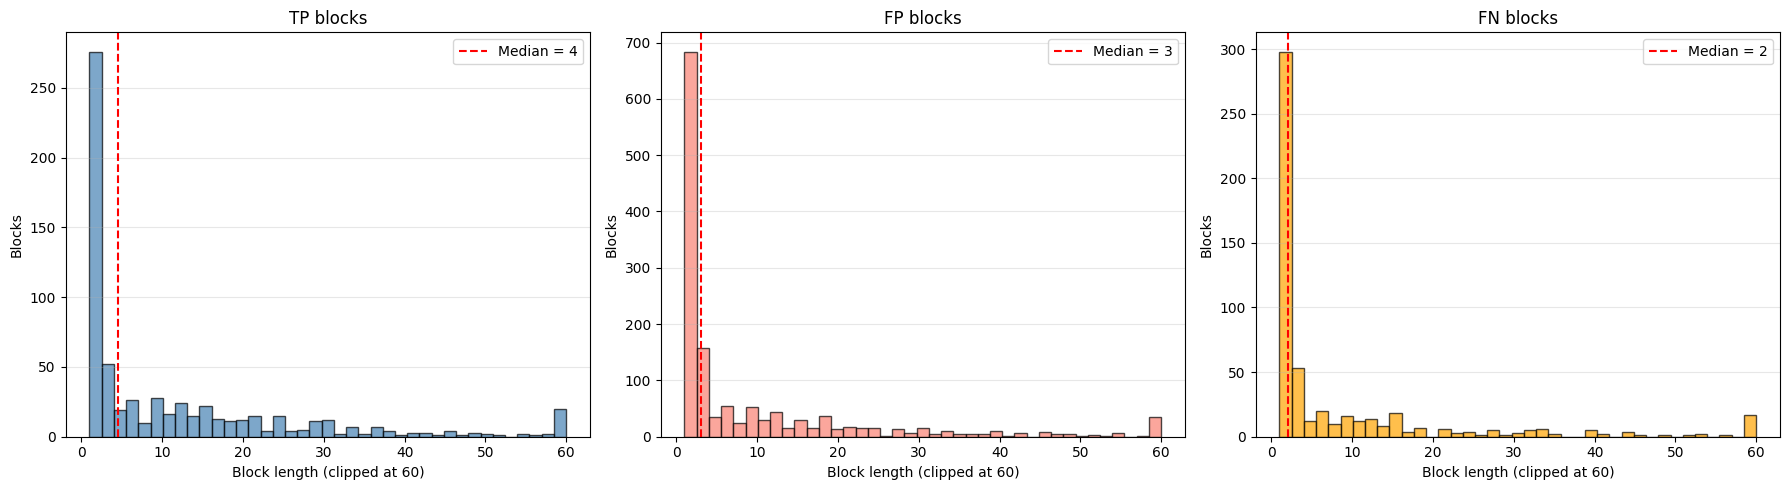

In [ ]:
# Cell 38
def block_lengths(df, label):
    lengths = []
    for _, grp in df.groupby('disprot_id'):
        grp     = grp.sort_values('pos')
        pos_arr = grp['pos'].values
        cm_arr  = grp['confusion_matrix'].values
        run = 0
        for i in range(len(cm_arr)):
            if cm_arr[i] == label:
                run = run + 1 if (i>0 and cm_arr[i-1]==label and pos_arr[i]-pos_arr[i-1]==1) else 1
            else:
                if run > 0:
                    lengths.append(run); run = 0
        if run > 0:
            lengths.append(run)
    return np.array(lengths)

tp_bl, fp_bl, fn_bl = block_lengths(df_cm,'TP'), block_lengths(df_cm,'FP'), block_lengths(df_cm,'FN')
clip_at = 60
bins    = np.linspace(1, clip_at, 40)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (blocks, label, color) in zip(axes, [
        (tp_bl,'TP blocks','steelblue'),(fp_bl,'FP blocks','salmon'),(fn_bl,'FN blocks','orange')]):
    ax.hist(np.clip(blocks, 1, clip_at), bins=bins, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(np.median(blocks), color='red', linestyle='--',
               label=f'Median = {np.median(blocks):.0f}')
    ax.set(xlabel='Block length (clipped at 60)', ylabel='Blocks', title=label)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); 
_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "contiguous_block_lengths.png"), dpi=150, bbox_inches="tight")
plt.show()


## 14 · LIPNet vs AlphaFold-Disorder — accordo residuo per residuo

Per ogni residuo IDR (ref_seq ∈ {0,1}) classifica l'accordo tra i due predittori:
- **Both** — LIPNet=1 e AF=1: entrambi predicono binding
- **LIPNet only** — solo LIPNet predice binding
- **AF only** — solo AlphaFold predice binding
- **Neither** — nessuno predice binding

Il pannello 2 mostra la precisione di ciascuna categoria (% ref=1), motivando l'ensemble.


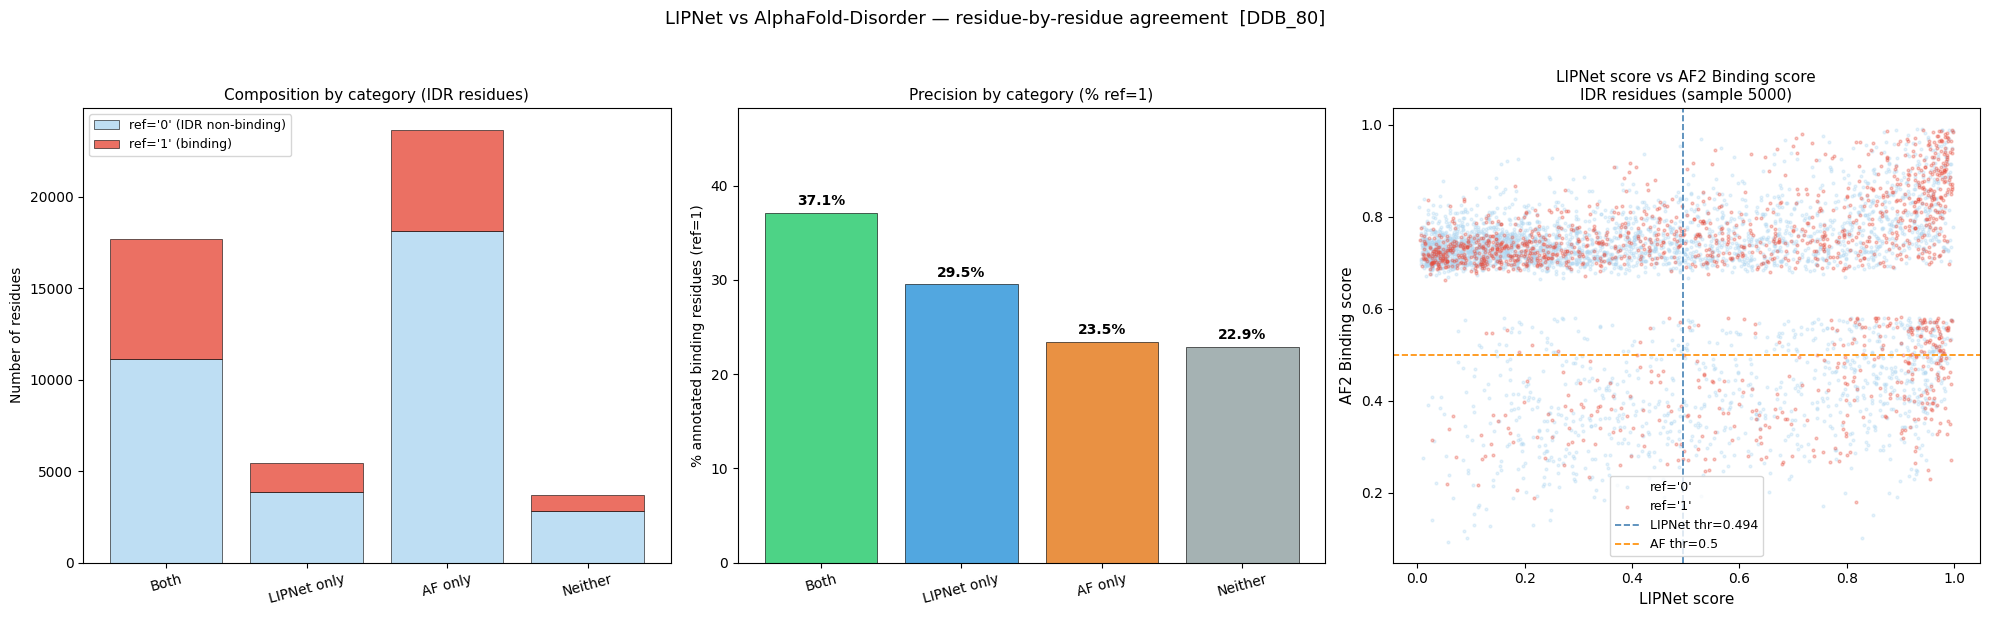


Category       | n residues |  % ref=1 |   % of IDR
----------------------------------------------------
Both           |     17,678 |    37.1% |      35.0%
LIPNet only    |      5,467 |    29.5% |      10.8%
AF only        |     23,677 |    23.5% |      46.9%
Neither        |      3,700 |    22.9% |       7.3%

AF threshold = 0.5 (default CAID)


In [ ]:
# Cell 39 - Graf. 22
# LIPNet vs AlphaFold-Disorder: confronto residuo per residuo su IDR.
# Mostra accordo/disaccordo tra i due predittori e la precisione di ogni categoria.

AF_BINDING_THR = 0.5  # threshold default CAID per AlphaFold binding

idr_df = merged_lip_af[merged_lip_af['ref_seq'].isin(['0', '1'])].copy()
idr_df['af_pred'] = (idr_df['binding'] >= AF_BINDING_THR).astype(int)

labels_agr = ['Both', 'LIPNet only', 'AF only', 'Neither']
idr_df['agreement'] = np.select(
    [
        (idr_df['lipnet_pred'] == 1) & (idr_df['af_pred'] == 1),
        (idr_df['lipnet_pred'] == 1) & (idr_df['af_pred'] == 0),
        (idr_df['lipnet_pred'] == 0) & (idr_df['af_pred'] == 1),
        (idr_df['lipnet_pred'] == 0) & (idr_df['af_pred'] == 0),
    ],
    labels_agr,
    default=''
)

counts   = (idr_df.groupby(['agreement', 'ref_seq']).size()
            .unstack(fill_value=0).reindex(labels_agr))
pos_frac = (idr_df.groupby('agreement')
            .apply(lambda x: (x['ref_seq'] == '1').mean())
            .reindex(labels_agr))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Pannello 1: stacked bar — composizione ref per categoria
bottom = np.zeros(len(labels_agr))
for ref_val, color, lbl in [('0', '#AED6F1', "ref='0' (IDR non-binding)"),
                             ('1', '#E74C3C', "ref='1' (binding)")]:
    vals = counts[ref_val].values if ref_val in counts.columns else np.zeros(len(labels_agr))
    axes[0].bar(labels_agr, vals, bottom=bottom, color=color,
                label=lbl, alpha=0.8, edgecolor='black', lw=0.5)
    bottom += vals
axes[0].set_title('Composition by category (IDR residues)', fontsize=11)
axes[0].set_ylabel('Number of residues')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# Pannello 2: precisione per categoria (% ref='1')
bar_colors = ['#2ECC71', '#3498DB', '#E67E22', '#95A5A6']
bars = axes[1].bar(labels_agr, pos_frac.values * 100,
                   color=bar_colors, alpha=0.85, edgecolor='black', lw=0.5)
axes[1].set_title('Precision by category (% ref=1)', fontsize=11)
axes[1].set_ylabel('% annotated binding residues (ref=1)')
ymax = max(pos_frac.max() * 130, 10)
axes[1].set_ylim(0, min(100, ymax))
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, pos_frac.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v * 100 + 0.5,
                 f'{v*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pannello 3: scatter LIPNet score vs AF binding score (sample 5000)
sample = idr_df.sample(min(5000, len(idr_df)), random_state=42)
for ref_val, color, lbl in [('0', '#AED6F1', "ref='0'"), ('1', '#E74C3C', "ref='1'")]:
    sub = sample[sample['ref_seq'] == ref_val]
    axes[2].scatter(sub['lipnet_score'], sub['binding'],
                    c=color, alpha=0.3, s=4, label=lbl)
axes[2].axvline(0.494, color='steelblue', linestyle='--', lw=1.2, label='LIPNet thr=0.494')
axes[2].axhline(AF_BINDING_THR, color='darkorange', linestyle='--', lw=1.2,
                label=f'AF thr={AF_BINDING_THR}')
axes[2].set_xlabel('LIPNet score', fontsize=11)
axes[2].set_ylabel('AF2 Binding score', fontsize=11)
axes[2].set_title(f'LIPNet score vs AF2 Binding score\nIDR residues (sample 5000)', fontsize=11)
axes[2].legend(fontsize=9)

fig.suptitle(
    f'LIPNet vs AlphaFold-Disorder \u2014 residue-by-residue agreement  [{cfg["label"]}]',
    fontsize=13, y=1.02
)
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "lipnet_vs_alphafold_agreement.png"), dpi=150, bbox_inches="tight")
plt.show()

# Tabella riassuntiva
tot = len(idr_df)
print(f"\n{'Category':<14} | {'n residues':>10} | {'% ref=1':>8} | {'% of IDR':>10}")
print("-" * 52)
for lbl in labels_agr:
    sub = idr_df[idr_df['agreement'] == lbl]
    n   = len(sub)
    p1  = (sub['ref_seq'] == '1').mean() * 100
    pt  = n / tot * 100
    print(f"{lbl:<14} | {n:>10,} | {p1:>7.1f}% | {pt:>9.1f}%")
print(f"\nAF threshold = {AF_BINDING_THR} (default CAID)")

Method                      AUCROC    AUCPR
---------------------------------------------
LIPNet puro                  0.597    0.394
AlphaFold puro               0.536    0.348
Stack prodotto               0.596    0.394
Stack media                  0.595    0.395
Weighted stack 0.7/0.3       0.599    0.399
Stack max                    0.582    0.387

Optimal LIPNet weight: 0.76, AF: 0.24
Optimal weighted stack AUCROC: 0.599


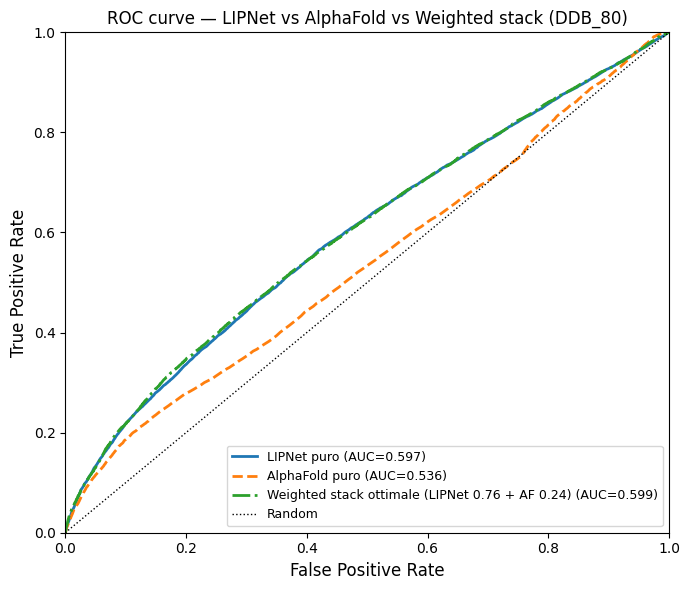

Saved: ..\data\processed\figures\DDB_80\DDB_80_graf_stacking_roc.png


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------------------------
# Step 1 — Score combinati
# ---------------------------------------------------------------------------
df_eval = merged_lip_af[merged_lip_af['ref_seq'].isin(['0', '1'])].copy()
df_eval['ref_binary'] = (df_eval['ref_seq'] == '1').astype(int)

df_eval['stack_product']  = df_eval['lipnet_score'] * df_eval['binding']
df_eval['stack_mean']     = (df_eval['lipnet_score'] + df_eval['binding']) / 2
df_eval['stack_weighted'] = 0.7 * df_eval['lipnet_score'] + 0.3 * df_eval['binding']
df_eval['stack_max']      = df_eval[['lipnet_score', 'binding']].max(axis=1)

# ---------------------------------------------------------------------------
# Step 2 — AUCROC e AUCPR per ogni score
# ---------------------------------------------------------------------------
y_true = df_eval['ref_binary']

scores = {
    'LIPNet puro':          df_eval['lipnet_score'],
    'AlphaFold puro':       df_eval['binding'],
    'Stack prodotto':       df_eval['stack_product'],
    'Stack media':          df_eval['stack_mean'],
    'Weighted stack 0.7/0.3': df_eval['stack_weighted'],
    'Stack max':            df_eval['stack_max'],
}

print(f"{'Method':<25} {'AUCROC':>8} {'AUCPR':>8}")
print('-' * 45)
for name, score in scores.items():
    auc = roc_auc_score(y_true, score)
    pr  = average_precision_score(y_true, score)
    print(f"{name:<25} {auc:>8.3f} {pr:>8.3f}")

# ---------------------------------------------------------------------------
# Step 3 — Peso ottimale per lo stack pesato
# ---------------------------------------------------------------------------
best_auc, best_w = 0, 0
for w in np.linspace(0, 1, 101):
    score_w = w * df_eval['lipnet_score'] + (1 - w) * df_eval['binding']
    auc_w = roc_auc_score(y_true, score_w)
    if auc_w > best_auc:
        best_auc, best_w = auc_w, w

print(f"\nOptimal LIPNet weight: {best_w:.2f}, AF: {1 - best_w:.2f}")
print(f"Optimal weighted stack AUCROC: {best_auc:.3f}")

# ---------------------------------------------------------------------------
# Step 4 — Plot ROC comparativa
# ---------------------------------------------------------------------------
score_best = best_w * df_eval['lipnet_score'] + (1 - best_w) * df_eval['binding']

fig, ax = plt.subplots(figsize=(7, 6))

for label, sc, ls in [
    ('LIPNet puro',                          df_eval['lipnet_score'], '-'),
    ('AlphaFold puro',                       df_eval['binding'],      '--'),
    (f'Weighted stack ottimale (LIPNet {best_w:.2f} + AF {1-best_w:.2f})',
                                             score_best,              '-.'),
]:
    fpr, tpr, _ = roc_curve(y_true, sc)
    auc_val = roc_auc_score(y_true, sc)
    ax.plot(fpr, tpr, linestyle=ls, lw=2, label=f'{label} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC curve — LIPNet vs AlphaFold vs Weighted stack (DDB_80)', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()

out_dir  = r'..\data\processed\figures\DDB_80'
out_path = os.path.join(out_dir, 'DDB_80_graf_stacking_roc.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")


In [ ]:
!pip install nbconvert
!jupyter nbconvert --to html --no-input DDB_80_maggio.ipynb

error: uv trampoline failed to canonicalize script path
error: uv trampoline failed to canonicalize script path


In [ ]:
!cd ..\notebooks
!jupyter-nbconvert --to html --no-input DDB_80_maggio.ipynb

[NbConvertApp] Converting notebook DDB_80_maggio.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 33 image(s).
[NbConvertApp] Writing 3753005 bytes to DDB_80_maggio.html


In [ ]:
print(merged_lip_af['ref_seq'].value_counts())
print(merged_lip_af['lipnet_pred'].value_counts())
print(merged_lip_af['confusion_matrix'].value_counts())


ref_seq
-    114974
0     35946
1     14576
Name: count, dtype: int64
lipnet_pred
0    275873
1    205296
Name: count, dtype: int64
confusion_matrix
TN    20977
FP    14969
TP     8176
FN     6400
Name: count, dtype: int64


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CLASS IMBALANCE ANALYSIS — REFERENCE DATASET vs LIPNet
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import pandas as pd
from pathlib import Path

print("="*90)
print("CLASS IMBALANCE ANALYSIS")
print("="*90)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1. REFERENCE DATASET (DDB_80) — PER-REGION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "="*90)
print("1. REFERENCE DATASET (DDB_80) — PER-REGION (contiguous stretches)")
print("="*90)

regions_data = []
for idx, ref_entry in ACTIVE_REF.items():
    disprot_id = ref_entry['disprot_id']
    ref_seq = ref_entry['ref_sequence']  # string: '0', '1', '-'
    
    # Extract contiguous blocks of '0' and '1'
    i = 0
    while i < len(ref_seq):
        if ref_seq[i] in ('0', '1'):
            char = ref_seq[i]
            start = i
            while i < len(ref_seq) and ref_seq[i] == char:
                i += 1
            end = i - 1
            region_len = end - start + 1
            
            regions_data.append({
                'disprot_id': disprot_id,
                'label': 'BINDING' if char == '1' else 'NON-BINDING',
                'length': region_len,
            })
        else:
            i += 1

regions_df = pd.DataFrame(regions_data)

n_binding_regions = len(regions_df[regions_df['label'] == 'BINDING'])
n_nonbinding_regions = len(regions_df[regions_df['label'] == 'NON-BINDING'])
total_regions = n_binding_regions + n_nonbinding_regions

pct_binding_reg = (n_binding_regions / total_regions * 100) if total_regions > 0 else 0
pct_nonbinding_reg = (n_nonbinding_regions / total_regions * 100) if total_regions > 0 else 0

print(f"\nAnnotated regions (contiguous stretches of '0' or '1'):")
print(f"  Binding regions:     {n_binding_regions:7d}  ({pct_binding_reg:5.1f}%)")
print(f"  Non-binding regions: {n_nonbinding_regions:7d}  ({pct_nonbinding_reg:5.1f}%)")
print(f"  -" * 39)
print(f"  TOTALE:              {total_regions:7d}  (100.0%)")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2. REFERENCE DATASET (DDB_80) — PER-RESIDUE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "="*90)
print("2. REFERENCE DATASET (DDB_80) — PER-RESIDUE (individual amino acids)")
print("="*90)

residues_data = []
for idx, ref_entry in ACTIVE_REF.items():
    ref_seq = ref_entry['ref_sequence']
    for pos, label in enumerate(ref_seq):
        if label in ('0', '1'):  # exclude '-' (outside IDR)
            residues_data.append({
                'disprot_id': ref_entry['disprot_id'],
                'position': pos + 1,
                'label': 'BINDING' if label == '1' else 'NON-BINDING',
            })

residues_ref_df = pd.DataFrame(residues_data)

n_binding_res = len(residues_ref_df[residues_ref_df['label'] == 'BINDING'])
n_nonbinding_res = len(residues_ref_df[residues_ref_df['label'] == 'NON-BINDING'])
total_idr_res = n_binding_res + n_nonbinding_res

pct_binding_res = (n_binding_res / total_idr_res * 100) if total_idr_res > 0 else 0
pct_nonbinding_res = (n_nonbinding_res / total_idr_res * 100) if total_idr_res > 0 else 0

print(f"\nAnnotated residues (over {len(ACTIVE_REF)} proteins):")
print(f"  Binding residues:     {n_binding_res:7d}  ({pct_binding_res:5.1f}%)")
print(f"  Non-binding residues: {n_nonbinding_res:7d}  ({pct_nonbinding_res:5.1f}%)")
print(f"  -" * 39)
print(f"  TOTALE IDR:           {total_idr_res:7d}  (100.0%)")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3. LIPNET DATASET — PER-RESIDUE ANALYSIS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "="*90)
print("3. LIPNET DATASET — PER-RESIDUO (all 1107 DisProt proteins)")
print("="*90)

# Total residues in LIPNet predictions
n_total_lipnet_res = len(lipnet_pred_df)
n_unique_lipnet_prots = lipnet_pred_df['disprot_id'].nunique()

print(f"\nLIPNet predictions (file: LIPNet.caid):")
print(f"  Total unique proteins: {n_unique_lipnet_prots:7d}")
print(f"  Total residues:        {n_total_lipnet_res:7d}")

# Training set count
training_path = Path(r'..\data\raw\training_ids.txt')
if training_path.exists():
    training_ids_raw = set(
        line.strip().replace('_0', '')
        for line in training_path.read_text().strip().split('\n')
        if line.strip()
    )
    n_training_proteins = len(training_ids_raw)
    print(f"\n  Training set (from training_ids.txt):")
    print(f"    * Unique UniProt accessions: {n_training_proteins:7d}")
else:
    n_training_proteins = 0

# Count training residues
training_res_count = 0
test_res_count = 0
test_proteins = []

for disprot_id in lipnet_pred_df['disprot_id'].unique():
    prot_data = next(
        (p for p in filtered_proteins_lipnet.values() if p['disprot_id'] == disprot_id),
        None
    )
    if prot_data:
        subset_len = len(lipnet_pred_df[lipnet_pred_df['disprot_id'] == disprot_id])
        if prot_data['acc'] in training_ids_raw:
            training_res_count += subset_len
        else:
            test_res_count += subset_len
            test_proteins.append(disprot_id)

n_test_proteins = len(test_proteins)

print(f"    * Residues in training: {training_res_count:7d}")
print(f"\n  Test/validation set (non-training proteins):")
print(f"    * Unique proteins: {n_test_proteins:7d}")
print(f"    * Residues: {test_res_count:7d}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4. TABELLA RIEPILOGATIVA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "="*90)
print("4. TABELLA RIEPILOGATIVA — CONFRONTO PER-RESIDUO")
print("="*90)

summary_table = pd.DataFrame({
    'DATASET': [
        'Reference (DDB_80)',
        'LIPNet Training set',
        'LIPNet Test/Validation set',
    ],
    'POSITIVI': [
        f'{n_binding_res:,}',
        'N/A (no labels)',
        'N/A (no labels)',
    ],
    'NEGATIVI': [
        f'{n_nonbinding_res:,}',
        'N/A (no labels)',
        'N/A (no labels)',
    ],
    'TOTALE IDR': [
        f'{total_idr_res:,}',
        f'{training_res_count:,}',
        f'{test_res_count:,}',
    ],
    '% POS': [
        f'{pct_binding_res:.1f}%',
        '—',
        '—',
    ],
    'N. PROTEINS': [
        f'{len(ACTIVE_REF):,}',
        f'{n_training_proteins:,}',
        f'{n_test_proteins:,}',
    ]
})

print("\n" + summary_table.to_string(index=False))

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 5. INFORMAZIONI CRITICHE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "="*90)
print("5. DEFINIZIONI ESATTE E NOTE CRITICHE")
print("="*90)

print(f"""
REFERENCE DATASET (DDB_80)
- Proteome: 268 DisProt proteins
- After filters:
    * Exclude LIPNet training set (2969 proteins)
    * Exclude proteins missing in AlphaFold (111 proteins)
    * Quality filter: remove proteins with >=80% binding residues

- Definizione di POSITIVO ('1'):
    Un residuo e' marcato '1' se rientra in una regione annotata in DisProt
    il cui term_id appartiene a D_O_D_D_Binding, cioe':
    > binding (GO:0005515) — protein binding classico
    > disorder_to_order — transizioni da disordine a ordine durante binding
    > disorder_to_disorder — interazioni fuzzy/transient (es. nucleoporine)

- Definizione di NEGATIVO ('0'):
    Un residuo e' marcato '0' se e' in una regione IDR annotata ma NOT in
    D_O_D_D_Binding (es. display sites, altri tipi di disordine annotati)

- Algoritmo (build_reference):
    Pass 1: mark ALL IDR regions as '0'
    Pass 2: overwrite with '1' the D_O_D_D_Binding regions
    Effetto: il binding vince sugli overlap

- Excluded: residues marked '-' (outside IDR, outside any annotated region)

LIPNET DATASET
- File: LIPNet.caid (non etichettato con label 0/1)
- Proteome: 1107 DisProt proteins
- Contiene: Score per residuo (0-1)

- Subdivisioni:
    * Training set: ~2969 accession UniProt (caricati da training_ids.txt)
    * Test set: ~{n_test_proteins} non-training proteins
    * Includes TE440 (test set pubblico — threshold 0.494 ottimale)
    * Includes other DisProt proteins

- NOTA CRITICA:
    * TE440 e CAID Binding NON sono esplicitamente etichettati nel progetto
    * TE440 e' il test set su cui e' stato calibrato il threshold 0.494 nel paper LIPNet
    * CAID Binding e' il reference benchmark del progetto (= DDB_80 in questo caso)
    * Senza label nel file: non possiamo calcolare positivi/negativi per training/test
    * Il file LIPNet.caid contiene solo score, non ground truth
""")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 6. SALVATAGGIO
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "="*90)
print("6. FILE ESPORTATI")
print("="*90)

out_dir = Path(r'..\data\processed')

# Save regions
regions_export = out_dir / 'reference_regions_ddb80.csv'
regions_df.to_csv(regions_export, index=False)
print(f"OK Reference regions per-class: {regions_export}")

# Save residues
residues_export = out_dir / 'reference_residues_ddb80.csv'
residues_ref_df.to_csv(residues_export, index=False)
print(f"OK Reference residues per-class: {residues_export}")

# Salva summary
summary_export = out_dir / 'CLASS_IMBALANCE_SUMMARY.txt'
summary_text = f"""CLASS IMBALANCE ANALYSIS — SUMMARY

1. REFERENCE DATASET (DDB_80) — 268 PROTEINS

   PER-REGIONE (contiguous stretches of '0' or '1'):
   
   Binding regions:     {n_binding_regions:7d}  ({pct_binding_reg:5.1f}%)
   Non-binding regions: {n_nonbinding_regions:7d}  ({pct_nonbinding_reg:5.1f}%)
   ─────────────────────────────────
   TOTALE:              {total_regions:7d}  (100.0%)

   PER-RESIDUO (individual amino acids in IDR):
   
   Binding residues:     {n_binding_res:7d}  ({pct_binding_res:5.1f}%)
   Non-binding residues: {n_nonbinding_res:7d}  ({pct_nonbinding_res:5.1f}%)
   ─────────────────────────────────
   TOTALE IDR:           {total_idr_res:7d}  (100.0%)

   Definizione di "POSITIVO" nel reference:
   Un residuo e' marcato '1' se appartiene a una regione DisProt annotata
   con term_id in D_O_D_D_Binding:
   - GO:0005515 (protein binding)
   - disorder_to_order transitions
   - disorder_to_disorder interactions (fuzzy/transient)
   
   Pass 2 dell'algoritmo: il binding term sovrascrive il generico IDR
   Esclusioni: '-' residues (fuori IDR) non contano

2. LIPNET DATASET — RESIDUE STATISTICS

   File: LIPNet.caid (score per-residuo, no labels)
   
   All 1107 DisProt proteins:
   - Total residues: {n_total_lipnet_res:,}
   - Training proteins: ~{n_training_proteins:,} accession UniProt
   - Training residues: ~{training_res_count:,}
   - Test/validation residues: ~{test_res_count:,}
   
   NOTA CRITICA:
   - LIPNet.caid contiene solo score, non ground truth labels
   - Non e' possibile calcolare positivi/negativi per LIPNet
   - TE440 test set non e' esplicitamente etichettato nel progetto
   - TE440 e' il dataset su cui e' stato calibrato threshold 0.494 nel paper LIPNet
   - CAID Binding = DDB_80 reference (questo progetto)

3. CONFRONTO PER-RESIDUO (UNITA' COERENTE)

   Dataset                          | Positivi    | Negativi    | % Pos    | N. Proteins
   ─────────────────────────────────┼─────────────┼─────────────┼──────────┼─────────────
   Reference (DDB_80)               | {n_binding_res:>7,}     | {n_nonbinding_res:>7,}     | {pct_binding_res:>5.1f}%   | {len(ACTIVE_REF):>5,}
   LIPNet Training                  | N/A         | N/A         | —        | {n_training_proteins:>5,}
   LIPNet Test/Validation           | N/A         | N/A         | —        | {n_test_proteins:>5,}
"""

summary_export.write_text(summary_text, encoding='utf-8')
print(f"OK Summary text: {summary_export}")

print("\n✓ Analysis complete.")


CLASS IMBALANCE ANALYSIS

1. REFERENCE DATASET (DDB_80) — PER-REGION (contiguous stretches)

Annotated regions (contiguous stretches of '0' or '1'):
  Binding regions:         330  ( 35.9%)
  Non-binding regions:     588  ( 64.1%)
  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -
  TOTALE:                  918  (100.0%)

2. REFERENCE DATASET (DDB_80) — PER-RESIDUE (individual amino acids)

Annotated residues (over 268 proteins):
  Binding residues:       14576  ( 28.9%)
  Non-binding residues:   35946  ( 71.1%)
  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -
  TOTALE IDR:             50522  (100.0%)

3. LIPNET DATASET — PER-RESIDUO (all 1107 DisProt proteins)

LIPNet predictions (file: LIPNet.caid):
  Total unique proteins:    1107
  Total residues:         619846

  Training set (from training_ids.txt):
    * Unique UniProt accessions:    2969
    *

## 15 · 4 CAID configurations
Legge direttamente i CSV di output CAID per tutte le configurazioni
e produce tabella + grafici comparativi indipendentemente da `ACTIVE`.

         N prot  LIP AUCROC  LIP AUCPR  LIP F1@0.5  LIP F1@opt  LIP thr opt  LIP med AUC  AF AUCROC  AF AUCPR
Config                                                                                                       
DOB_80      268       0.596      0.392       0.429       0.446        0.116        0.436      0.534     0.345
DOB_100     308       0.572      0.436       0.461       0.525        0.019        0.441      0.507     0.390
DDB_80      268       0.597      0.394       0.432       0.448        0.195        0.436      0.536     0.348
DDB_100     308       0.573      0.438       0.463       0.527        0.019        0.441      0.509     0.394


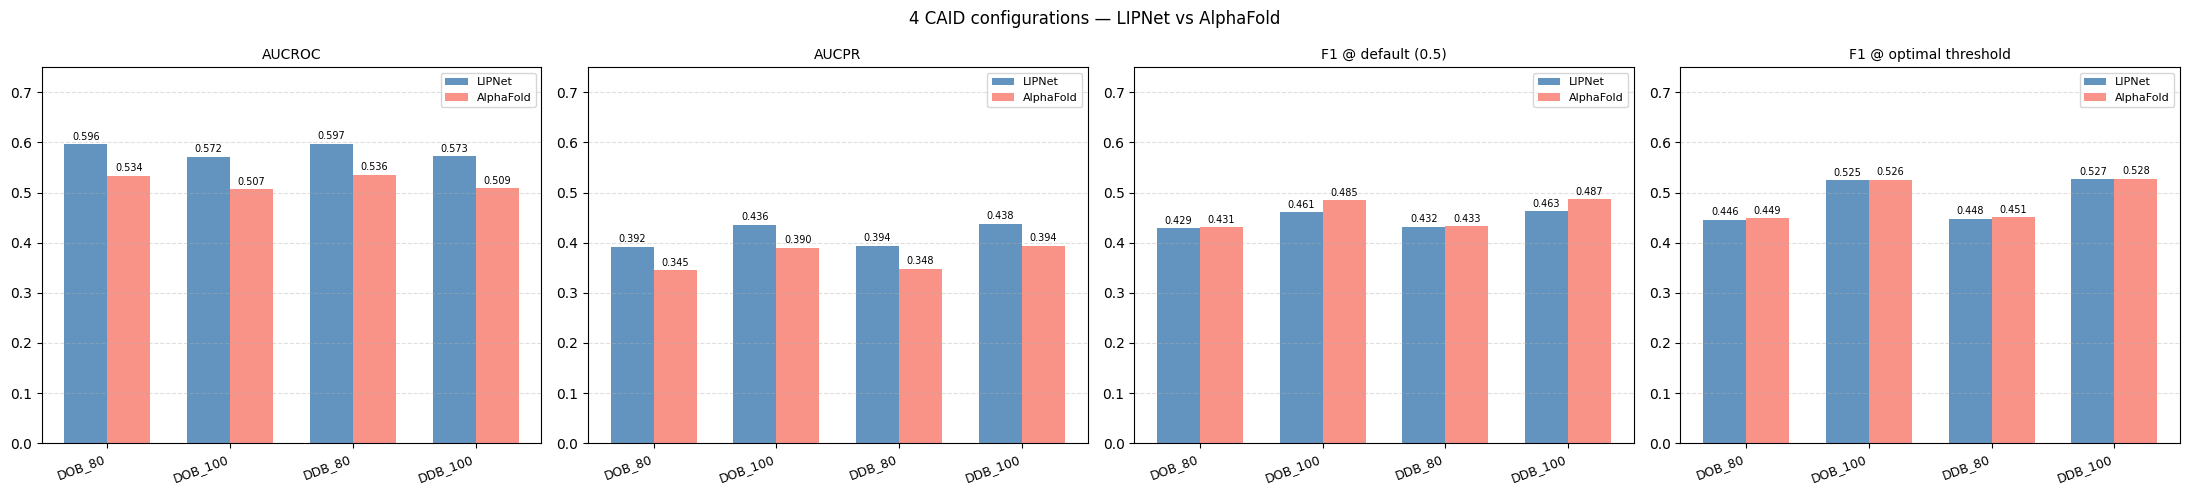

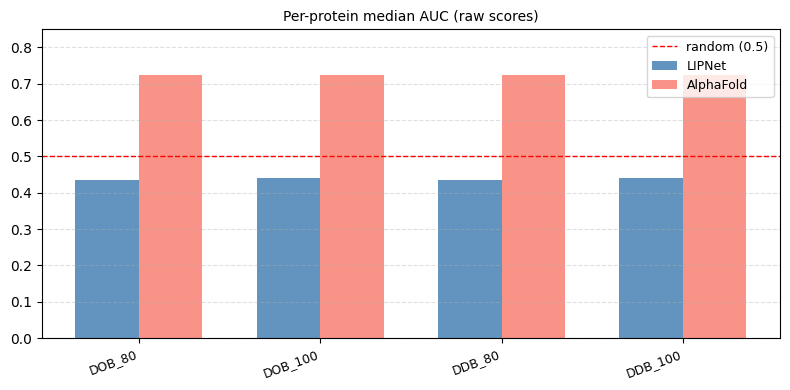

In [ ]:
# Cell 40 - 4 CAID configurations
# Legge i CSV di output CAID per tutte le configurazioni e produce
# tabella comparativa e grafici. Indipendente da ACTIVE.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

CONFIGS_ALL = {
    "DOB_80":  {"dir": os.path.join("..","data","processed","Output_CAID_DOB80"),  "label": "D_O_Binding80"},
    "DOB_100": {"dir": os.path.join("..","data","processed","Output_CAID_DOB100"), "label": "D_O_Binding100"},
    "DDB_80":  {"dir": os.path.join("..","data","processed","Output_CAID_DDB80"),  "label": "DDB_80"},
    "DDB_100": {"dir": os.path.join("..","data","processed","Output_CAID_DDB100"), "label": "DDB_100"},
}

rows = []
for cfg_name, c in CONFIGS_ALL.items():
    d, lbl = c['dir'], c['label']
    def_m = pd.read_csv(os.path.join(d, f'{lbl}.analysis.all.dataset.default.metrics.csv'), index_col=0)
    f1s_m = pd.read_csv(os.path.join(d, f'{lbl}.analysis.all.dataset.f1s.metrics.csv'),     index_col=0)
    tgt   = pd.read_csv(os.path.join(d, f'{lbl}.analysis.all.target.default.metrics.csv'),  index_col=[0,1])
    raw_l = pd.read_csv(os.path.join(d, 'LIPNet.rawscores.distribution.txt'), header=None)[0]
    raw_a = pd.read_csv(os.path.join(d, 'alphafold_binding.rawscores.distribution.txt'), header=None)[0]
    n_prot = len(tgt.loc['LIPNet'])
    rows.append({
        'Config':          cfg_name,
        'N prot':          n_prot,
        'LIP AUCROC':      float(def_m.loc['LIPNet','aucroc']),
        'LIP AUCPR':       float(def_m.loc['LIPNet','aucpr']),
        'LIP F1@0.5':      float(def_m.loc['LIPNet','f1s']),
        'LIP PPV@0.5':     float(def_m.loc['LIPNet','ppv']),
        'LIP TPR@0.5':     float(def_m.loc['LIPNet','tpr']),
        'LIP F1@opt':      float(f1s_m.loc['LIPNet','f1s']),
        'LIP thr opt':     float(f1s_m.loc['LIPNet','thr']),
        'LIP med AUC':     float(raw_l.median()),
        'AF AUCROC':       float(def_m.loc['alphafold_binding','aucroc']),
        'AF AUCPR':        float(def_m.loc['alphafold_binding','aucpr']),
        'AF F1@0.5':       float(def_m.loc['alphafold_binding','f1s']),
        'AF F1@opt':       float(f1s_m.loc['alphafold_binding','f1s']),
        'AF med AUC':      float(raw_a.median()),
    })

cmp = pd.DataFrame(rows).set_index('Config')
print(cmp[['N prot','LIP AUCROC','LIP AUCPR','LIP F1@0.5','LIP F1@opt',
           'LIP thr opt','LIP med AUC','AF AUCROC','AF AUCPR']].to_string())

# ── Grafico comparativo ─────────────────────────────────────────────────────
metrics_plot = [
    ('LIP AUCROC', 'AF AUCROC', 'AUCROC'),
    ('LIP AUCPR',  'AF AUCPR',  'AUCPR'),
    ('LIP F1@0.5', 'AF F1@0.5', 'F1 @ default (0.5)'),
    ('LIP F1@opt', 'AF F1@opt', 'F1 @ optimal threshold'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=False)
cfgs   = list(cmp.index)
x      = np.arange(len(cfgs))
width  = 0.35

for ax, (lip_col, af_col, title) in zip(axes, metrics_plot):
    b1 = ax.bar(x - width/2, cmp[lip_col], width, label='LIPNet',    color='steelblue', alpha=0.85)
    b2 = ax.bar(x + width/2, cmp[af_col],  width, label='AlphaFold', color='salmon',    alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(cfgs, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 0.75)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7)

fig.suptitle('4 CAID configurations — LIPNet vs AlphaFold', fontsize=12)
plt.tight_layout()

_fig_dir = os.path.join("..",
                        'data','processed','figures','confronto')
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, 'confronto_4_config.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Per-protein median AUC ─────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.bar(x - width/2, cmp['LIP med AUC'], width, label='LIPNet',    color='steelblue', alpha=0.85)
ax2.bar(x + width/2, cmp['AF med AUC'],  width, label='AlphaFold', color='salmon',    alpha=0.85)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='random (0.5)')
ax2.set_xticks(x)
ax2.set_xticklabels(cfgs, rotation=20, ha='right', fontsize=9)
ax2.set_title('Per-protein median AUC (raw scores)', fontsize=10)
ax2.set_ylim(0, 0.85)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
fig2.savefig(os.path.join(_fig_dir, 'confronto_median_auc_per_protein.png'), dpi=150, bbox_inches='tight')
plt.show()


## 16 · Ensemble LIPNet + AlphaFold-Disorder — analisi CIDER

Filtra le predizioni LIPNet ai soli residui che AlphaFold considera disordinati (`disorder_plddt ≥ 0.5` OR `disorder_rsa ≥ 0.5`), estrae le regioni contigue (≥ 5 aa) e confronta il profilo CIDER con REF e LIPNet completo (Graf. 32).

**Ipotesi:** se la divergenza CIDER di Graf. 32 è causata da predizioni in ordered regions, filtrare per disordine dovrebbe avvicinare il profilo CIDER delle predizioni al reference.

In [ ]:
# Cell 41 - Ensemble LIPNet + AlphaFold-Disorder: Three-way CIDER
# Confronta: REF vs LIPNet-pred-completo vs LIPNet-pred-filtrato-per-disordine AF.

from itertools import groupby
from operator import itemgetter
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

AF_PLDDT_THR = 0.688  # official CAID threshold for disorder pLDDT
AF_RSA_THR   = 0.581  # official CAID threshold for disorder RSA

# ── Step 1: ensemble-positive residues ────────────────────────────────────────
# LIPNet pred=1 E AlphaFold considera il residuo disordinato
ensemble_mask = (
    (merged_lip_af["lipnet_pred"] == 1) &
    (
        (merged_lip_af["disorder_plddt"] >= AF_DISORDER_THR) |
        (merged_lip_af["disorder_rsa"]   >= AF_DISORDER_THR)
    )
)
lip_all_mask = (merged_lip_af["lipnet_pred"] == 1)

n_all      = lip_all_mask.sum()
n_ensemble = ensemble_mask.sum()
print(f"Total LIPNet pred=1 residues:          {n_all:,}")
print(f"Ensemble residues (+ AF disorder):      {n_ensemble:,}  ({n_ensemble/n_all*100:.1f}% of LIPNet total)")
print(f"Discarded residues (ordered regions):  {n_all - n_ensemble:,}  ({(n_all-n_ensemble)/n_all*100:.1f}%)")

# ── Step 2: costruisci dizionario sequenze per proteina ───────────────────────
# {disprot_id: full_sequence}
disprot_seq = {v["disprot_id"]: v["sequence"]
               for v in filtered_proteins_lipnet.values()}

# ── Step 3: extract contiguous blocks of ensemble-positive residues ─────────────
ensemble_region_list = []
for disprot_id, grp in merged_lip_af[ensemble_mask].groupby("disprot_id"):
    full_seq = disprot_seq.get(disprot_id)
    if not full_seq:
        continue
    positions = sorted(grp["pos"].values.tolist())
    # raggruppa posizioni consecutive
    for _, g in groupby(enumerate(positions), lambda x: x[1] - x[0]):
        block = [p for _, p in g]
        start, end = block[0], block[-1]
        # estrai sequenza (pos è 1-based)
        seq = full_seq[start - 1: end]
        if len(seq) < 5:
            continue
        ensemble_region_list.append({
            "disprot_id": disprot_id,
            "start":      start,
            "end":        end,
            "sequence":   seq,
            "length":     len(seq),
        })

print(f"\nEnsemble regions extracted (before filtering):  {len(ensemble_region_list)}")

# filtra AA non standard
VALID = set("ACDEFGHIKLMNPQRSTVWY")
valid_regions = [r for r in ensemble_region_list if set(r["sequence"]).issubset(VALID)]
skipped = len(ensemble_region_list) - len(valid_regions)
print(f"Regions discarded (non-standard AA):             {skipped}")
print(f"Valid ensemble regions (>= 5 aa):                {len(valid_regions)}")

# ── Step 4: compute CIDER ─────────────────────────────────────────────────────
# raggruppa in dict {disprot_id: [regions]} come vuole cider.compute_features
ensemble_dict = {}
for r in valid_regions:
    ensemble_dict.setdefault(r["disprot_id"], []).append(r)

df_ensemble_cider = cider.compute_features(valid_regions)
print(f"\nProteins in ensemble:   {df_ensemble_cider['disprot_id'].nunique()}")
print(f"Regions in ensemble:    {len(df_ensemble_cider)}")

# ── Step 5: violin plot a tre vie ─────────────────────────────────────────────
features = ["FCR", "NCPR", "kappa", "Mean_hydropathy",
            "PPII_propensity", "seq_complexity_shannon", "frac_aromatic", "frac_bulky"]
meaning  = [
    "fraction of charged residues",
    "net charge per residue (+/-)",
    "charge spatial patterning",
    "mean hydropathy",
    "PPII helix propensity",
    "sequence complexity",
    "fraction aromatic (F,Y,W)",
    "fraction bulky residues",
]

fig, axes = plt.subplots(4, 2, figsize=(14, 22))

for ax, feat, desc in zip(axes.flatten(), features, meaning):
    dr = ref_cider_DF[feat].dropna().values
    dp = lip_pred_cider_DF[feat].dropna().values
    de = df_ensemble_cider[feat].dropna().values

    if len(de) < 2:
        ax.set_title(f"{feat}\n(too few ensemble regions)")
        continue

    parts = ax.violinplot([dr, dp, de], positions=[1, 2, 3],
                          showmedians=True, showextrema=True)
    colors = ["steelblue", "salmon", "seagreen"]
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color)
        body.set_alpha(0.65)

    # Mann-Whitney REF vs ensemble
    _, p_ens = mannwhitneyu(dr, de, alternative="two-sided")
    # Mann-Whitney REF vs full LIPNet
    _, p_lip = mannwhitneyu(dr, dp, alternative="two-sided")

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([
        f"REF\n(n={len(dr)})",
        f"LIPNet\n(n={len(dp)})",
        f"Ensemble\n(n={len(de)})",
    ], fontsize=8)
    ax.set_title(
        f"{feat} — {desc}\n"
        f"REF vs LIPNet p={p_lip:.2e} | REF vs Ensemble p={p_ens:.2e}",
        fontsize=8,
    )
    ax.set_ylabel(feat, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    f"Three-way CIDER — {cfg['label']}\n"
    "REF (blu) | LIPNet pred completo (rosso) | Ensemble LIPNet+AF-Disorder (verde)",
    fontsize=11,
)
plt.tight_layout()

_fig_dir = os.path.join("..",
                        "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "cider_violin_ensemble.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Step 6: riepilogo mediane ─────────────────────────────────────────────────
summary_rows = []
for feat in features:
    dr = ref_cider_DF[feat].dropna()
    dp = lip_pred_cider_DF[feat].dropna()
    de = df_ensemble_cider[feat].dropna()
    _, p_lip = mannwhitneyu(dr, dp, alternative="two-sided")
    _, p_ens = mannwhitneyu(dr, de, alternative="two-sided")
    # effect size rank-biserial
    def rb(a, b):
        U, _ = mannwhitneyu(a, b, alternative="two-sided")
        return abs(1 - 2 * U / (len(a) * len(b)))
    summary_rows.append({
        "feature":        feat,
        "REF median":     round(float(dr.median()), 4),
        "LIPNet median":  round(float(dp.median()), 4),
        "Ensemble median":round(float(de.median()), 4),
        "p REF-LIPNet":   f"{p_lip:.2e}",
        "p REF-Ensemble": f"{p_ens:.2e}",
        "r REF-LIPNet":   round(rb(dr, dp), 3),
        "r REF-Ensemble": round(rb(dr, de), 3),
    })

df_summary = pd.DataFrame(summary_rows).set_index("feature")
print("\nSummary medians and p-values (REF vs LIPNet vs Ensemble):")
print(df_summary.to_string())


NameError: name 'AF_DISORDER_THR' is not defined

## 17 · Analisi del training set LIPNet

Interroga UniProt (batch GET da 100 accession) per tutte le **2969 proteine** del training set di LIPNet e calcola:
- Distribuzione per **regno** (Eukaryota / Bacteria / Archaea)
- **Top 20 organismi** per numerosità
- **Hub proteins** — proxy: numero di interazioni binarie annotate in UniProt (`cc_interaction`), soglia = top 10%
- **Classificazione funzionale** multi-label via keywords UniProt (kinase, TF, RNA-binding, ubiquitin, …)
- **Localizzazione subcellulare** top 15
- **Annotation score** (1–5; 5 = Swiss-Prot curato)

Output: CSV + 6 PNG in `data/processed/training_analysis/`.

Training proteins (unique): 2969
  Batch 5/30 — totale: 500
  Batch 10/30 — totale: 1000
  Batch 15/30 — totale: 1500
  Batch 20/30 — totale: 2000
  Batch 25/30 — totale: 2500
  Batch 30/30 — totale: 2969
DataFrame: 2969 righe
Unique species: 544

--- Species by kingdom (top 5 per group) ---
  [Archaea]
    Pyrococcus abyssi (strain GE5 / Orsay)                    10  (0.3%)
    Pyrococcus furiosus (strain ATCC 43587 / DSM 3638 / JCM 8422 / Vc1)   10  (0.3%)
    Methanocaldococcus jannaschii (strain ATCC 43067 / DSM 2661 / JAL-1 / JCM 10045 / NBRC 100440)    9  (0.3%)
    Saccharolobus solfataricus (strain ATCC 35092 / DSM 1617 / JCM 11322 / P2)    8  (0.3%)
    Thermococcus kodakarensis (strain ATCC BAA-918 / JCM 12380 / KOD1)    8  (0.3%)
    ... altre 29 specie                                 59  (2.0%)

  [Bacteria]
    Escherichia coli (strain K12)                            118  (4.0%)
    Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)    46  (1.5%)
    Mycolicibacterium 

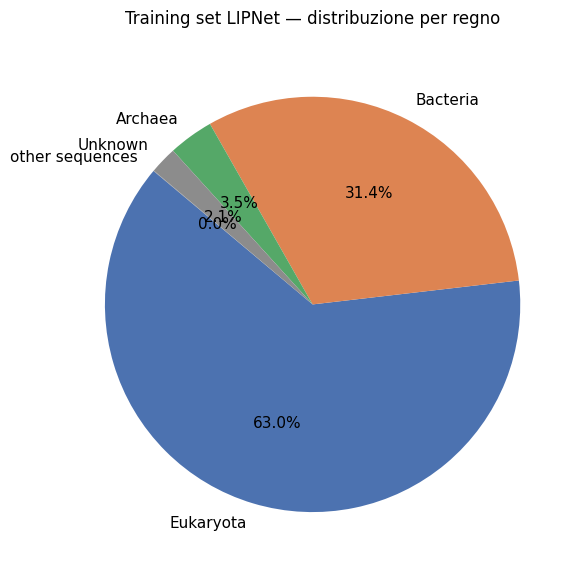

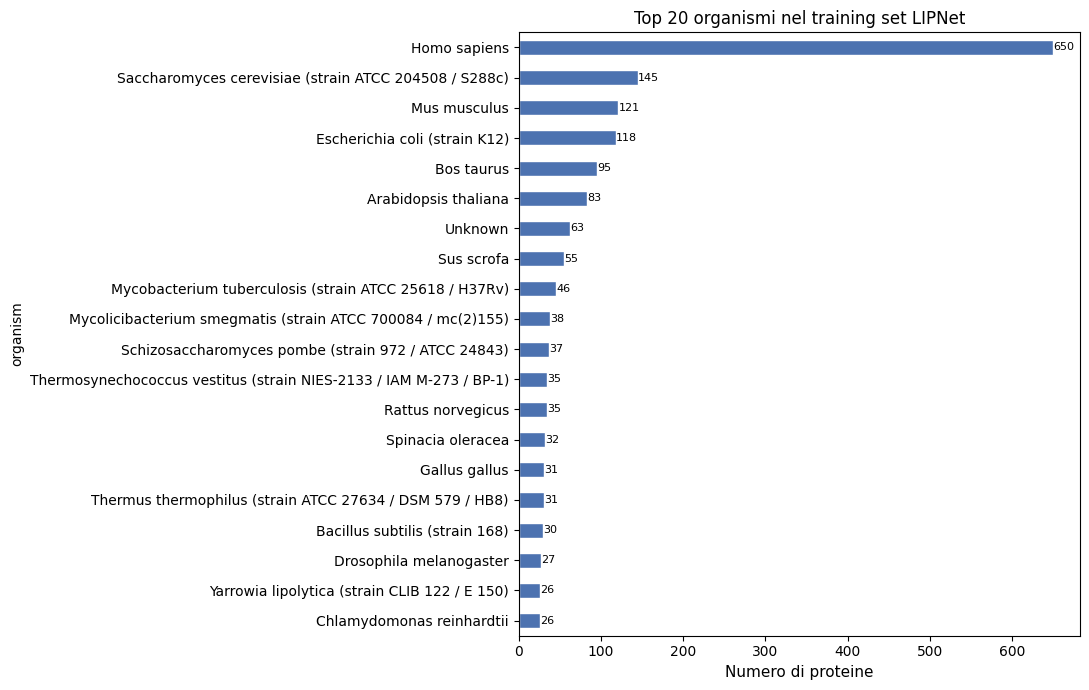

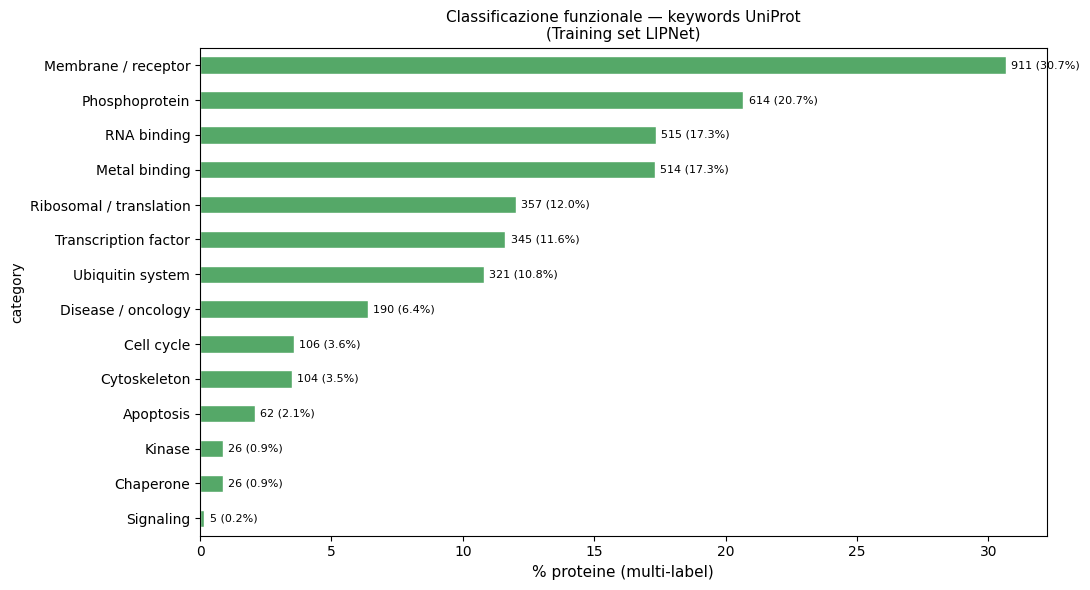

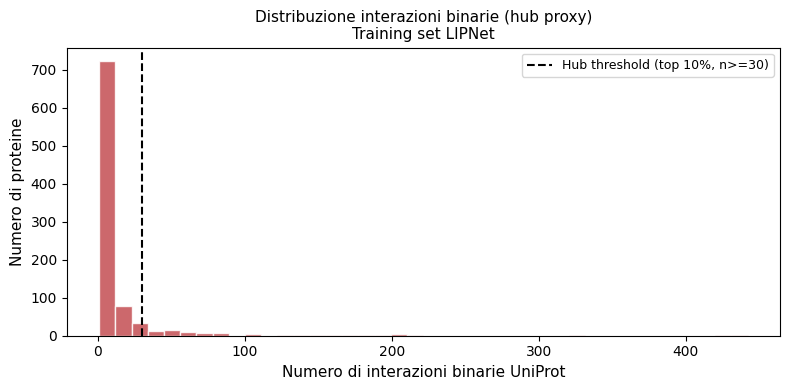

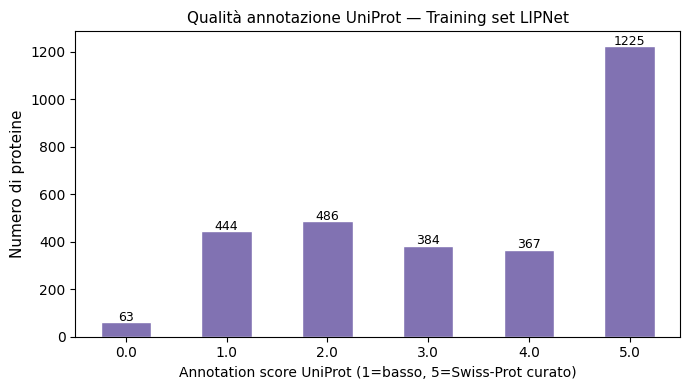

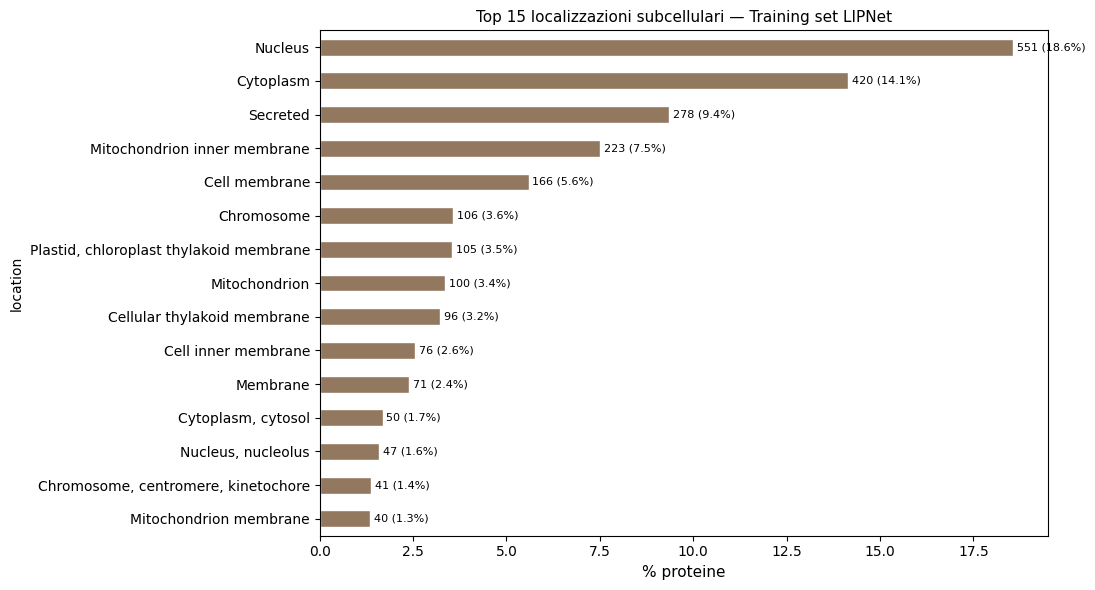

~\AppData\Local\Temp\ipykernel_8376\2258303701.py:297: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


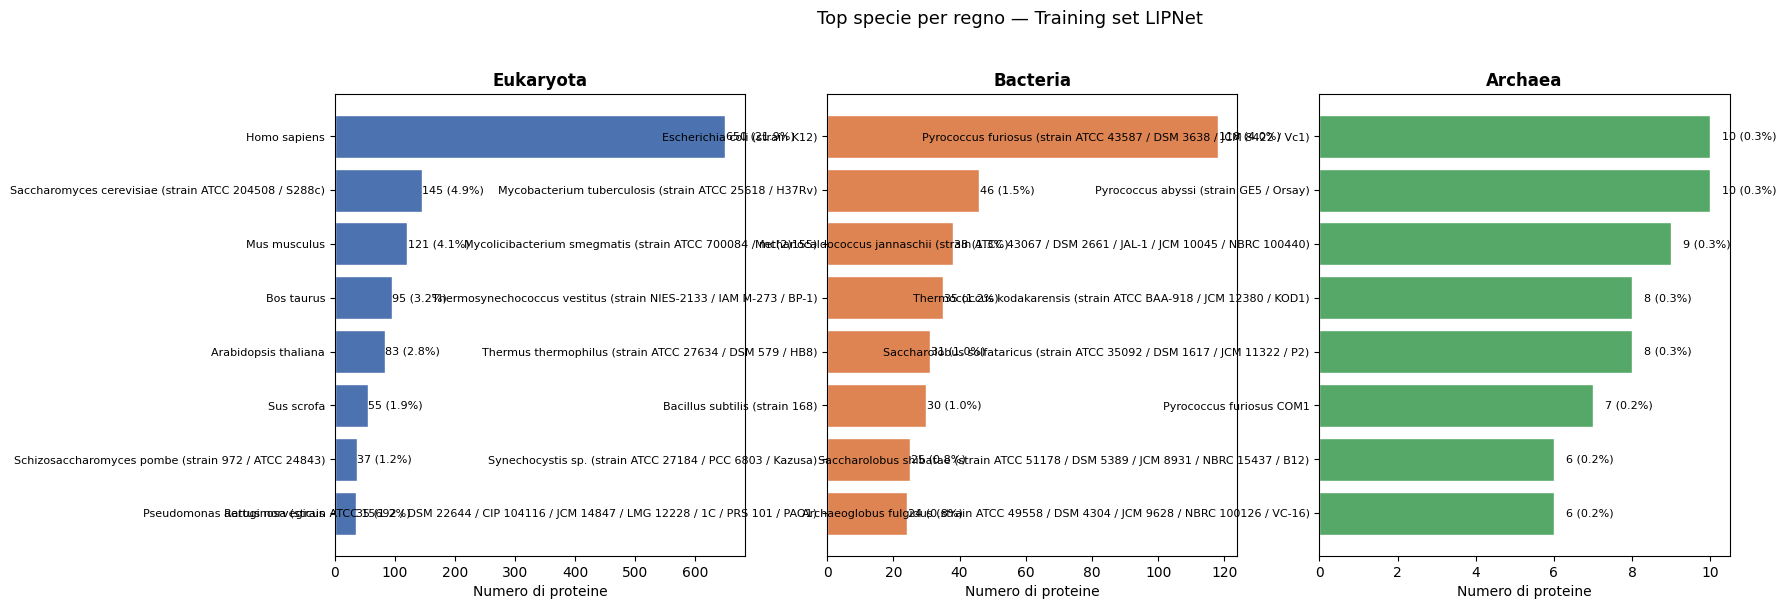


SUMMARY TRAINING SET LIPNET
Proteine uniche:             2969
Record UniProt recuperati:   2969

Distribution by kingdom:
  Eukaryota             1869  (63.0%)
  Bacteria               932  (31.4%)
  Archaea                104  (3.5%)
  Unknown                 63  (2.1%)
  other sequences          1  (0.0%)

Total unique species: 544
Most represented organism: Homo sapiens
  (650 proteine, 21.9%)

Hub (n_interactions>=30): 92 (3.1%)
Median interactions (prot with >0): 4

Annotation score 5 (Swiss-Prot): 1225 (41.3%)

Top 5 functional categories:
  Membrane / receptor              911  (30.7%)
  Phosphoprotein                   614  (20.7%)
  RNA binding                      515  (17.3%)
  Metal binding                    514  (17.3%)
  Ribosomal / translation          357  (12.0%)

Output in: ..\data\processed\training_analysis


In [ ]:
import requests, time, math, os, sys
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------------------------------------------------------------------------
# Percorsi
# ---------------------------------------------------------------------------
BASE     = r'..'
IDS_FILE = os.path.join(BASE, 'data', 'raw', 'training_ids.txt')
OUT_DIR  = os.path.join(BASE, 'data', 'processed', 'training_analysis')
FIG_DIR  = os.path.join(OUT_DIR, 'figures')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# 0 — ID univoci (strip '_0')
# ---------------------------------------------------------------------------
with open(IDS_FILE) as f:
    raw_ids = [l.strip() for l in f if l.strip()]
acc_list = list(dict.fromkeys(x.split('_')[0] for x in raw_ids))
print(f'Training proteins (unique): {len(acc_list)}')

# ---------------------------------------------------------------------------
# 1 — Query UniProt REST (GET /search, batch da 100)
# ---------------------------------------------------------------------------
UNIPROT_URL = 'https://rest.uniprot.org/uniprotkb/search'
FIELDS = 'accession,organism_name,lineage,keyword,cc_interaction,cc_subcellular_location,annotation_score'
BATCH_SIZE, SLEEP_S = 100, 1.0

def query_uniprot_batch(accessions):
    query  = ' OR '.join(f'accession:{a}' for a in accessions)
    r = requests.get(UNIPROT_URL,
                     params={'query': query, 'fields': FIELDS,
                             'format': 'json', 'size': len(accessions)},
                     timeout=90)
    r.raise_for_status()
    return r.json().get('results', [])

uniprot_records = []
n_batches = math.ceil(len(acc_list) / BATCH_SIZE)
for i in range(n_batches):
    batch = acc_list[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
    try:
        recs = query_uniprot_batch(batch)
        uniprot_records.extend(recs)
        if (i+1) % 5 == 0 or i == n_batches-1:
            print(f'  Batch {i+1}/{n_batches} — totale: {len(uniprot_records)}')
    except Exception as e:
        print(f'  Batch {i+1} ERROR: {e}')
    time.sleep(SLEEP_S)

# ---------------------------------------------------------------------------
# 2 — Parsing → DataFrame
# ---------------------------------------------------------------------------
def parse_interactions(comments):
    partners = set()
    for c in comments:
        if c.get('commentType') != 'INTERACTION':
            continue
        for inter in c.get('interactions', []):
            p = inter.get('interactantTwo', {}).get('uniProtKBAccession', '')
            if p:
                partners.add(p)
    return len(partners)

def parse_subloc(comments):
    locs = []
    for c in comments:
        if c.get('commentType') != 'SUBCELLULAR LOCATION':
            continue
        for sl in c.get('subcellularLocations', []):
            v = sl.get('location', {}).get('value', '')
            if v:
                locs.append(v)
    return '; '.join(locs)

rows = []
for rec in uniprot_records:
    acc      = rec.get('primaryAccession', '')
    org_obj  = rec.get('organism', {})
    organism = org_obj.get('scientificName', 'Unknown')
    lineage  = org_obj.get('lineage', [])
    kingdom  = lineage[0] if lineage else 'Unknown'
    phylum   = lineage[1] if len(lineage) > 1 else 'Unknown'
    kw_str   = '; '.join(k.get('name', '') for k in rec.get('keywords', []))
    comments = rec.get('comments', [])
    rows.append({
        'accession':       acc,
        'organism':        organism,
        'kingdom':         kingdom,
        'phylum':          phylum,
        'keywords':        kw_str,
        'n_interactions':  parse_interactions(comments),
        'subloc':          parse_subloc(comments),
        'annotation_score': rec.get('annotationScore', 0.0),
    })

df = pd.DataFrame(rows)
df.to_csv(os.path.join(OUT_DIR, 'training_uniprot_annotations.csv'), index=False)
print(f'DataFrame: {len(df)} rows')

# --- Species: complete distribution ---
species_counts = (df.groupby(['kingdom', 'organism'])
                    .size()
                    .reset_index(name='count')
                    .assign(pct=lambda d: d['count']/len(df)*100)
                    .sort_values(['kingdom','count'], ascending=[True,False]))
species_counts.to_csv(os.path.join(OUT_DIR, 'training_species.csv'), index=False)
print(f'Unique species: {df["organism"].nunique()}')
print()
print('--- Species by kingdom (top 5 per group) ---')
for kingdom, grp in species_counts.groupby('kingdom'):
    print(f'  [{kingdom}]')
    for _, row in grp.head(5).iterrows():
        print(f'    {row["organism"]:<55} {row["count"]:>4}  ({row["pct"]:.1f}%)')
    others = grp.iloc[5:]['count'].sum()
    if others > 0:
        other_pct = others / len(df) * 100
        print(f'    ... other {len(grp)-5} species                               '
              f'{others:>4}  ({other_pct:.1f}%)')
    print()

# ---------------------------------------------------------------------------
# 3 — Hub proteins (top 10% per n_interactions)
# ---------------------------------------------------------------------------
df_inter   = df[df['n_interactions'] > 0]
hub_thr    = df_inter['n_interactions'].quantile(0.90) if not df_inter.empty else 10
df['is_hub'] = df['n_interactions'] >= hub_thr
print(f'Hub threshold (top 10%): {hub_thr:.0f} interazioni')
print(f'Hub: {df["is_hub"].sum()} ({df["is_hub"].mean()*100:.1f}% of total)')
print('Top 10 hubs:')
print(df.nlargest(10, 'n_interactions')
        [['accession','organism','n_interactions']].to_string(index=False))

# ---------------------------------------------------------------------------
# 4 — Classificazione funzionale via keywords
# ---------------------------------------------------------------------------
KEYWORD_CATEGORIES = {
    'Kinase':                  ['kinase'],
    'Transcription factor':    ['transcription regulator','transcription factor',
                                'dna-binding','activator','repressor'],
    'Signaling':               ['signal transduction','g-protein','gtpase',
                                'cell signaling','second messenger'],
    'Ubiquitin system':        ['ubiquitin','e3 ubiquitin','proteasome',
                                'ubl conjugation'],
    'Cell cycle':              ['cell cycle','mitosis','cell division','meiosis'],
    'Apoptosis':               ['apoptosis','programmed cell death'],
    'Chaperone':               ['chaperone','heat shock'],
    'RNA binding':             ['rna-binding','mrna processing','splicing'],
    'Cytoskeleton':            ['cytoskeleton','actin','tubulin','motor protein'],
    'Metal binding':           ['metal-binding','zinc','calcium','iron'],
    'Phosphoprotein':          ['phosphoprotein'],
    'Disease / oncology':      ['disease variant','neurodegeneration',
                                'proto-oncogene','tumor suppressor'],
    'Intrinsically disordered':['intrinsically disordered'],
    'Ribosomal / translation': ['ribosom','translation','trna'],
    'Membrane / receptor':     ['transmembrane','receptor','membrane'],
}

def classify_kw(kw_str, cats):
    kl = kw_str.lower()
    return [c for c, terms in cats.items() if any(t in kl for t in terms)] \
           or ['Other / unclassified']

df['func_categories'] = df['keywords'].apply(lambda k: classify_kw(k, KEYWORD_CATEGORIES))
cat_counts = Counter()
for cats in df['func_categories']:
    cat_counts.update(cats)
df_cats = (pd.DataFrame(cat_counts.items(), columns=['category','count'])
             .assign(pct=lambda d: d['count']/len(df)*100)
             .sort_values('count', ascending=False))
df_cats.to_csv(os.path.join(OUT_DIR, 'training_functional_categories.csv'), index=False)

# localizzazione
subloc_counter = Counter()
for s in df['subloc']:
    for loc in s.split(';'):
        loc = loc.strip()
        if loc:
            subloc_counter[loc] += 1
df_subloc = (pd.DataFrame(subloc_counter.items(), columns=['location','count'])
               .assign(pct=lambda d: d['count']/len(df)*100)
               .sort_values('count', ascending=False))
df_subloc.to_csv(os.path.join(OUT_DIR, 'training_subloc.csv'), index=False)

# ---------------------------------------------------------------------------
# 5 — Figure (6 plot)
# ---------------------------------------------------------------------------
palette = {'Eukaryota':'#4C72B0','Bacteria':'#DD8452',
           'Archaea':'#55A868','Viruses':'#C44E52','Unknown':'#8C8C8C'}
kingdom_counts = df['kingdom'].value_counts()

# Fig 1 — Pie regni
fig1, ax1 = plt.subplots(figsize=(6,6))
ax1.pie(kingdom_counts.values,
        labels=kingdom_counts.index,
        colors=[palette.get(k,'#8C8C8C') for k in kingdom_counts.index],
        autopct='%1.1f%%', startangle=140, textprops={'fontsize':11})
ax1.set_title('Training set LIPNet — distribution by kingdom', fontsize=12, pad=15)
plt.tight_layout()
fig1.savefig(os.path.join(FIG_DIR,'training_kingdom_pie.png'), dpi=150, bbox_inches='tight')
plt.show()

# Fig 2 — Top 20 organismi
org_counts = df['organism'].value_counts().head(20)
fig2, ax2 = plt.subplots(figsize=(11,7))
org_counts.sort_values().plot.barh(ax=ax2, color='#4C72B0', edgecolor='white')
ax2.set_xlabel('Number of proteins', fontsize=11)
ax2.set_title('Top 20 organisms in LIPNet training set', fontsize=12)
for i, v in enumerate(org_counts.sort_values().values):
    ax2.text(v+0.3, i, str(v), va='center', fontsize=8)
plt.tight_layout()
fig2.savefig(os.path.join(FIG_DIR,'training_top20_organisms.png'), dpi=150, bbox_inches='tight')
plt.show()

# Fig 3 — Categorie funzionali
df_cp = df_cats[df_cats['category'] != 'Other / unclassified'].copy()
fig3, ax3 = plt.subplots(figsize=(11,6))
df_cp.sort_values('pct').plot.barh(x='category', y='pct', ax=ax3,
                                    color='#55A868', edgecolor='white', legend=False)
ax3.set_xlabel('% proteins (multi-label)', fontsize=11)
ax3.set_title('Classificazione funzionale — keywords UniProt\n(Training set LIPNet)', fontsize=11)
for i, (_, row) in enumerate(df_cp.sort_values('pct').iterrows()):
    ax3.text(row['pct']+0.2, i, f"{row['count']} ({row['pct']:.1f}%)", va='center', fontsize=8)
plt.tight_layout()
fig3.savefig(os.path.join(FIG_DIR,'training_functional_categories.png'), dpi=150, bbox_inches='tight')
plt.show()

# Fig 4 — n_interactions distribution
interact_nz = df[df['n_interactions'] > 0]['n_interactions']
fig4, ax4 = plt.subplots(figsize=(8,4))
ax4.hist(interact_nz, bins=40, color='#C44E52', edgecolor='white', alpha=0.85)
ax4.axvline(hub_thr, color='black', linestyle='--', lw=1.5,
            label=f'Hub threshold (top 10%, n>={hub_thr:.0f})')
ax4.set_xlabel('Number of binary UniProt interactions', fontsize=11)
ax4.set_ylabel('Number of proteins', fontsize=11)
ax4.set_title('Binary interaction distribution (hub proxy)\nTraining set LIPNet', fontsize=11)
ax4.legend(fontsize=9)
plt.tight_layout()
fig4.savefig(os.path.join(FIG_DIR,'training_interactions_hist.png'), dpi=150, bbox_inches='tight')
plt.show()

# Fig 5 — Annotation score
fig5, ax5 = plt.subplots(figsize=(7,4))
df['annotation_score'].value_counts().sort_index().plot.bar(
    ax=ax5, color='#8172B2', edgecolor='white')
ax5.set_xlabel('Annotation score UniProt (1=basso, 5=Swiss-Prot curato)', fontsize=10)
ax5.set_ylabel('Number of proteins', fontsize=11)
ax5.set_title('Qualità annotazione UniProt — Training set LIPNet', fontsize=11)
ax5.tick_params(axis='x', rotation=0)
for p in ax5.patches:
    ax5.text(p.get_x()+p.get_width()/2, p.get_height()+5,
             str(int(p.get_height())), ha='center', fontsize=9)
plt.tight_layout()
fig5.savefig(os.path.join(FIG_DIR,'training_annotation_score.png'), dpi=150, bbox_inches='tight')
plt.show()

# Fig 6 — Top 15 subcellular localisations
df_sl = df_subloc.head(15).copy()
fig6, ax6 = plt.subplots(figsize=(11,6))
df_sl.sort_values('pct').plot.barh(x='location', y='pct', ax=ax6,
                                    color='#937860', edgecolor='white', legend=False)
ax6.set_xlabel('% proteins', fontsize=11)
ax6.set_title('Top 15 subcellular localisations — Training set LIPNet', fontsize=11)
for i, (_, row) in enumerate(df_sl.sort_values('pct').iterrows()):
    ax6.text(row['pct']+0.1, i, f"{row['count']} ({row['pct']:.1f}%)", va='center', fontsize=8)
plt.tight_layout()
fig6.savefig(os.path.join(FIG_DIR,'training_subloc.png'), dpi=150, bbox_inches='tight')
plt.show()

# Fig 7 — Top species by kingdom
top_n = 8
kingdoms_plot = [k for k in ['Eukaryota','Bacteria','Archaea']
                 if k in species_counts['kingdom'].values]
fig7, axes7 = plt.subplots(1, len(kingdoms_plot),
                            figsize=(6*len(kingdoms_plot), 6),
                            sharey=False)
if len(kingdoms_plot) == 1:
    axes7 = [axes7]
kcolors = {'Eukaryota':'#4C72B0','Bacteria':'#DD8452','Archaea':'#55A868'}
for ax, kingdom in zip(axes7, kingdoms_plot):
    grp = species_counts[species_counts['kingdom']==kingdom].head(top_n)
    grp_sorted = grp.sort_values('count')
    ax.barh(grp_sorted['organism'], grp_sorted['count'],
            color=kcolors.get(kingdom,'#8C8C8C'), edgecolor='white')
    for i, (_, row) in enumerate(grp_sorted.iterrows()):
        ax.text(row['count']+0.3, i,
                f"{row['count']} ({row['pct']:.1f}%)",
                va='center', fontsize=8)
    ax.set_title(f'{kingdom}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of proteins', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
fig7.suptitle('Top species by kingdom — Training set LIPNet', fontsize=13, y=1.02)
plt.tight_layout()
fig7.savefig(os.path.join(FIG_DIR,'training_species_per_kingdom.png'),
             dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# 6 — Summary
# ---------------------------------------------------------------------------
print('\n' + '='*55)
print('SUMMARY TRAINING SET LIPNET')
print('='*55)
print(f'Unique proteins:           {len(acc_list):>6}')
print(f'UniProt records retrieved:  {len(df):>6}')
print()
print('Distribution by kingdom:')
for k, n in kingdom_counts.items():
    print(f'  {k:<20} {n:>5}  ({n/len(df)*100:.1f}%)')
print()
print(f'Total unique species: {df["organism"].nunique()}')
print(f'Most represented organism: {df["organism"].value_counts().index[0]}')
print(f'  ({df["organism"].value_counts().iloc[0]} proteins, '
      f'{df["organism"].value_counts().iloc[0]/len(df)*100:.1f}%)')
print()
print(f'Hub (n_interactions>={hub_thr:.0f}): {df["is_hub"].sum()} ({df["is_hub"].mean()*100:.1f}%)')
print(f'Median interactions (prot with >0): '
      f'{df[df["n_interactions"]>0]["n_interactions"].median():.0f}')
print()
print(f'Annotation score 5 (Swiss-Prot): '
      f'{(df["annotation_score"]==5).sum()} ({(df["annotation_score"]==5).mean()*100:.1f}%)')
print()
print('Top 5 functional categories:')
for _, row in df_cats[df_cats['category'] != 'Other / unclassified'].head(5).iterrows():
    print(f'  {row["category"]:<30} {row["count"]:>5}  ({row["pct"]:.1f}%)')
print(f'\nOutput in: {OUT_DIR}')


## 18 · Analisi proteomi completi

LIPNet applicato a tre proteomi completi: *H. sapiens* (20.349 proteine), *E. coli* (6.067), *S. cerevisiae* (6.731).  
Predizioni caricate dai file `.caid` pre-calcolati; soglia operativa **0.494**.

### 18a · Distribuzione % binding residues per proteina — analisi esplorativa

> **Analisi esplorativa preliminare** — Prima di implementare l'analisi GO, è necessario capire la distribuzione della percentuale di binding residues per proteina nei tre organismi. Questi numeri guidano la scelta del threshold da usare come criterio di selezione delle proteine *binding-rich* per l'enrichment. La soglia 0.30 è indicata come riferimento visivo; le linee al mediano e al 75° percentile mostrano dove si concentra la distribuzione reale. La tabella finale quantifica quante proteine superano ciascuna soglia candidata.

### 18b · Correlazione lunghezza proteica vs % binding residues — prerequisito per GO enrichment

> **Razionale.** Prima di interpretare le frequenze GO, occorre verificare se il numero di
> residui predetti positivi da LIPNet è un artefatto della lunghezza proteica oppure riflette
> una preferenza biologica del modello.
>
> Se le proteine più lunghe avessero sistematicamente una percentuale *maggiore* di residui
> binding (correlazione positiva forte), l'analisi GO sulle proteine "più predette" selezionerebe
> semplicemente le proteine più grandi — non quelle biologicamente più rilevanti.
> In quel caso la variabile da usare dovrebbe essere il **numero assoluto di regioni** (o la
> densità normalizzata), non la percentuale grezza.
>
> Usiamo **Spearman** (non Pearson) perché le distribuzioni di lunghezza e di percentuale
> non sono normali: Spearman misura la correlazione monotona sui ranghi ed è robusta agli outlier.
>
> **Nota metodologica.** La lunghezza totale è stimata come `max(end)` per proteina dai CSV
> delle regioni binding. Questa è un limite inferiore della lunghezza reale: se la regione
> C-terminale non è binding, `max(end)` sottostima la lunghezza vera. Per l'analisi di
> correlazione (che opera sui ranghi) l'approssimazione è conservativa ma sufficiente.


In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.stdout.reconfigure(encoding='utf-8')

BASE = r'..\data\processed'

CSV_FILES = {
    'H. sapiens':    os.path.join(BASE, 'organisms_cider_full_H_sapiens_0_494.csv'),
    'E. coli':       os.path.join(BASE, 'organisms_cider_full_E_coli_0_494.csv'),
    'S. cerevisiae': os.path.join(BASE, 'organisms_cider_full_S_cerevisiae_0_494.csv'),
}

summary_rows = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (org, csv_path) in zip(axes, CSV_FILES.items()):

    df = pd.read_csv(csv_path)

    # Per protein: estimated total length = max(end), binding residues = sum(length)
    grp = df.groupby('protein_id').agg(
        protein_len  = ('end',    'max'),
        binding_res  = ('length', 'sum')
    ).reset_index()

    grp['pct_binding'] = grp['binding_res'] / grp['protein_len']
    n = len(grp)

    rho, pval = stats.spearmanr(grp['protein_len'], grp['pct_binding'])

    print(f'=== {org} ({n:,} proteins) ===')
    print(f'  Spearman rho = {rho:.4f}')
    print(f'  p-value      = {pval:.3e}')
    print(f'  Median length:    {grp["protein_len"].median():.0f} aa')
    print(f'  Median % binding:    {grp["pct_binding"].median()*100:.1f}%')
    print()

    # Scatter (campiona 3000 punti se necessario per leggibilità)
    sample = grp.sample(min(3000, n), random_state=42)
    ax.scatter(sample['protein_len'], sample['pct_binding'],
               alpha=0.25, s=6, color='steelblue', rasterized=True)

    # Linea di regressione lineare (su tutti i punti)
    m, q, *_ = stats.linregress(grp['protein_len'], grp['pct_binding'])
    x_line = np.linspace(grp['protein_len'].min(), grp['protein_len'].max(), 200)
    ax.plot(x_line, m * x_line + q, color='crimson', lw=1.8, label='Linear regression')

    p_str = f'{pval:.2e}' if pval >= 1e-300 else '< 1e-300'
    ax.set_xlabel('Protein length [max(end), aa]', fontsize=10)
    ax.set_ylabel('% binding residues', fontsize=10)
    ax.set_title(
        f'Length vs % binding residues correlation — {org}\n'
        f'Spearman rho={rho:.3f}, p={p_str}  (n={n:,})',
        fontsize=10
    )
    ax.legend(fontsize=9)

    # Interpretazione
    if abs(rho) > 0.3 and pval < 0.05:
        interp = 'significant correlation — length normalisation needed'
    else:
        interp = 'weak correlation — percentage is independent of length'

    summary_rows.append({
        'Organismo': org,
        'N proteins': n,
        'Spearman rho': round(rho, 4),
        'p-value': float(f'{pval:.3e}'),
        'Interpretazione': interp,
    })

plt.tight_layout()

FIG_OUT = r'..\data\processed\figures\confronto\organisms_length_vs_pct_binding.png'
plt.savefig(FIG_OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {FIG_OUT}')

# Tabella riassuntiva
print()
print('=== Summary table ===')
df_sum = pd.DataFrame(summary_rows)
print(df_sum.to_string(index=False))


In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LIP_THR = 0.494

ORGANISMS = {
    'H. sapiens': r'..\17_02_tesi\organisms\outputs\Human_predictions.caid',
    'E. coli':    r'..\17_02_tesi\organisms\outputs\Coli_predictions.caid',
    'S. cerevisiae': r'..\17_02_tesi\organisms\outputs\Cervisae_predictions.caid',
}

THRESHOLDS_CHECK = [0.20, 0.30, 0.40, 0.50]


def parse_caid_pct(caid_path, lip_thr):
    """
    Reads a .caid file and returns an array with the % of residues
    con score >= lip_thr per ogni proteina.
    """
    pct_list = []
    total, binding = 0, 0
    with open(caid_path, encoding='utf-8') as f:
        for line in f:
            line = line.rstrip()
            if not line:
                continue
            if line.startswith('>'):
                if total > 0:
                    pct_list.append(binding / total)
                total, binding = 0, 0
            else:
                parts = line.split('\t')
                if len(parts) == 3:
                    total += 1
                    if float(parts[2]) >= lip_thr:
                        binding += 1
    if total > 0:
        pct_list.append(binding / total)
    return np.array(pct_list)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (org, caid_path) in zip(axes, ORGANISMS.items()):

    pct = parse_caid_pct(caid_path, LIP_THR)
    n   = len(pct)
    med = np.median(pct)
    p75 = np.percentile(pct, 75)
    p90 = np.percentile(pct, 90)
    p25 = np.percentile(pct, 25)

    # --- describe ---
    s = pd.Series(pct)
    desc = s.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    print(f'=== {org} ({n:,} proteins) ===')
    print(desc.to_string())
    print()

    # --- istogramma ---
    ax.hist(pct, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(0.30, color='red',    linestyle='--', lw=1.5, label='0.30 (ref)')
    ax.axvline(med,  color='orange', linestyle='-',  lw=1.8,
               label=f'Median ({med:.2f})')
    ax.axvline(p75,  color='green',  linestyle=':',  lw=1.8,
               label=f'75° pct ({p75:.2f})')
    ax.set_xlabel('% binding residues', fontsize=11)
    ax.set_ylabel('Number of proteins', fontsize=11)
    ax.set_title(
        f'Distribution of % binding residues per protein\n'
        f'{org} (threshold {LIP_THR})',
        fontsize=11
    )
    ax.legend(fontsize=9)

    # --- tabella soglie ---
    print(f'  Candidate thresholds ({org}):')
    print(f'  {"Threshold":<10} {"N proteins":>12} {"% proteins":>12}')
    print(f'  {"-"*36}')
    for thr in THRESHOLDS_CHECK + [p75, p90]:
        label = f'{thr:.2f}' if thr not in THRESHOLDS_CHECK else f'{thr:.2f}'
        extra = ''
        if abs(thr - p75) < 1e-9:
            extra = ' (75° pct)'
        elif abs(thr - p90) < 1e-9:
            extra = ' (90° pct)'
        n_above = int((pct >= thr).sum())
        pct_above = n_above / n * 100
        print(f'  >= {label+extra:<14} {n_above:>8,}   {pct_above:>9.1f}%')
    print()

plt.tight_layout()
plt.show()


### 18c · Frequenza GO term nelle proteine binding-rich — UniProt vs QuickGO sperimentale

> **Razionale.** Questa analisi descrive il profilo funzionale delle proteine
> che LIPNet predice come *binding-rich* (sopra una soglia percentile configurabile
> di % binding residues), usando **due sorgenti di annotazione GO parallele**:
>
> - **UniProt** (completo): include annotazioni sperimentali, computazionali ed
>   elettroniche (IEA). Massima copertura, potenziale rumore da annotazioni automatiche.
> - **QuickGO EBI** (solo sperimentali): filtra i codici EXP, IDA, IPI, IMP, IGI, IEP,
>   HTP, HDA, HMP, HGI, HEP. Copertura minore ma segnale biologico più affidabile.
>
> Il confronto tra le due sorgenti permette di valutare **quanto il profilo funzionale
> cambia** quando si escludono le annotazioni computazionali ed elettroniche, e di
> identificare i GO term sostenuti da evidenza diretta (non inferita).
>
> **Prerequisito metodologico.** La cella 18b ha mostrato una correlazione negativa
> forte (Spearman rho ≈ -0.61 ÷ -0.68) tra lunghezza proteica e % binding residues:
> le proteine binding-rich selezionate tendono ad essere più corte. L’analisi GO
> che segue descrive quindi il profilo funzionale di proteine tipicamente corte e
> molto disordinate, non del proteoma in generale.
>
> **Nota tecnica.** La % binding per proteina è calcolata come
> `sum(length regioni binding) / max(end)` dai CSV per-regione (proxy della
> lunghezza totale). Le chiamate API vengono fatte in batch (200 ID/batch per
> UniProt, 100 ID/batch per QuickGO) con `time.sleep(0.5)` tra i batch.
> Il parametro `PERCENTILE_THRESHOLD` è configurabile in cima alla cella.


In [ ]:
PERCENTILE_THRESHOLD = 50  # modifica: 50, 75, 90
OVERWRITE_EXISTING = False  # sovrascrive sempre i file esistenti

import os, sys, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

sys.stdout.reconfigure(encoding='utf-8')

BASE = r'..\data\processed'
FIGS = os.path.join(BASE, 'figures', 'confronto')
OUT  = os.path.join(BASE, 'enrichment')
os.makedirs(FIGS, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)

CSV_FILES = {
    'H. sapiens':    os.path.join(BASE, 'organisms_cider_full_H_sapiens_0_494.csv'),
    'E. coli':       os.path.join(BASE, 'organisms_cider_full_E_coli_0_494.csv'),
    'S. cerevisiae': os.path.join(BASE, 'organisms_cider_full_S_cerevisiae_0_494.csv'),
}

ORG_SLUGS = {'H. sapiens': 'H_sapiens', 'E. coli': 'E_coli', 'S. cerevisiae': 'S_cerevisiae'}
EXP_CODES = 'EXP,IDA,IPI,IMP,IGI,IEP,HTP,HDA,HMP,HGI,HEP'

# ============================================================
# Step 1 — Select binding-rich proteins per organism
# ============================================================
print(f'── Step 1: select binding-rich proteins (P{PERCENTILE_THRESHOLD}) ──')

FASTA_FILES = {
    'H. sapiens':    r'..\17_02_tesi\organisms\H.sapiens\uniprotkb_taxonomy_id_9606_AND_reviewed_2026_02_23.fasta',
    'E. coli':       r'..\17_02_tesi\organisms\E.coli\uniprotkb_taxonomy_id_83333_AND_reviewe_2026_02_19.fasta',
    'S. cerevisiae': r'..\17_02_tesi\organisms\S.cervisae\uniprotkb_taxonomy_id_559292_AND_review_2026_02_19.fasta',
}

def parse_fasta_lengths(fasta_path):
    """Estrae {uniprot_id: length} da FASTA UniProt (header >sp|ID|... o >tr|ID|...)."""
    lengths = {}
    current_id = None
    current_len = 0
    with open(fasta_path, encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id is not None:
                    lengths[current_id] = current_len
                parts = line.split('|')
                current_id = parts[1] if len(parts) >= 2 else line[1:].split()[0]
                current_len = 0
            else:
                current_len += len(line)
        if current_id is not None:
            lengths[current_id] = current_len
    return lengths

print('  Loading real lengths from proteome FASTAs ...')
fasta_lengths = {}
for org, fasta_path in FASTA_FILES.items():
    fasta_lengths[org] = parse_fasta_lengths(fasta_path)
    print(f'    {org}: {len(fasta_lengths[org]):,} proteins in FASTA')
print()

binding_rich = {}
for org, csv_path in CSV_FILES.items():
    df = pd.read_csv(csv_path)
    # ogni riga è una regione predetta binding (lipnet_pred=1 per costruzione al thr 0.494)
    grp = df.groupby('protein_id').agg(
        binding_res=('length', 'sum'),
        end_max=('end', 'max'),
    ).reset_index()

    plen_dict = fasta_lengths[org]
    matched   = grp['protein_id'].isin(plen_dict).sum()
    fallback  = len(grp) - matched
    if fallback > 0:
        print(f'  WARNING {org}: {fallback} proteins not found in FASTA → fallback max(end)')

    grp['protein_len'] = grp['protein_id'].map(plen_dict).fillna(grp['end_max'])
    grp['pct_binding'] = grp['binding_res'] / grp['protein_len']
    thr = np.percentile(grp['pct_binding'], PERCENTILE_THRESHOLD)
    sel = grp.loc[grp['pct_binding'] >= thr, 'protein_id'].tolist()
    binding_rich[org] = sel
    print(f'  {org}: match FASTA={matched:,} fallback={fallback} | P{PERCENTILE_THRESHOLD}={thr:.3f} → {len(sel):,}/{len(grp):,} proteins ({len(sel)/len(grp)*100:.1f}%)')
print()

# ============================================================
# Step 2 — UniProt REST API (TSV, go_p + go_f, batch 200)
# ============================================================
print('── Step 2: UniProt REST API (TSV, BP+MF only) ──')

def _parse_go_tsv_field(text, aspect):
    rows = []
    if pd.isna(text) or not str(text).strip():
        return rows
    for item in str(text).split(';'):
        item = item.strip()
        m = re.search(r'\[GO:(\d+)\]', item)
        if m:
            go_id   = f'GO:{m.group(1)}'
            go_term = re.sub(r'\s*\[GO:\d+\]', '', item).strip()
            rows.append({'go_id': go_id, 'go_term': go_term, 'go_aspect': aspect})
    return rows

def fetch_uniprot_tsv(protein_ids, batch_size=200):
    all_rows = []
    n = len(protein_ids)
    n_batches = (n + batch_size - 1) // batch_size
    for i in range(0, n, batch_size):
        batch = protein_ids[i:i + batch_size]
        b_num = i // batch_size + 1
        query = '+OR+'.join(f'accession:{a}' for a in batch)
        url = (
            'https://rest.uniprot.org/uniprotkb/search?'
            f'query={query}&fields=accession,go_p,go_f&format=tsv&size=500'
        )
        resp = None
        for attempt in range(2):
            try:
                r = requests.get(url, timeout=30)
                r.raise_for_status()
                resp = r
                break
            except Exception as e:
                if attempt == 0:
                    time.sleep(2)
                else:
                    print(f'    Batch {b_num}/{n_batches} failed: {e}')
        if resp is not None:
            lines = resp.text.strip().split('\n')
            for line in lines[1:]:
                parts = line.split('\t')
                if len(parts) < 3:
                    continue
                acc, go_p_raw, go_f_raw = parts[0], parts[1], parts[2]
                for row in _parse_go_tsv_field(go_p_raw, 'BP'):
                    row['protein_id'] = acc
                    row['source']     = 'UniProt'
                    all_rows.append(row)
                for row in _parse_go_tsv_field(go_f_raw, 'MF'):
                    row['protein_id'] = acc
                    row['source']     = 'UniProt'
                    all_rows.append(row)
        if b_num % 5 == 0 or b_num == n_batches:
            print(f'    batch {b_num}/{n_batches} ...')
        time.sleep(0.5)
    cols = ['protein_id', 'go_id', 'go_term', 'go_aspect', 'source']
    return pd.DataFrame(all_rows, columns=cols) if all_rows else pd.DataFrame(columns=cols)

go_uniprot = {}
for org, ids in binding_rich.items():
    slug  = ORG_SLUGS[org]
    cache = os.path.join(OUT, f'go_uniprot_{slug}_P{PERCENTILE_THRESHOLD}.csv')
    if not OVERWRITE_EXISTING and os.path.exists(cache):
        df_u = pd.read_csv(cache)
        print(f'  {org}: loaded from cache ({len(df_u):,} righe)')
    else:
        nb = (len(ids) + 199) // 200
        print(f'  {org}: {len(ids):,} proteins → {nb} batches ...')
        df_u = fetch_uniprot_tsv(ids)
        df_u.to_csv(cache, index=False)
        print(f'    → {len(df_u):,} annotations, saved {cache}')
    go_uniprot[org] = df_u
print()

# ============================================================
# Step 3 — QuickGO EBI (evidence sperimentale, batch 100)
# ============================================================
print('── Step 3: QuickGO EBI (experimental) ──')

def fetch_quickgo(protein_ids, batch_size=100, max_pages=15):
    all_rows = []
    n        = len(protein_ids)
    n_batches = (n + batch_size - 1) // batch_size
    for i in range(0, n, batch_size):
        batch   = protein_ids[i:i + batch_size]
        b_num   = i // batch_size + 1
        ids_str = ','.join(f'UniProtKB:{a}' for a in batch)
        page    = 1
        while page <= max_pages:
            url = (
                'https://www.ebi.ac.uk/QuickGO/services/annotation/search'
                f'?geneProductId={ids_str}'
                f'&evidenceCode={EXP_CODES}'
                '&aspect=biological_process,molecular_function'
                f'&limit=100&page={page}'
            )
            try:
                r = requests.get(url, timeout=30, headers={'Accept': 'application/json'})
                r.raise_for_status()
                data = r.json()
            except Exception as e:
                print(f'    Batch {b_num} page {page} failed: {e}')
                break
            results = data.get('results', [])
            if not results:
                break
            for ann in results:
                pid     = ann.get('geneProductId', '').replace('UniProtKB:', '')
                go_id   = ann.get('goId', '')
                go_name = ann.get('goName', '')
                asp_raw = ann.get('goAspect', '')
                if 'biological' in asp_raw.lower():
                    asp = 'BP'
                elif 'molecular' in asp_raw.lower():
                    asp = 'MF'
                else:
                    continue
                all_rows.append({
                    'protein_id': pid,
                    'go_id':      go_id,
                    'go_term':    go_name,
                    'go_aspect':  asp,
                    'source':     'QuickGO_experimental',
                })
            page_info = data.get('pageInfo', {})
            if page >= page_info.get('total', 1):
                break
            page += 1
        if b_num % 5 == 0 or b_num == n_batches:
            print(f'    batch {b_num}/{n_batches} ...')
        time.sleep(0.5)
    cols = ['protein_id', 'go_id', 'go_term', 'go_aspect', 'source']
    return pd.DataFrame(all_rows, columns=cols) if all_rows else pd.DataFrame(columns=cols)

go_quickgo = {}
for org, ids in binding_rich.items():
    slug  = ORG_SLUGS[org]
    cache = os.path.join(OUT, f'go_quickgo_{slug}_P{PERCENTILE_THRESHOLD}.csv')
    if not OVERWRITE_EXISTING and os.path.exists(cache):
        df_q = pd.read_csv(cache)
        print(f'  {org}: loaded from cache ({len(df_q):,} righe)')
    else:
        nb = (len(ids) + 99) // 100
        print(f'  {org}: {len(ids):,} proteins → {nb} QuickGO batches ...')
        df_q = fetch_quickgo(ids)
        if df_q.empty:
            print(f'  WARNING: {org} — QuickGO returned zero results → fallback UniProt')
            df_q = go_uniprot[org].copy()
            df_q['source'] = 'UniProt_fallback'
        df_q.to_csv(cache, index=False)
        print(f'    → {len(df_q):,} annotations, saved {cache}')
    go_quickgo[org] = df_q
print()

# ============================================================
# Step 4 — Frequenza GO term (BP + MF)
# ============================================================
print('── Step 4: GO term frequency ──')

def compute_freq(df_go, aspect, top_n=20):
    if df_go is None or df_go.empty:
        return pd.DataFrame(columns=['go_id', 'go_term', 'count', 'frequency', 'go_aspect'])
    sub = df_go[df_go['go_aspect'] == aspect].drop_duplicates(subset=['protein_id', 'go_id'])
    n_prot = sub['protein_id'].nunique()
    if n_prot == 0:
        return pd.DataFrame(columns=['go_id', 'go_term', 'count', 'frequency', 'go_aspect'])
    freq = (
        sub.groupby(['go_id', 'go_term'])['protein_id']
        .nunique().reset_index(name='count')
    )
    freq['frequency'] = freq['count'] / n_prot
    freq['go_aspect'] = aspect
    return freq.sort_values('frequency', ascending=False).head(top_n).reset_index(drop=True)

freq_u = {org: {'BP': compute_freq(go_uniprot[org], 'BP'),
                'MF': compute_freq(go_uniprot[org], 'MF')} for org in CSV_FILES}
freq_q = {org: {'BP': compute_freq(go_quickgo[org], 'BP'),
                'MF': compute_freq(go_quickgo[org], 'MF')} for org in CSV_FILES}

for org in CSV_FILES:
    print(f'  {org}:')
    for asp in ['BP', 'MF']:
        t_u = freq_u[org][asp].head(3)['go_term'].tolist() if not freq_u[org][asp].empty else []
        t_q = freq_q[org][asp].head(3)['go_term'].tolist() if not freq_q[org][asp].empty else []
        print(f'    {asp} UniProt top3: {t_u}')
        print(f'    {asp} QuickGO top3: {t_q}')
print()

# ============================================================
# Step 5 — Grafici per organismo (2 pannelli: BP | MF)
# ============================================================
print('── Step 5: per-organism plots ──')

TOP_PLOT = 15

def _freq_lookup(freq_df, terms):
    if freq_df is None or freq_df.empty:
        return [0.0] * len(terms)
    m = dict(zip(freq_df['go_term'], freq_df['frequency']))
    return [m.get(t, 0.0) for t in terms]

for org in CSV_FILES:
    slug = ORG_SLUGS[org]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(
        f'GO term frequency — {org} | Binding-rich proteins (>P{PERCENTILE_THRESHOLD}° percentile) | BP e MF only',
        fontsize=11
    )
    for ax, asp, label in zip(axes,
                               ['BP',                 'MF'],
                               ['Biological Process', 'Molecular Function']):
        fu = freq_u[org][asp].head(TOP_PLOT)
        fq = freq_q[org][asp].head(TOP_PLOT)
        terms = list(dict.fromkeys(fu['go_term'].tolist() + fq['go_term'].tolist()))[:TOP_PLOT]
        if not terms:
            ax.set_title(f'{label}\n(no data)', fontsize=10)
            ax.axis('off')
            continue
        y = np.arange(len(terms))
        h = 0.35
        ax.barh(y + h / 2, _freq_lookup(fu, terms), h,
                label='UniProt (all evidence)',       color='steelblue',  alpha=0.85)
        ax.barh(y - h / 2, _freq_lookup(fq, terms), h,
                label='QuickGO (experimental only)', color='darkorange', alpha=0.80)
        ax.set_yticks(y)
        ax.set_yticklabels(terms, fontsize=8)
        ax.set_xlabel('Frequency', fontsize=9)
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    fig_path = os.path.join(FIGS, f'go_frequency_{slug}_P{PERCENTILE_THRESHOLD}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fig_path}')
print()

# ============================================================
# Step 6 — Tabella + heatmap cross-organismo
# ============================================================
print('── Step 6: cross-organism comparison + heatmap ──')

hs_top = pd.concat([
    (freq_q['H. sapiens']['BP'] if not freq_q['H. sapiens']['BP'].empty
     else freq_u['H. sapiens']['BP']).head(15),
    (freq_q['H. sapiens']['MF'] if not freq_q['H. sapiens']['MF'].empty
     else freq_u['H. sapiens']['MF']).head(15),
], ignore_index=True)

rows_cross = []
for _, row in hs_top.iterrows():
    go_id, go_term, asp = row['go_id'], row['go_term'], row['go_aspect']

    def _get_freq(org, aspect, gid):
        ref = freq_q[org][aspect]
        if ref.empty:
            ref = freq_u[org][aspect]
        v = ref.loc[ref['go_id'] == gid, 'frequency'].values
        return float(v[0]) if len(v) else 0.0

    rows_cross.append({
        'go_term':          go_term,
        'go_id':            go_id,
        'go_aspect':        asp,
        'freq_hsapiens':    row['frequency'],
        'freq_ecoli':       _get_freq('E. coli',       asp, go_id),
        'freq_scerevisiae': _get_freq('S. cerevisiae', asp, go_id),
    })

df_cross = (pd.DataFrame(rows_cross)
              .sort_values('freq_hsapiens', ascending=False)
              .reset_index(drop=True))
csv_cross = os.path.join(OUT, f'cross_organism_go_frequency_P{PERCENTILE_THRESHOLD}.csv')
df_cross.to_csv(csv_cross, index=False)
print(f'  Saved: {csv_cross}')
print(df_cross[['go_term', 'go_id', 'go_aspect', 'freq_hsapiens', 'freq_ecoli', 'freq_scerevisiae']].to_string(index=False))

# heatmap
heat_data = df_cross[['freq_hsapiens', 'freq_ecoli', 'freq_scerevisiae']].values.astype(float)
labels_y  = [f'{r["go_term"]} ({r["go_aspect"]})' for _, r in df_cross.iterrows()]
labels_x  = ['H. sapiens', 'E. coli', 'S. cerevisiae']

fig, ax = plt.subplots(figsize=(7, max(6, len(labels_y) * 0.45)))
im = ax.imshow(heat_data, cmap='Blues', aspect='auto',
               vmin=0, vmax=max(float(heat_data.max()), 0.01))
plt.colorbar(im, ax=ax, label='Frequency')
ax.set_xticks(range(len(labels_x)))
ax.set_xticklabels(labels_x, fontsize=10)
ax.set_yticks(range(len(labels_y)))
ax.set_yticklabels(labels_y, fontsize=7)
ax.set_title(
    f'GO term frequency cross-organismo\nTop 15 H. sapiens (P{PERCENTILE_THRESHOLD})',
    fontsize=11
)
plt.tight_layout()
hm_path = os.path.join(FIGS, f'cross_organism_go_heatmap_P{PERCENTILE_THRESHOLD}.png')
plt.savefig(hm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved: {hm_path}')
print()
print('GO frequency analysis completed.')


Le frequenze osservate sono tutte inferiori a 0.2, indicando che nessun GO term è condiviso da più del 20% delle proteine binding-rich. Questo riflette l'eterogeneità funzionale delle proteine selezionate. Limitazione principale: i GO term sono annotati a livello di proteina intera, non di regione specifica predetta da LIPNet. La correlazione negativa tra lunghezza proteica e percentuale di binding residues (Spearman rho ≈ -0.65) rappresenta un ulteriore bias da considerare nell'interpretazione.